## statistics

In [1]:
#!/usr/bin/env python3
import sqlite3
import pandas as pd
from datetime import datetime

# Paths to both databases
db_paths = {
    "main": '/home/azibaeir/Research/VulnLLMEval-SANER/data/database.sqlite',
    "leakagefree": '/home/azibaeir/Research/VulnLLMEval-SANER/data/database_leakagefree.sqlite'
}

def analyze_database(db_label, db_path):
    conn = sqlite3.connect(db_path)
    query = "SELECT * FROM vulnerabilities"
    df = pd.read_sql_query(query, conn)
    conn.close()

    # Calculate metrics
    total_vulnerabilities = len(df)
    unique_cves = df['VULNERABILITY_CVE'].nunique()
    unique_cwes = df['VULNERABILITY_CWE'].nunique()

    # Convert numeric columns from text to numbers
    df['NUM_FILES_CHANGED'] = pd.to_numeric(df['NUM_FILES_CHANGED'], errors='coerce')
    df['NUM_FUNCTIONS_CHANGED'] = pd.to_numeric(df['NUM_FUNCTIONS_CHANGED'], errors='coerce')
    df['NUM_LINES_ADDED'] = pd.to_numeric(df['NUM_LINES_ADDED'], errors='coerce')
    df['NUM_LINES_DELETED'] = pd.to_numeric(df['NUM_LINES_DELETED'], errors='coerce')

    # Calculate averages
    avg_files_changed = df['NUM_FILES_CHANGED'].mean()
    avg_functions_changed = df['NUM_FUNCTIONS_CHANGED'].mean()
    avg_lines_vulnerable = df['NUM_LINES_IN_VULNERABLE_CODE_BLOCK'].mean()
    avg_lines_patched = df['NUM_LINES_IN_PATCHED_CODE_BLOCK'].mean()
    avg_lines_added = df['NUM_LINES_ADDED'].mean()
    avg_lines_deleted = df['NUM_LINES_DELETED'].mean()

    # Extract years from CVEs or use VULNERABILITY_YEAR
    years = []
    for _, row in df.iterrows():
        year = row['VULNERABILITY_YEAR']
        if pd.isna(year) or not year:
            cve = row['VULNERABILITY_CVE']
            if pd.notna(cve) and isinstance(cve, str) and cve.startswith('CVE-'):
                try:
                    year = cve.split('-')[1]
                except (IndexError, AttributeError):
                    year = None
        years.append(year)

    valid_years = [int(y) for y in years if y and str(y).isdigit() and 1990 <= int(y) <= datetime.now().year]
    year_range = f"{min(valid_years)}-{max(valid_years)}" if valid_years else "N/A"

    # Print results
    print(f"\nDatabase: {db_label}")
    print(f"  Total Vulnerabilities: {total_vulnerabilities}")
    print(f"  Unique CVEs: {unique_cves}")
    print(f"  Unique CWEs: {unique_cwes}")
    print(f"  Average Files Changed: {avg_files_changed:.2f}")
    print(f"  Average Functions Changed: {avg_functions_changed:.2f}")
    print(f"  Year Range: {year_range}")
    print(f"  Average Lines in Vulnerable Code: {avg_lines_vulnerable:.2f}")
    print(f"  Average Lines in Patched Code: {avg_lines_patched:.2f}")
    print(f"  Average Lines Added: {avg_lines_added:.2f}")
    print(f"  Average Lines Deleted: {avg_lines_deleted:.2f}")

for db_label, db_path in db_paths.items():
    analyze_database(db_label, db_path)


Database: main
  Total Vulnerabilities: 314
  Unique CVEs: 265
  Unique CWEs: 74
  Average Files Changed: 1.49
  Average Functions Changed: 2.01
  Year Range: 2008-2024
  Average Lines in Vulnerable Code: 109.41
  Average Lines in Patched Code: 114.11
  Average Lines Added: 17.62
  Average Lines Deleted: 9.00

Database: leakagefree
  Total Vulnerabilities: 103
  Unique CVEs: 103
  Unique CWEs: 19
  Average Files Changed: 1.05
  Average Functions Changed: 1.30
  Year Range: 2025-2025
  Average Lines in Vulnerable Code: 60.86
  Average Lines in Patched Code: 63.61
  Average Lines Added: 7.02
  Average Lines Deleted: 3.50


In [4]:
import json
from collections import Counter
#!/usr/bin/env python3
import sqlite3
# Load CWE hierarchy
import pandas as pd
from datetime import datetime

def load_cwe_hierarchy():
    try:
        with open('/home/azibaeir/Research/VulnLLMEval-SANER/cwe_hierarchy.json', 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print("Error: CWE hierarchy file not found")
        return None

# Define root pillars based on CWE hierarchy
ROOT_PILLARS = {
    'CWE-284': 'Improper Access Control',
    'CWE-435': 'Improper Interaction Between Multiple Entities',
    'CWE-664': 'Improper Control of a Resource Through its Lifetime',
    'CWE-682': 'Incorrect Calculation',
    'CWE-691': 'Insufficient Control Flow Management',
    'CWE-693': 'Protection Mechanism Failure',
    'CWE-697': 'Incorrect Comparison',
    'CWE-703': 'Improper Check or Handling of Exceptional Conditions',
    'CWE-707': 'Improper Neutralization',
    'CWE-710': 'Improper Adherence to Coding Standards'
}

# Build CWE to root pillar mapping
def build_cwe_to_root_mapping():
    cwe_hierarchy = load_cwe_hierarchy()
    if not cwe_hierarchy:
        return {}
    
    cwe_to_root = {}
    
    def traverse_hierarchy(node, current_root=None):
        if 'id' in node:
            cwe_id = node['id']
            # If this is a root pillar, set it as current root
            if cwe_id in ROOT_PILLARS:
                current_root = cwe_id
            
            # Map this CWE to its root
            if current_root:
                cwe_to_root[cwe_id] = current_root
        
        # Recursively process children
        if 'children' in node and node['children']:
            for child in node['children']:
                traverse_hierarchy(child, current_root)
    
    # Process each pillar
    if 'children' in cwe_hierarchy:
        for pillar in cwe_hierarchy['children']:
            traverse_hierarchy(pillar)
    
    return cwe_to_root

# Analyze database and classify by CWE pillars
def classify_database_by_cwe_pillars(db_path):
    conn = sqlite3.connect(db_path)
    
    # Modified: Get ALL vulnerabilities including those with NULL/empty CWEs
    query = """
    SELECT id, VULNERABILITY_CWE 
    FROM vulnerabilities 
    """
    
    df = pd.read_sql_query(query, conn)
    conn.close()
    
    print(f"Total vulnerabilities in database: {len(df)}")
    
    # Build CWE to root mapping
    cwe_to_root = build_cwe_to_root_mapping()
    print(f"Built mapping for {len(cwe_to_root)} CWEs to root pillars")
    
    # Parse CWEs and classify - FIXED: Count vulnerabilities, not mappings
    pillar_vulnerability_counts = Counter()  # Count vulnerabilities per pillar
    vulnerability_classifications = {}
    unmapped_cwes = set()
    unclassified_vulnerabilities = []
    
    for idx, row in df.iterrows():
        vuln_id = row['id']
        cwe_data = row['VULNERABILITY_CWE']
        
        # Handle NULL or empty CWE data
        if pd.isna(cwe_data) or cwe_data == '' or cwe_data is None:
            unclassified_vulnerabilities.append(vuln_id)
            vulnerability_classifications[vuln_id] = {'UNCLASSIFIED'}
            continue
        
        # Parse CWE data (could be single CWE or JSON array)
        try:
            if isinstance(cwe_data, str) and cwe_data.startswith('['):
                # JSON array format
                cwes = json.loads(cwe_data)
            else:
                # Single CWE or comma-separated
                if isinstance(cwe_data, str):
                    cwes = [c.strip() for c in cwe_data.split(',')]
                else:
                    cwes = [str(cwe_data).strip()]
        except:
            cwes = [str(cwe_data).strip()]
        
        # Normalize CWE format and map to pillars
        vulnerability_pillars = set()
        has_unmapped_cwe = False
        
        for cwe in cwes:
            cwe = str(cwe).strip()
            if cwe and not cwe.startswith('CWE-'):
                cwe = f"CWE-{cwe}"
            
            if cwe and cwe != 'CWE-':
                if cwe in cwe_to_root:
                    pillar = cwe_to_root[cwe]
                    vulnerability_pillars.add(pillar)
                else:
                    unmapped_cwes.add(cwe)
                    has_unmapped_cwe = True
        
        # Classify vulnerability and count it for each pillar it belongs to
        if vulnerability_pillars:
            vulnerability_classifications[vuln_id] = vulnerability_pillars
            # Count this vulnerability for each pillar it belongs to
            for pillar in vulnerability_pillars:
                pillar_vulnerability_counts[pillar] += 1
        elif has_unmapped_cwe:
            vulnerability_classifications[vuln_id] = {'UNMAPPED_CWE'}
        else:
            vulnerability_classifications[vuln_id] = {'UNCLASSIFIED'}
            unclassified_vulnerabilities.append(vuln_id)
    
    return pillar_vulnerability_counts, vulnerability_classifications, unmapped_cwes, unclassified_vulnerabilities

# Run the analysis
print("="*80)
print("CWE PILLAR CLASSIFICATION ANALYSIS")
print("="*80)

pillar_counts, vulnerability_classifications, unmapped_cwes, unclassified_vulnerabilities = classify_database_by_cwe_pillars(
    '/home/azibaeir/Research/VulnLLMEval-SANER/data/database.sqlite'
)

# Calculate statistics
total_vulnerabilities = len(vulnerability_classifications)
mapped_vulnerabilities = sum(1 for v in vulnerability_classifications.values() 
                           if not any(p in ['UNCLASSIFIED', 'UNMAPPED_CWE'] for p in v))
unmapped_cwe_vulnerabilities = sum(1 for v in vulnerability_classifications.values() 
                                 if 'UNMAPPED_CWE' in v)
unclassified_count = len(unclassified_vulnerabilities)

# Display results
print(f"\nClassification Results:")
print(f"- Total vulnerabilities processed: {total_vulnerabilities}")
print(f"- Vulnerabilities mapped to pillars: {mapped_vulnerabilities}")
print(f"- Vulnerabilities with unmapped CWEs: {unmapped_cwe_vulnerabilities}")
print(f"- Vulnerabilities without CWE data: {unclassified_count}")
print(f"- Total vulnerability-pillar assignments: {sum(pillar_counts.values())}")
print(f"- Unique unmapped CWE types found: {len(unmapped_cwes)}")

print(f"\nCWE PILLAR COVERAGE (Vulnerabilities per Pillar):")
print("-" * 80)
print(f"{'CWE Pillar':<15} {'Name':<50} {'Count':<10} {'%':<10}")
print("-" * 80)

# FIXED: Calculate percentage based on total vulnerabilities (314), not total assignments (277)
for pillar_id, pillar_name in ROOT_PILLARS.items():
    count = pillar_counts.get(pillar_id, 0)
    percentage = (count / total_vulnerabilities * 100) if total_vulnerabilities > 0 else 0
    print(f"{pillar_id:<15} {pillar_name:<50} {count:<10} {percentage:<10.1f}")

print("-" * 80)
total_assignments = sum(pillar_counts.values())
print(f"{'TOTAL ASSIGNMENTS':<15} {'':<50} {total_assignments:<10} {'':<10}")

# Add the additional categories to the table
print(f"{'UNMAPPED_CWE':<15} {'Unmapped CWEs':<50} {unmapped_cwe_vulnerabilities:<10} {(unmapped_cwe_vulnerabilities/total_vulnerabilities)*100:<10.1f}")
print(f"{'UNCLASSIFIED':<15} {'No CWE data':<50} {unclassified_count:<10} {(unclassified_count/total_vulnerabilities)*100:<10.1f}")
print("-" * 80)
print(f"{'GRAND TOTAL':<15} {'':<50} {total_vulnerabilities:<10} {'100.0':<10}")

print(f"\nADDITIONAL CATEGORIES:")
print("-" * 40)
print(f"Vulnerabilities with unmapped CWEs: {unmapped_cwe_vulnerabilities}")
print(f"Vulnerabilities without CWE data: {unclassified_count}")
print(f"GRAND TOTAL: {total_vulnerabilities}")

if unmapped_cwes:
    print(f"\nUnmapped CWE types ({len(unmapped_cwes)} unique): {sorted(list(unmapped_cwes))}")

if unclassified_vulnerabilities:
    print(f"\nVulnerabilities without CWE data (first 10): {unclassified_vulnerabilities[:10]}")

# Show coverage percentage
coverage_percentage = (mapped_vulnerabilities / total_vulnerabilities) * 100
print(f"\nCOVERAGE SUMMARY:")
print(f"- Pillar classification coverage: {coverage_percentage:.1f}% ({mapped_vulnerabilities}/{total_vulnerabilities})")
print(f"- Unmapped CWE coverage: {(unmapped_cwe_vulnerabilities/total_vulnerabilities)*100:.1f}%")
print(f"- Missing CWE data: {(unclassified_count/total_vulnerabilities)*100:.1f}%")

# VERIFICATION: Show that all vulnerabilities are accounted for
print(f"\nVERIFICATION:")
print(f"- Mapped vulnerabilities: {mapped_vulnerabilities}")
print(f"- Unmapped CWE vulnerabilities: {unmapped_cwe_vulnerabilities}")
print(f"- Unclassified vulnerabilities: {unclassified_count}")
print(f"- Sum: {mapped_vulnerabilities + unmapped_cwe_vulnerabilities + unclassified_count}")
print(f"- Total: {total_vulnerabilities}")
print(f"- All vulnerabilities accounted for: {mapped_vulnerabilities + unmapped_cwe_vulnerabilities + unclassified_count == total_vulnerabilities}")

print(f"\nAnalysis complete!")

# Add this after the main analysis to see multi-pillar vulnerabilities
print(f"\nDEBUG: Multi-pillar vulnerabilities:")
multi_pillar_count = 0
for vuln_id, pillars in vulnerability_classifications.items():
    if len(pillars) > 1 and not any(p in ['UNCLASSIFIED', 'UNMAPPED_CWE'] for p in pillars):
        multi_pillar_count += 1
        print(f"  Vulnerability {vuln_id}: {pillars}")

print(f"Total vulnerabilities with multiple pillars: {multi_pillar_count}")

CWE PILLAR CLASSIFICATION ANALYSIS
Total vulnerabilities in database: 314
Built mapping for 943 CWEs to root pillars

Classification Results:
- Total vulnerabilities processed: 314
- Vulnerabilities mapped to pillars: 276
- Vulnerabilities with unmapped CWEs: 38
- Vulnerabilities without CWE data: 0
- Total vulnerability-pillar assignments: 277
- Unique unmapped CWE types found: 9

CWE PILLAR COVERAGE (Vulnerabilities per Pillar):
--------------------------------------------------------------------------------
CWE Pillar      Name                                               Count      %         
--------------------------------------------------------------------------------
CWE-284         Improper Access Control                            28         8.9       
CWE-435         Improper Interaction Between Multiple Entities     0          0.0       
CWE-664         Improper Control of a Resource Through its Lifetime 136        43.3      
CWE-682         Incorrect Calculation         

Analyzing CWE-OTHER content in: /home/azibaeir/Research/VulnLLMEval-SANER/data/database.sqlite
Total vulnerabilities with CWE data: 314

CWE-OTHER ANALYSIS RESULTS:
- Total unique CWEs mapping to CWE-OTHER: 9
- Total vulnerability instances with CWE-OTHER: 38
- Unique vulnerabilities containing CWE-OTHER CWEs: 38

PREDEFINED CWE-OTHER CWEs (explicitly mapped in code):
  CWE-189: 6 occurrences
  CWE-264: 5 occurrences
  CWE-310: 5 occurrences
  CWE-399: 5 occurrences
  CWE-17: 4 occurrences
  CWE-19: 4 occurrences
  CWE-388: 4 occurrences
  CWE-16: 3 occurrences
  CWE-254: 2 occurrences

TRULY UNMAPPED CWEs (not in hierarchy, defaulted to CWE-OTHER):
  None found

ALL CWE-OTHER CWEs (sorted by frequency):
--------------------------------------------------
  CWE-189: 6 occurrences (predefined)
  CWE-399: 5 occurrences (predefined)
  CWE-264: 5 occurrences (predefined)
  CWE-310: 5 occurrences (predefined)
  CWE-388: 4 occurrences (predefined)
  CWE-17: 4 occurrences (predefined)
  CWE-19

## Ranking CWE


=== Processing Main Dataset ===
Processing CodeLlama...
Processing DeepSeek...
Processing Llama3.1...
Processing Mistral...
Processing Qwen2.5-Coder...
Processing StarCoder2...

Main CWE Ranking Metrics:
        Model  Top-1 (%)  Top-2 (%)  Top-3 (%)  Top-4 (%)  Top-5 (%)  MRR (%)  HPS (%)
    CodeLlama       0.64       1.27       1.27       1.27       1.27     1.03     5.83
     DeepSeek       0.64       1.61       2.57       3.22       3.86     1.74     5.16
     Llama3.1       0.65       1.94       4.19       8.06       9.03     3.20    10.18
      Mistral       0.97       1.94       2.58       4.52       7.74     2.80     8.28
Qwen2.5-Coder       1.63       4.90       8.17       8.82      11.44     5.04    14.66
   StarCoder2       1.29       3.55       4.84       6.45       6.45     3.25    17.99

LaTeX format for Main CWE Ranking Metrics:
\begin{tabular}{lrrrrrrr}
\toprule
Model & Top-1 (%) & Top-2 (%) & Top-3 (%) & Top-4 (%) & Top-5 (%) & MRR (%) & HPS (%) \\
\midrule
CodeLlama

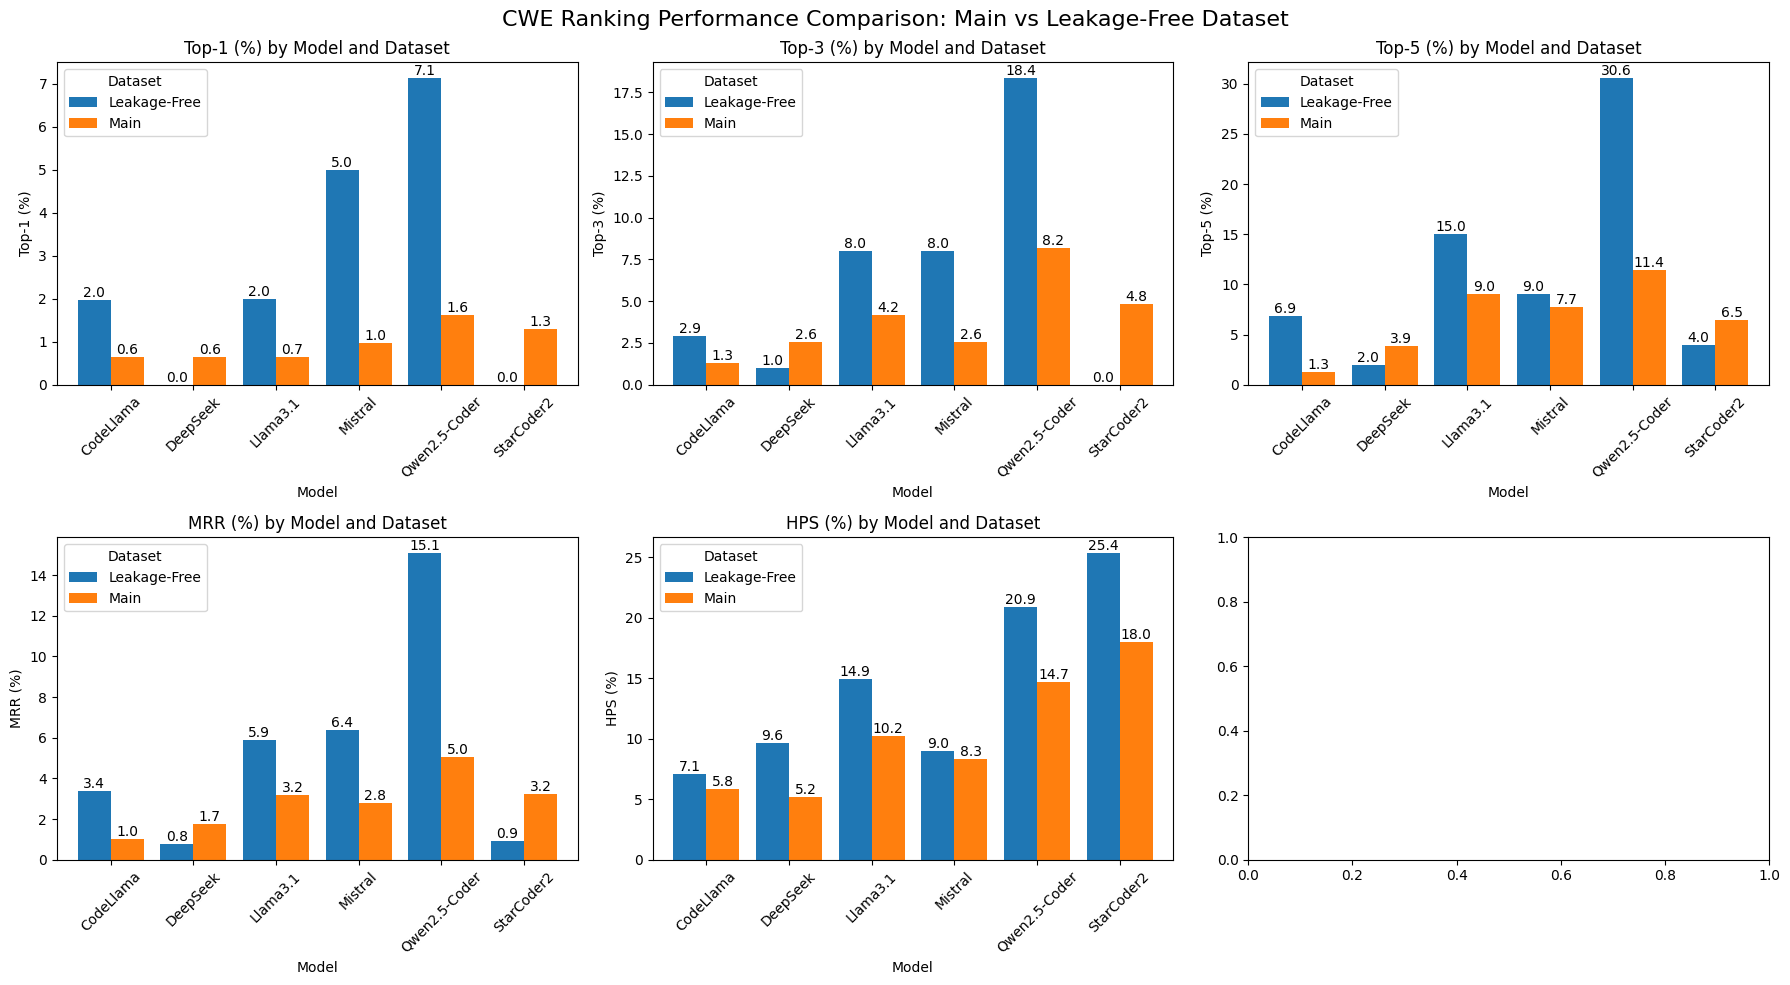


Analysis complete!


In [14]:
import sqlite3
import pandas as pd
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt

def load_cwe_hierarchy():
    """Load CWE hierarchy from JSON file."""
    try:
        with open('/home/azibaeir/Research/VulnLLMEval-SANER/cwe_hierarchy.json', 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print("Warning: CWE hierarchy file not found. HPS scores will not be calculated.")
        return None

def build_cwe_relationships():
    """Build CWE relationship mappings from hierarchy."""
    hierarchy = load_cwe_hierarchy()
    if not hierarchy:
        return {}, {}, {}
    
    # Maps to store relationships
    parent_map = {}  # cwe_id -> parent_id
    children_map = {}  # cwe_id -> [child_ids]
    root_map = {}  # cwe_id -> root_pillar_id
    
    def traverse(node, parent_id=None, root_id=None):
        if 'id' in node:
            cwe_id = node['id']
            
            # Set parent relationship
            if parent_id:
                parent_map[cwe_id] = parent_id
                if parent_id not in children_map:
                    children_map[parent_id] = []
                children_map[parent_id].append(cwe_id)
            
            # Set root pillar (top-level categories)
            if parent_id is None:  # This is a root pillar
                root_id = cwe_id
            root_map[cwe_id] = root_id
            
            # Recurse through children
            for child in node.get('children', []):
                traverse(child, cwe_id, root_id)
    
    # Process the hierarchy
    for pillar in hierarchy.get('children', []):
        traverse(pillar)
    
    return parent_map, children_map, root_map

def get_cwe_relationship_score(pred_cwe, true_cwe, parent_map, children_map, root_map):
    """Calculate HPS score between predicted and true CWE based on their relationship."""
    if pred_cwe == true_cwe:
        return 1.0  # Exact match
    
    # Check parent relationship (pred is parent of true)
    # Using children_map: if pred_cwe has true_cwe as one of its children
    if pred_cwe in children_map and true_cwe in children_map[pred_cwe]:
        return 0.8
    
    # Check child relationship (pred is child of true) 
    # Using children_map: if true_cwe has pred_cwe as one of its children
    if true_cwe in children_map and pred_cwe in children_map[true_cwe]:
        return 0.7
    
    # Check sibling relationship (same direct parent)
    if (pred_cwe in parent_map and true_cwe in parent_map and 
        parent_map[pred_cwe] == parent_map[true_cwe]):
        return 0.6
    
    # Check same root category (same pillar)
    if (pred_cwe in root_map and true_cwe in root_map and 
        root_map[pred_cwe] == root_map[true_cwe]):
        return 0.4
    
    return 0.0  # No relationship

def calculate_hps(predictions, truths):
    """Calculate Hierarchical Proximity Score (HPS) for CWE predictions."""
    parent_map, children_map, root_map = build_cwe_relationships()
    
    if not parent_map:  # No hierarchy available
        return 0
    
    total_score = 0
    total_predictions = 0
    
    for pred, truth in zip(predictions, truths):
        # Parse predicted CWEs
        if isinstance(pred, str):
            try:
                pred_list = json.loads(pred)
            except json.JSONDecodeError:
                pred_list = []
        else:
            pred_list = []
            
        # Parse ground truth CWEs
        truth_list = parse_vulnerability_cwe(truth)
        
        if truth_list and pred_list:  # Only count if both have valid CWEs
            # For each predicted CWE, find the best score against any true CWE
            for pred_cwe in pred_list:
                best_score = 0
                for true_cwe in truth_list:
                    score = get_cwe_relationship_score(pred_cwe, true_cwe, parent_map, children_map, root_map)
                    best_score = max(best_score, score)
                total_score += best_score
                total_predictions += 1
    
    return (total_score / total_predictions * 100) if total_predictions > 0 else 0

def fetch_ranking_data(db_file):
    """Fetch CWE ranking data from the database."""
    conn = sqlite3.connect(db_file)
    query = """
        SELECT 
            LLM_Ranked_CWE,
            VULNERABILITY_CWE
        FROM vulnerabilities
        WHERE LLM_Ranked_CWE IS NOT NULL AND VULNERABILITY_CWE IS NOT NULL
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

def parse_vulnerability_cwe(cwe_field):
    """Parse the VULNERABILITY_CWE field which can contain multiple CWEs in JSON format."""
    if isinstance(cwe_field, str):
        try:
            # Parse JSON array like ["CWE-1", "CWE-2"]
            cwe_list = json.loads(cwe_field)
            if isinstance(cwe_list, list):
                return cwe_list
            else:
                return [str(cwe_list)]  # Single CWE as string
        except json.JSONDecodeError:
            # Fallback for non-JSON format
            return [cwe_field.strip()]
    return []

def calculate_top_k_accuracy(predictions, truths, k=5):
    """Calculate top-k accuracy for CWE predictions."""
    correct = 0
    total = 0
    
    for pred, truth in zip(predictions, truths):
        # Parse predicted CWEs
        if isinstance(pred, str):
            try:
                pred_list = json.loads(pred)
            except json.JSONDecodeError:
                print(f"Error decoding JSON: {pred}")
                pred_list = []
        else:
            pred_list = []
            
        # Parse ground truth CWEs
        truth_list = parse_vulnerability_cwe(truth)
        
        if truth_list:  # Only count if there are ground truth CWEs
            total += 1
            # Check if any ground truth CWE is in top-k predictions
            top_k_preds = pred_list[:k] if len(pred_list) >= k else pred_list
            if any(t in top_k_preds for t in truth_list):
                correct += 1
    
    return (correct / total * 100) if total > 0 else 0

def calculate_mrr(predictions, truths):
    """Calculate Mean Reciprocal Rank (MRR) for CWE predictions."""
    mrr = 0
    total = 0
    
    for pred, truth in zip(predictions, truths):
        # Parse predicted CWEs
        if isinstance(pred, str):
            try:
                pred_list = json.loads(pred)
            except json.JSONDecodeError:
                print(f"Error decoding JSON: {pred}")
                pred_list = []
        else:
            pred_list = []
            
        # Parse ground truth CWEs
        truth_list = parse_vulnerability_cwe(truth)
        
        if truth_list:  # Only count if there are ground truth CWEs
            total += 1
            # Find the highest rank (lowest index) of any correct prediction
            best_rank = float('inf')
            for rank, p in enumerate(pred_list, start=1):
                if p in truth_list:
                    best_rank = min(best_rank, rank)
                    break
            
            if best_rank != float('inf'):
                mrr += 1 / best_rank
    
    return (mrr / total * 100) if total > 0 else 0

def process_database(db_file, llm_name):
    """Process a single database and calculate CWE ranking metrics."""
    df = fetch_ranking_data(db_file)

    if df.empty:
        print(f"No data available to calculate metrics in {db_file}.")
        return None

    # Calculate metrics for CWE only
    top_1_accuracy = calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=1)
    top_2_accuracy = calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=2)
    top_3_accuracy = calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=3)
    top_4_accuracy = calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=4)
    top_5_accuracy = calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=5)
    mrr_cwe = calculate_mrr(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'])
    hps_score = calculate_hps(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'])

    # Create DataFrame with CWE metrics
    metrics_df = pd.DataFrame({
        'Model': [llm_name],
        'Top-1 (%)': [round(top_1_accuracy, 2)],
        'Top-2 (%)': [round(top_2_accuracy, 2)],
        'Top-3 (%)': [round(top_3_accuracy, 2)],
        'Top-4 (%)': [round(top_4_accuracy, 2)],
        'Top-5 (%)': [round(top_5_accuracy, 2)],
        'MRR (%)': [round(mrr_cwe, 2)],
        'HPS (%)': [round(hps_score, 2)]
    })

    return metrics_df

# Define main dataset model files
main_model_files = {
    'CodeLlama': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_codellama_database.sqlite',
    'DeepSeek': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_deepseek_database.sqlite',
    'Llama3.1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_llama_database.sqlite',
    'Mistral': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_mistral_database.sqlite',
    'Qwen2.5-Coder': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_qwen3_coder_database.sqlite',
    'StarCoder2': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_starcoder_database.sqlite'
}

# Define leakage-free dataset model files
leakagefree_model_files = {
    'CodeLlama': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_codellama_database_leakagefree.sqlite',
    'DeepSeek': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_deepseek_database_leakagefree.sqlite', 
    'Llama3.1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_llama_database_leakagefree.sqlite',
    'Mistral': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_mistral_database_leakagefree.sqlite',
    'Qwen2.5-Coder': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_qwen3_coder_database_leakagefree.sqlite',
    'StarCoder2': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_starcoder_database_leakagefree.sqlite'
}

def process_dataset(model_files, dataset_name):
    """Process all models for a given dataset."""
    print(f"\n=== Processing {dataset_name} Dataset ===")
    all_metrics_df = pd.DataFrame()
    
    # Iterate over the model files
    for llm_name, db_file in model_files.items():
        if os.path.exists(db_file):
            print(f"Processing {llm_name}...")
            metrics_df = process_database(db_file, llm_name)
            if metrics_df is not None:
                all_metrics_df = pd.concat([all_metrics_df, metrics_df])
        else:
            print(f"Database file {db_file} does not exist.")
    
    if not all_metrics_df.empty:
        all_metrics_df.reset_index(inplace=True, drop=True)
        
        # Sort the DataFrame by model name
        all_metrics_df = all_metrics_df.sort_values('Model')
        
        print(f"\n{dataset_name} CWE Ranking Metrics:")
        print(all_metrics_df.to_string(index=False))
        
        # Generate LaTeX table
        latex_table = all_metrics_df.to_latex(index=False, escape=False)
        print(f"\nLaTeX format for {dataset_name} CWE Ranking Metrics:")
        print(latex_table)
        
        return all_metrics_df
    else:
        print(f"No metrics were calculated for {dataset_name} dataset.")
        return pd.DataFrame()

# Process both datasets
main_results = process_dataset(main_model_files, "Main")
leakagefree_results = process_dataset(leakagefree_model_files, "Leakage-Free")

# Create comparison visualization if both datasets have results
if not main_results.empty and not leakagefree_results.empty:
    print("\n=== Creating Comparison Visualization ===")
    
    # Combine datasets for comparison
    main_results['Dataset'] = 'Main'
    leakagefree_results['Dataset'] = 'Leakage-Free'
    combined_df = pd.concat([main_results, leakagefree_results])
    
    # Create comparison plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('CWE Ranking Performance Comparison: Main vs Leakage-Free Dataset', fontsize=16)
    
    metrics_to_plot = ['Top-1 (%)', 'Top-3 (%)', 'Top-5 (%)', 'MRR (%)', 'HPS (%)']
    
    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i // 3, i % 3]
        
        # Create pivot table for easier plotting
        pivot_df = combined_df.pivot(index='Model', columns='Dataset', values=metric)
        
        # Create grouped bar plot
        pivot_df.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title(f'{metric} by Model and Dataset')
        ax.set_xlabel('Model')
        ax.set_ylabel(metric)
        ax.legend(title='Dataset')
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f')
    
    plt.tight_layout()
    plt.show()

print("\nAnalysis complete!")


=== Processing Main Dataset ===
Processing CodeLlama...
Processing DeepSeek...
Processing Llama3.1...
Processing Mistral...
Processing Qwen3-Coder...
Processing StarCoder2...

Main CWE Ranking Metrics:
      Model  Top-1 (%)  Top-2 (%)  Top-3 (%)  Top-4 (%)  Top-5 (%)  MRR (%)  HPS (%)
  CodeLlama       0.64       1.27       1.27       1.27       1.27     1.03     5.83
   DeepSeek       0.64       1.61       2.57       3.22       3.86     1.74     5.16
   Llama3.1       0.65       1.94       4.19       8.06       9.03     3.20    10.18
    Mistral       0.97       1.94       2.58       4.52       7.74     2.80     8.28
Qwen3-Coder       1.63       4.90       8.17       8.82      11.44     5.04    14.66
 StarCoder2       1.29       3.55       4.84       6.45       6.45     3.25    17.99

LaTeX format for Main CWE Ranking Metrics:
\begin{tabular}{lrrrrrrr}
\toprule
Model & Top-1 (%) & Top-2 (%) & Top-3 (%) & Top-4 (%) & Top-5 (%) & MRR (%) & HPS (%) \\
\midrule
CodeLlama & 0.640000 & 1.

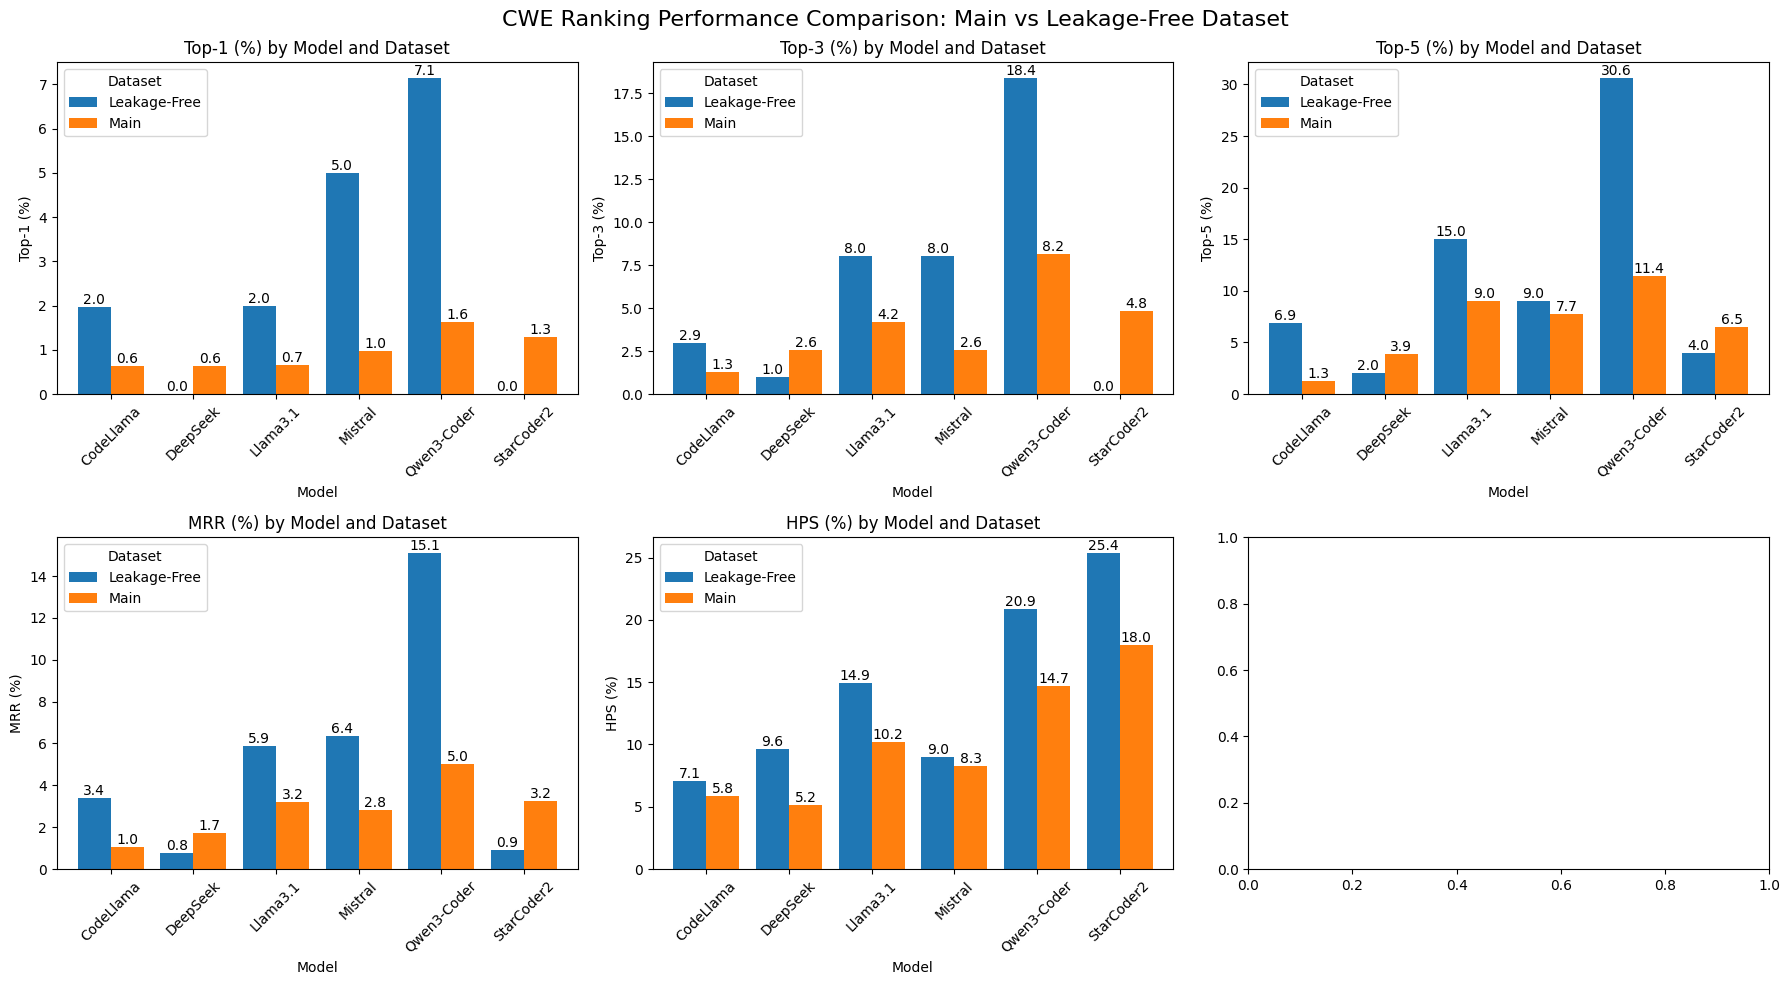


Basic Analysis complete!

RUNNING COMPREHENSIVE CWE RANKING ANALYSIS
Starting Comprehensive CWE Ranking Analysis...

=== Processing Main Dataset ===
Processing CodeLlama...
Processing DeepSeek...
Processing Llama3.1...
Processing Mistral...
Processing Qwen3-Coder...
Processing StarCoder2...

=== Processing Leakage-Free Dataset ===
Processing CodeLlama...
Processing DeepSeek...
Processing Llama3.1...
Processing Mistral...
Processing Qwen3-Coder...
Processing StarCoder2...

COMPREHENSIVE CWE RANKING ANALYSIS REPORT

1. OVERALL CAPABILITY ANALYSIS
--------------------------------------------------

PBD Dataset:
  CodeLlama      : Micro=2.2% | Macro=2.1% | Top-1=0.6%
  DeepSeek       : Micro=3.9% | Macro=3.2% | Top-1=0.6%
  Llama3.1       : Micro=9.0% | Macro=7.5% | Top-1=0.6%
  Mistral        : Micro=7.7% | Macro=6.1% | Top-1=1.0%
  Qwen3-Coder    : Micro=11.4% | Macro=8.7% | Top-1=1.6%
  StarCoder2     : Micro=6.5% | Macro=5.1% | Top-1=1.3%

LFD Dataset:
  CodeLlama      : Micro=7.8% | 

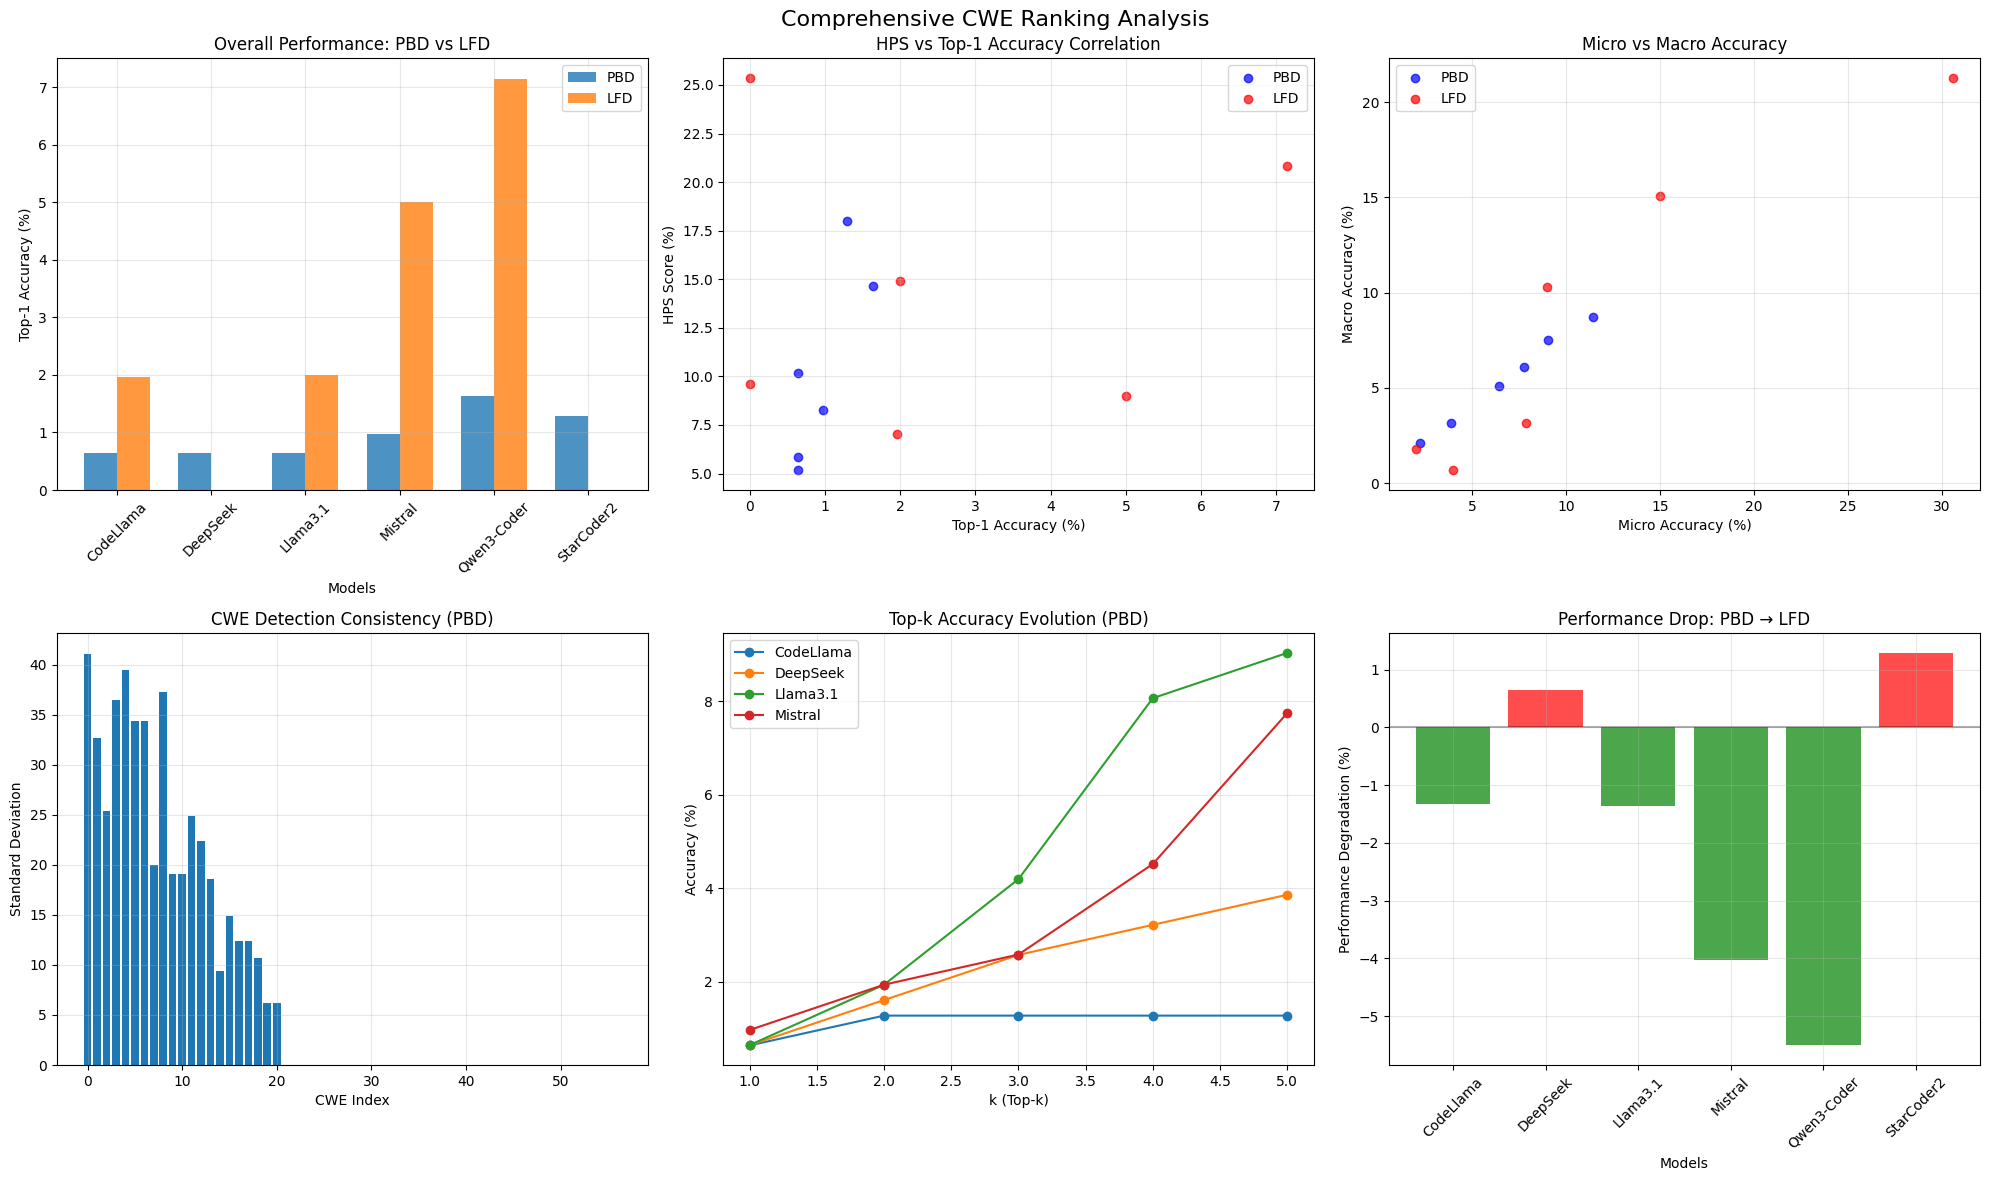

In [17]:
import sqlite3
import pandas as pd
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict
try:
    from scipy.stats import pearsonr, spearmanr
except ImportError:
    print("Warning: scipy not available. Correlation analysis will be limited.")
    pearsonr = spearmanr = None
import warnings
warnings.filterwarnings('ignore')

def load_cwe_hierarchy():
    """Load CWE hierarchy from JSON file."""
    try:
        with open('/home/azibaeir/Research/VulnLLMEval-SANER/cwe_hierarchy.json', 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print("Warning: CWE hierarchy file not found. HPS scores will not be calculated.")
        return None

def build_cwe_relationships():
    """Build CWE relationship mappings from hierarchy."""
    hierarchy = load_cwe_hierarchy()
    if not hierarchy:
        return {}, {}, {}
    
    # Maps to store relationships
    parent_map = {}  # cwe_id -> parent_id
    children_map = {}  # cwe_id -> [child_ids]
    root_map = {}  # cwe_id -> root_pillar_id
    
    def traverse(node, parent_id=None, root_id=None):
        if 'id' in node:
            cwe_id = node['id']
            
            # Set parent relationship
            if parent_id:
                parent_map[cwe_id] = parent_id
                if parent_id not in children_map:
                    children_map[parent_id] = []
                children_map[parent_id].append(cwe_id)
            
            # Set root pillar (top-level categories)
            if parent_id is None:  # This is a root pillar
                root_id = cwe_id
            root_map[cwe_id] = root_id
            
            # Recurse through children
            for child in node.get('children', []):
                traverse(child, cwe_id, root_id)
    
    # Process the hierarchy
    for pillar in hierarchy.get('children', []):
        traverse(pillar)
    
    return parent_map, children_map, root_map

def get_cwe_relationship_score(pred_cwe, true_cwe, parent_map, children_map, root_map):
    """Calculate HPS score between predicted and true CWE based on their relationship."""
    if pred_cwe == true_cwe:
        return 1.0  # Exact match
    
    # Check parent relationship (pred is parent of true)
    # Using children_map: if pred_cwe has true_cwe as one of its children
    if pred_cwe in children_map and true_cwe in children_map[pred_cwe]:
        return 0.8
    
    # Check child relationship (pred is child of true) 
    # Using children_map: if true_cwe has pred_cwe as one of its children
    if true_cwe in children_map and pred_cwe in children_map[true_cwe]:
        return 0.7
    
    # Check sibling relationship (same direct parent)
    if (pred_cwe in parent_map and true_cwe in parent_map and 
        parent_map[pred_cwe] == parent_map[true_cwe]):
        return 0.6
    
    # Check same root category (same pillar)
    if (pred_cwe in root_map and true_cwe in root_map and 
        root_map[pred_cwe] == root_map[true_cwe]):
        return 0.4
    
    return 0.0  # No relationship

def calculate_hps(predictions, truths):
    """Calculate Hierarchical Proximity Score (HPS) for CWE predictions."""
    parent_map, children_map, root_map = build_cwe_relationships()
    
    if not parent_map:  # No hierarchy available
        return 0
    
    total_score = 0
    total_predictions = 0
    
    for pred, truth in zip(predictions, truths):
        # Parse predicted CWEs
        if isinstance(pred, str):
            try:
                pred_list = json.loads(pred)
            except json.JSONDecodeError:
                pred_list = []
        else:
            pred_list = []
            
        # Parse ground truth CWEs
        truth_list = parse_vulnerability_cwe(truth)
        
        if truth_list and pred_list:  # Only count if both have valid CWEs
            # For each predicted CWE, find the best score against any true CWE
            for pred_cwe in pred_list:
                best_score = 0
                for true_cwe in truth_list:
                    score = get_cwe_relationship_score(pred_cwe, true_cwe, parent_map, children_map, root_map)
                    best_score = max(best_score, score)
                total_score += best_score
                total_predictions += 1
    
    return (total_score / total_predictions * 100) if total_predictions > 0 else 0

def fetch_ranking_data(db_file):
    """Fetch CWE ranking data from the database."""
    conn = sqlite3.connect(db_file)
    query = """
        SELECT 
            LLM_Ranked_CWE,
            VULNERABILITY_CWE
        FROM vulnerabilities
        WHERE LLM_Ranked_CWE IS NOT NULL AND VULNERABILITY_CWE IS NOT NULL
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

def parse_vulnerability_cwe(cwe_field):
    """Parse the VULNERABILITY_CWE field which can contain multiple CWEs in JSON format."""
    if isinstance(cwe_field, str):
        try:
            # Parse JSON array like ["CWE-1", "CWE-2"]
            cwe_list = json.loads(cwe_field)
            if isinstance(cwe_list, list):
                return cwe_list
            else:
                return [str(cwe_list)]  # Single CWE as string
        except json.JSONDecodeError:
            # Fallback for non-JSON format
            return [cwe_field.strip()]
    return []

def calculate_top_k_accuracy(predictions, truths, k=5):
    """Calculate top-k accuracy for CWE predictions."""
    correct = 0
    total = 0
    
    for pred, truth in zip(predictions, truths):
        # Parse predicted CWEs
        if isinstance(pred, str):
            try:
                pred_list = json.loads(pred)
            except json.JSONDecodeError:
                print(f"Error decoding JSON: {pred}")
                pred_list = []
        else:
            pred_list = []
            
        # Parse ground truth CWEs
        truth_list = parse_vulnerability_cwe(truth)
        
        if truth_list:  # Only count if there are ground truth CWEs
            total += 1
            # Check if any ground truth CWE is in top-k predictions
            top_k_preds = pred_list[:k] if len(pred_list) >= k else pred_list
            if any(t in top_k_preds for t in truth_list):
                correct += 1
    
    return (correct / total * 100) if total > 0 else 0

def calculate_mrr(predictions, truths):
    """Calculate Mean Reciprocal Rank (MRR) for CWE predictions."""
    mrr = 0
    total = 0
    
    for pred, truth in zip(predictions, truths):
        # Parse predicted CWEs
        if isinstance(pred, str):
            try:
                pred_list = json.loads(pred)
            except json.JSONDecodeError:
                print(f"Error decoding JSON: {pred}")
                pred_list = []
        else:
            pred_list = []
            
        # Parse ground truth CWEs
        truth_list = parse_vulnerability_cwe(truth)
        
        if truth_list:  # Only count if there are ground truth CWEs
            total += 1
            # Find the highest rank (lowest index) of any correct prediction
            best_rank = float('inf')
            for rank, p in enumerate(pred_list, start=1):
                if p in truth_list:
                    best_rank = min(best_rank, rank)
                    break
            
            if best_rank != float('inf'):
                mrr += 1 / best_rank
    
    return (mrr / total * 100) if total > 0 else 0

def process_database(db_file, llm_name):
    """Process a single database and calculate CWE ranking metrics."""
    df = fetch_ranking_data(db_file)

    if df.empty:
        print(f"No data available to calculate metrics in {db_file}.")
        return None

    # Calculate metrics for CWE only
    top_1_accuracy = calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=1)
    top_2_accuracy = calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=2)
    top_3_accuracy = calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=3)
    top_4_accuracy = calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=4)
    top_5_accuracy = calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=5)
    mrr_cwe = calculate_mrr(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'])
    hps_score = calculate_hps(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'])

    # Create DataFrame with CWE metrics
    metrics_df = pd.DataFrame({
        'Model': [llm_name],
        'Top-1 (%)': [round(top_1_accuracy, 2)],
        'Top-2 (%)': [round(top_2_accuracy, 2)],
        'Top-3 (%)': [round(top_3_accuracy, 2)],
        'Top-4 (%)': [round(top_4_accuracy, 2)],
        'Top-5 (%)': [round(top_5_accuracy, 2)],
        'MRR (%)': [round(mrr_cwe, 2)],
        'HPS (%)': [round(hps_score, 2)]
    })

    return metrics_df

# Define main dataset model files
main_model_files = {
    'CodeLlama': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_codellama_database.sqlite',
    'DeepSeek': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_deepseek_database.sqlite',
    'Llama3.1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_llama_database.sqlite',
    'Mistral': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_mistral_database.sqlite',
    'Qwen3-Coder': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_qwen3_coder_database.sqlite',
    'StarCoder2': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_starcoder_database.sqlite'
}

# Define leakage-free dataset model files
leakagefree_model_files = {
    'CodeLlama': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_codellama_database_leakagefree.sqlite',
    'DeepSeek': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_deepseek_database_leakagefree.sqlite', 
    'Llama3.1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_llama_database_leakagefree.sqlite',
    'Mistral': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_mistral_database_leakagefree.sqlite',
    'Qwen3-Coder': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_qwen3_coder_database_leakagefree.sqlite',
    'StarCoder2': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_starcoder_database_leakagefree.sqlite'
}

def process_dataset(model_files, dataset_name):
    """Process all models for a given dataset."""
    print(f"\n=== Processing {dataset_name} Dataset ===")
    all_metrics_df = pd.DataFrame()
    
    # Iterate over the model files
    for llm_name, db_file in model_files.items():
        if os.path.exists(db_file):
            print(f"Processing {llm_name}...")
            metrics_df = process_database(db_file, llm_name)
            if metrics_df is not None:
                all_metrics_df = pd.concat([all_metrics_df, metrics_df])
        else:
            print(f"Database file {db_file} does not exist.")
    
    if not all_metrics_df.empty:
        all_metrics_df.reset_index(inplace=True, drop=True)
        
        # Sort the DataFrame by model name
        all_metrics_df = all_metrics_df.sort_values('Model')
        
        print(f"\n{dataset_name} CWE Ranking Metrics:")
        print(all_metrics_df.to_string(index=False))
        
        # Generate LaTeX table
        latex_table = all_metrics_df.to_latex(index=False, escape=False)
        print(f"\nLaTeX format for {dataset_name} CWE Ranking Metrics:")
        print(latex_table)
        
        return all_metrics_df
    else:
        print(f"No metrics were calculated for {dataset_name} dataset.")
        return pd.DataFrame()

# Process both datasets
main_results = process_dataset(main_model_files, "Main")
leakagefree_results = process_dataset(leakagefree_model_files, "Leakage-Free")

# Create comparison visualization if both datasets have results
if not main_results.empty and not leakagefree_results.empty:
    print("\n=== Creating Comparison Visualization ===")
    
    # Combine datasets for comparison
    main_results['Dataset'] = 'Main'
    leakagefree_results['Dataset'] = 'Leakage-Free'
    combined_df = pd.concat([main_results, leakagefree_results])
    
    # Create comparison plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('CWE Ranking Performance Comparison: Main vs Leakage-Free Dataset', fontsize=16)
    
    metrics_to_plot = ['Top-1 (%)', 'Top-3 (%)', 'Top-5 (%)', 'MRR (%)', 'HPS (%)']
    
    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i // 3, i % 3]
        
        # Create pivot table for easier plotting
        pivot_df = combined_df.pivot(index='Model', columns='Dataset', values=metric)
        
        # Create grouped bar plot
        pivot_df.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title(f'{metric} by Model and Dataset')
        ax.set_xlabel('Model')
        ax.set_ylabel(metric)
        ax.legend(title='Dataset')
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f')
    
    plt.tight_layout()
    plt.show()

print("\nBasic Analysis complete!")

# ============== COMPREHENSIVE CWE RANKING ANALYSIS ==============

def calculate_micro_macro_accuracy(predictions, truths):
    """Calculate micro and macro accuracy for CWE predictions."""
    # Micro accuracy: total correct predictions / total predictions
    total_correct = 0
    total_predictions = 0
    
    # Macro accuracy: average per-CWE accuracy
    cwe_correct = defaultdict(int)
    cwe_total = defaultdict(int)
    
    for pred, truth in zip(predictions, truths):
        # Parse predicted CWEs
        if isinstance(pred, str):
            try:
                pred_list = json.loads(pred)
            except json.JSONDecodeError:
                pred_list = []
        else:
            pred_list = []
            
        # Parse ground truth CWEs
        truth_list = parse_vulnerability_cwe(truth)
        
        if truth_list:
            total_predictions += 1
            # Check if any ground truth CWE is in predictions
            if any(t in pred_list for t in truth_list):
                total_correct += 1
            
            # Per-CWE tracking for macro accuracy
            for true_cwe in truth_list:
                cwe_total[true_cwe] += 1
                if true_cwe in pred_list:
                    cwe_correct[true_cwe] += 1
    
    # Calculate micro accuracy
    micro_accuracy = (total_correct / total_predictions * 100) if total_predictions > 0 else 0
    
    # Calculate macro accuracy
    cwe_accuracies = []
    for cwe in cwe_total:
        if cwe_total[cwe] > 0:
            cwe_accuracy = cwe_correct[cwe] / cwe_total[cwe] * 100
            cwe_accuracies.append(cwe_accuracy)
    
    macro_accuracy = np.mean(cwe_accuracies) if cwe_accuracies else 0
    
    return micro_accuracy, macro_accuracy

def analyze_cwe_distribution_bias(predictions, truths):
    """Analyze which CWE types are most/least accurately detected."""
    cwe_performance = defaultdict(lambda: {'correct': 0, 'total': 0, 'accuracy': 0})
    
    for pred, truth in zip(predictions, truths):
        # Parse predicted CWEs
        if isinstance(pred, str):
            try:
                pred_list = json.loads(pred)
            except json.JSONDecodeError:
                pred_list = []
        else:
            pred_list = []
            
        # Parse ground truth CWEs
        truth_list = parse_vulnerability_cwe(truth)
        
        for true_cwe in truth_list:
            cwe_performance[true_cwe]['total'] += 1
            if true_cwe in pred_list:
                cwe_performance[true_cwe]['correct'] += 1
    
    # Calculate accuracy for each CWE
    for cwe in cwe_performance:
        if cwe_performance[cwe]['total'] > 0:
            cwe_performance[cwe]['accuracy'] = (
                cwe_performance[cwe]['correct'] / cwe_performance[cwe]['total'] * 100
            )
    
    # Convert to DataFrame for easier analysis
    cwe_df = pd.DataFrame([
        {
            'CWE': cwe,
            'Total': data['total'],
            'Correct': data['correct'],
            'Accuracy': data['accuracy']
        }
        for cwe, data in cwe_performance.items()
        if data['total'] >= 3  # Only include CWEs with at least 3 instances
    ])
    
    if not cwe_df.empty:
        cwe_df = cwe_df.sort_values('Accuracy', ascending=False)
    
    return cwe_df

def analyze_model_consistency(all_results_dict):
    """Analyze consistency of CWE detection patterns across different LLMs."""
    if not all_results_dict:
        return None
    
    # Get all CWEs that appear in results
    all_cwes = set()
    for model_results in all_results_dict.values():
        if 'cwe_performance' in model_results:
            all_cwes.update(model_results['cwe_performance']['CWE'].tolist())
    
    # Create consistency matrix
    consistency_data = []
    for cwe in all_cwes:
        cwe_accuracies = []
        for model, results in all_results_dict.items():
            if 'cwe_performance' in results:
                cwe_row = results['cwe_performance'][
                    results['cwe_performance']['CWE'] == cwe
                ]
                if not cwe_row.empty:
                    cwe_accuracies.append(cwe_row['Accuracy'].iloc[0])
                else:
                    cwe_accuracies.append(0)
        
        if len(cwe_accuracies) > 1:
            consistency_data.append({
                'CWE': cwe,
                'Mean_Accuracy': np.mean(cwe_accuracies),
                'Std_Accuracy': np.std(cwe_accuracies),
                'Model_Count': len([acc for acc in cwe_accuracies if acc > 0])
            })
    
    consistency_df = pd.DataFrame(consistency_data)
    if not consistency_df.empty:
        consistency_df = consistency_df.sort_values('Mean_Accuracy', ascending=False)
    
    return consistency_df

def analyze_misclassification_patterns(predictions, truths):
    """Analyze common misclassification patterns in CWE predictions."""
    confusion_matrix = defaultdict(lambda: defaultdict(int))
    
    for pred, truth in zip(predictions, truths):
        # Parse predicted CWEs
        if isinstance(pred, str):
            try:
                pred_list = json.loads(pred)
            except json.JSONDecodeError:
                pred_list = []
        else:
            pred_list = []
            
        # Parse ground truth CWEs
        truth_list = parse_vulnerability_cwe(truth)
        
        for true_cwe in truth_list:
            if pred_list:
                # Record the top prediction for this true CWE
                top_pred = pred_list[0] if pred_list else 'NO_PREDICTION'
                confusion_matrix[true_cwe][top_pred] += 1
            else:
                confusion_matrix[true_cwe]['NO_PREDICTION'] += 1
    
    # Convert to more readable format
    misclassification_data = []
    for true_cwe, predictions_dict in confusion_matrix.items():
        total_instances = sum(predictions_dict.values())
        for pred_cwe, count in predictions_dict.items():
            if count > 0:
                misclassification_data.append({
                    'True_CWE': true_cwe,
                    'Predicted_CWE': pred_cwe,
                    'Count': count,
                    'Percentage': (count / total_instances * 100)
                })
    
    misclassification_df = pd.DataFrame(misclassification_data)
    if not misclassification_df.empty:
        misclassification_df = misclassification_df.sort_values(['True_CWE', 'Count'], ascending=[True, False])
    
    return misclassification_df

def enhanced_process_database(db_file, llm_name):
    """Enhanced processing with detailed CWE analysis."""
    df = fetch_ranking_data(db_file)

    if df.empty:
        print(f"No data available to calculate metrics in {db_file}.")
        return None

    # Calculate all existing metrics
    results = {
        'model': llm_name,
        'top_1_accuracy': calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=1),
        'top_2_accuracy': calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=2),
        'top_3_accuracy': calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=3),
        'top_4_accuracy': calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=4),
        'top_5_accuracy': calculate_top_k_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'], k=5),
        'mrr': calculate_mrr(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE']),
        'hps': calculate_hps(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'])
    }
    
    # Enhanced analysis
    micro_acc, macro_acc = calculate_micro_macro_accuracy(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'])
    results['micro_accuracy'] = micro_acc
    results['macro_accuracy'] = macro_acc
    
    # CWE distribution analysis
    results['cwe_performance'] = analyze_cwe_distribution_bias(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'])
    
    # Misclassification patterns
    results['misclassification'] = analyze_misclassification_patterns(df['LLM_Ranked_CWE'], df['VULNERABILITY_CWE'])

    return results

def generate_comprehensive_report(main_results_dict, lfd_results_dict):
    """Generate comprehensive CWE ranking analysis report."""
    print("\n" + "="*80)
    print("COMPREHENSIVE CWE RANKING ANALYSIS REPORT")
    print("="*80)
    
    # Q1: Overall Capability
    print("\n1. OVERALL CAPABILITY ANALYSIS")
    print("-" * 50)
    
    overall_stats = []
    for dataset_name, results_dict in [("PBD", main_results_dict), ("LFD", lfd_results_dict)]:
        print(f"\n{dataset_name} Dataset:")
        for model, results in results_dict.items():
            overall_stats.append({
                'Dataset': dataset_name,
                'Model': model,
                'Micro_Accuracy': results['micro_accuracy'],
                'Macro_Accuracy': results['macro_accuracy'],
                'Top-1': results['top_1_accuracy'],
                'Top-5': results['top_5_accuracy'],
                'MRR': results['mrr'],
                'HPS': results['hps']
            })
            print(f"  {model:15s}: Micro={results['micro_accuracy']:.1f}% | Macro={results['macro_accuracy']:.1f}% | Top-1={results['top_1_accuracy']:.1f}%")
    
    # Q2: CWE Distribution Bias
    print("\n\n2. CWE DISTRIBUTION BIAS ANALYSIS")
    print("-" * 50)
    
    for dataset_name, results_dict in [("PBD", main_results_dict), ("LFD", lfd_results_dict)]:
        print(f"\n{dataset_name} Dataset - Top Performing CWEs:")
        
        # Aggregate CWE performance across models
        cwe_aggregate = defaultdict(lambda: {'total_acc': 0, 'model_count': 0})
        
        for model, results in results_dict.items():
            if not results['cwe_performance'].empty:
                for _, row in results['cwe_performance'].iterrows():
                    cwe_aggregate[row['CWE']]['total_acc'] += row['Accuracy']
                    cwe_aggregate[row['CWE']]['model_count'] += 1
        
        # Calculate average accuracy per CWE
        cwe_avg_performance = []
        for cwe, data in cwe_aggregate.items():
            if data['model_count'] > 0:
                avg_acc = data['total_acc'] / data['model_count']
                cwe_avg_performance.append((cwe, avg_acc, data['model_count']))
        
        cwe_avg_performance.sort(key=lambda x: x[1], reverse=True)
        
        print("  Best performing CWEs:")
        for cwe, avg_acc, model_count in cwe_avg_performance[:5]:
            print(f"    {cwe}: {avg_acc:.1f}% (across {model_count} models)")
        
        print("  Worst performing CWEs:")
        for cwe, avg_acc, model_count in cwe_avg_performance[-5:]:
            print(f"    {cwe}: {avg_acc:.1f}% (across {model_count} models)")
    
    # Q3: Model Variation
    print("\n\n3. MODEL CONSISTENCY ANALYSIS")
    print("-" * 50)
    
    consistency_pbd = analyze_model_consistency(main_results_dict)
    consistency_lfd = analyze_model_consistency(lfd_results_dict)
    
    for dataset_name, consistency_df in [("PBD", consistency_pbd), ("LFD", consistency_lfd)]:
        if consistency_df is not None and not consistency_df.empty:
            print(f"\n{dataset_name} Dataset - CWE Detection Consistency:")
            print("  Most consistent CWEs (low variance across models):")
            stable_cwes = consistency_df.nsmallest(5, 'Std_Accuracy')
            for _, row in stable_cwes.iterrows():
                print(f"    {row['CWE']}: Mean={row['Mean_Accuracy']:.1f}% (σ={row['Std_Accuracy']:.1f})")
            
            print("  Most variable CWEs (high variance across models):")
            variable_cwes = consistency_df.nlargest(5, 'Std_Accuracy')
            for _, row in variable_cwes.iterrows():
                print(f"    {row['CWE']}: Mean={row['Mean_Accuracy']:.1f}% (σ={row['Std_Accuracy']:.1f})")
    
    # Q4: CWE Hierarchy Depth (HPS Analysis)
    print("\n\n4. CWE HIERARCHY DEPTH ANALYSIS (HPS)")
    print("-" * 50)
    
    print("Hierarchical Proximity Scores by Model:")
    for dataset_name, results_dict in [("PBD", main_results_dict), ("LFD", lfd_results_dict)]:
        print(f"\n{dataset_name}:")
        hps_scores = [(model, results['hps']) for model, results in results_dict.items()]
        hps_scores.sort(key=lambda x: x[1], reverse=True)
        
        for model, hps in hps_scores:
            print(f"  {model:15s}: {hps:.1f}%")
    
    # Q6: Generalization Across Datasets
    print("\n\n6. GENERALIZATION ANALYSIS (PBD vs LFD)")
    print("-" * 50)
    
    if main_results_dict and lfd_results_dict:
        print("Performance degradation from PBD to LFD:")
        for model in main_results_dict.keys():
            if model in lfd_results_dict:
                pbd_top1 = main_results_dict[model]['top_1_accuracy']
                lfd_top1 = lfd_results_dict[model]['top_1_accuracy']
                degradation = pbd_top1 - lfd_top1
                print(f"  {model:15s}: {pbd_top1:.1f}% → {lfd_top1:.1f}% (Δ: {degradation:+.1f}%)")
    
    # Q7: Error Interpretation
    print("\n\n7. COMMON MISCLASSIFICATION PATTERNS")
    print("-" * 50)
    
    for dataset_name, results_dict in [("PBD", main_results_dict), ("LFD", lfd_results_dict)]:
        print(f"\n{dataset_name} Dataset - Top Misclassification Patterns:")
        
        # Aggregate misclassifications across models
        all_misclass = []
        for model, results in results_dict.items():
            if not results['misclassification'].empty:
                model_misclass = results['misclassification'].copy()
                model_misclass['Model'] = model
                all_misclass.append(model_misclass)
        
        if all_misclass:
            combined_misclass = pd.concat(all_misclass, ignore_index=True)
            
            # Find most common confusion pairs
            confusion_pairs = combined_misclass.groupby(['True_CWE', 'Predicted_CWE'])['Count'].sum().reset_index()
            confusion_pairs = confusion_pairs[
                (confusion_pairs['True_CWE'] != confusion_pairs['Predicted_CWE']) &
                (confusion_pairs['Predicted_CWE'] != 'NO_PREDICTION')
            ].sort_values('Count', ascending=False)
            
            print("  Most common confusion pairs:")
            for _, row in confusion_pairs.head(10).iterrows():
                print(f"    {row['True_CWE']} → {row['Predicted_CWE']}: {row['Count']} instances")

def create_enhanced_visualizations(main_results_dict, lfd_results_dict):
    """Create comprehensive visualizations for CWE ranking analysis."""
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Comprehensive CWE Ranking Analysis', fontsize=16)
    
    # 1. Overall Performance Comparison
    ax1 = axes[0, 0]
    models = list(main_results_dict.keys())
    pbd_top1 = [main_results_dict[m]['top_1_accuracy'] for m in models]
    lfd_top1 = [lfd_results_dict[m]['top_1_accuracy'] if m in lfd_results_dict else 0 for m in models]
    
    x = np.arange(len(models))
    width = 0.35
    
    ax1.bar(x - width/2, pbd_top1, width, label='PBD', alpha=0.8)
    ax1.bar(x + width/2, lfd_top1, width, label='LFD', alpha=0.8)
    ax1.set_xlabel('Models')
    ax1.set_ylabel('Top-1 Accuracy (%)')
    ax1.set_title('Overall Performance: PBD vs LFD')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. HPS vs Top-1 Correlation
    ax2 = axes[0, 1]
    for dataset_name, results_dict, color in [("PBD", main_results_dict, 'blue'), ("LFD", lfd_results_dict, 'red')]:
        if results_dict:
            top1_scores = [results['top_1_accuracy'] for results in results_dict.values()]
            hps_scores = [results['hps'] for results in results_dict.values()]
            ax2.scatter(top1_scores, hps_scores, label=dataset_name, alpha=0.7, color=color)
    
    ax2.set_xlabel('Top-1 Accuracy (%)')
    ax2.set_ylabel('HPS Score (%)')
    ax2.set_title('HPS vs Top-1 Accuracy Correlation')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Micro vs Macro Accuracy
    ax3 = axes[0, 2]
    for dataset_name, results_dict, color in [("PBD", main_results_dict, 'blue'), ("LFD", lfd_results_dict, 'red')]:
        if results_dict:
            micro_scores = [results['micro_accuracy'] for results in results_dict.values()]
            macro_scores = [results['macro_accuracy'] for results in results_dict.values()]
            ax3.scatter(micro_scores, macro_scores, label=dataset_name, alpha=0.7, color=color)
    
    ax3.set_xlabel('Micro Accuracy (%)')
    ax3.set_ylabel('Macro Accuracy (%)')
    ax3.set_title('Micro vs Macro Accuracy')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Model Ranking Consistency
    ax4 = axes[1, 0]
    consistency_pbd = analyze_model_consistency(main_results_dict)
    if consistency_pbd is not None and not consistency_pbd.empty:
        ax4.bar(range(len(consistency_pbd)), consistency_pbd['Std_Accuracy'])
        ax4.set_xlabel('CWE Index')
        ax4.set_ylabel('Standard Deviation')
        ax4.set_title('CWE Detection Consistency (PBD)')
        ax4.grid(True, alpha=0.3)
    
    # 5. Top-k Performance Evolution
    ax5 = axes[1, 1]
    k_values = [1, 2, 3, 4, 5]
    for model in models[:4]:  # Show top 4 models to avoid clutter
        if model in main_results_dict:
            accuracies = [
                main_results_dict[model][f'top_{k}_accuracy'] for k in k_values
            ]
            ax5.plot(k_values, accuracies, marker='o', label=model)
    
    ax5.set_xlabel('k (Top-k)')
    ax5.set_ylabel('Accuracy (%)')
    ax5.set_title('Top-k Accuracy Evolution (PBD)')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Performance Degradation PBD to LFD
    ax6 = axes[1, 2]
    degradations = []
    model_names = []
    for model in models:
        if model in main_results_dict and model in lfd_results_dict:
            pbd_score = main_results_dict[model]['top_1_accuracy']
            lfd_score = lfd_results_dict[model]['top_1_accuracy']
            degradation = pbd_score - lfd_score
            degradations.append(degradation)
            model_names.append(model)
    
    colors = ['red' if d > 0 else 'green' for d in degradations]
    ax6.bar(range(len(degradations)), degradations, color=colors, alpha=0.7)
    ax6.set_xlabel('Models')
    ax6.set_ylabel('Performance Degradation (%)')
    ax6.set_title('Performance Drop: PBD → LFD')
    ax6.set_xticks(range(len(model_names)))
    ax6.set_xticklabels(model_names, rotation=45)
    ax6.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Enhanced main execution
def run_comprehensive_analysis():
    """Run the comprehensive CWE ranking analysis."""
    print("Starting Comprehensive CWE Ranking Analysis...")
    
    # Process both datasets with enhanced analysis
    main_results_dict = {}
    lfd_results_dict = {}
    
    print("\n=== Processing Main Dataset ===")
    for llm_name, db_file in main_model_files.items():
        if os.path.exists(db_file):
            print(f"Processing {llm_name}...")
            results = enhanced_process_database(db_file, llm_name)
            if results:
                main_results_dict[llm_name] = results
        else:
            print(f"Database file {db_file} does not exist.")
    
    print("\n=== Processing Leakage-Free Dataset ===")
    for llm_name, db_file in leakagefree_model_files.items():
        if os.path.exists(db_file):
            print(f"Processing {llm_name}...")
            results = enhanced_process_database(db_file, llm_name)
            if results:
                lfd_results_dict[llm_name] = results
        else:
            print(f"Database file {db_file} does not exist.")
    
    # Generate comprehensive report
    generate_comprehensive_report(main_results_dict, lfd_results_dict)
    
    # Create enhanced visualizations
    create_enhanced_visualizations(main_results_dict, lfd_results_dict)
    
    return main_results_dict, lfd_results_dict

# Run the comprehensive analysis
print("\n" + "="*60)
print("RUNNING COMPREHENSIVE CWE RANKING ANALYSIS")
print("="*60)
main_results_dict, lfd_results_dict = run_comprehensive_analysis()

In [4]:
import sqlite3
import pandas as pd
import os
import numpy as np

def check_database_schema(db_path):
    """Check database schema and return table name and columns"""
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [table[0] for table in cursor.fetchall()]
        
        table_name = None
        for table in tables:
            if 'vulnerabilit' in table.lower():
                table_name = table
                break
        
        if not table_name and tables:
            table_name = tables[0]
        
        if not table_name:
            conn.close()
            return None, []
        
        cursor.execute(f"PRAGMA table_info({table_name})")
        columns = [col[1] for col in cursor.fetchall()]
        
        conn.close()
        return table_name, columns
    except Exception as e:
        print(f"Error checking database schema: {e}")
        return None, []

def fetch_vulnerability_data(db_file):
    """Fetch vulnerability data from the database."""
    table_name, columns = check_database_schema(db_file)
    if not table_name:
        return pd.DataFrame()
    
    # Check if required columns exist
    required_columns = ['IS_VULNERABLE_Vuln', 'IS_VULNERABLE_Patch', 
                       'IS_VULNERABLE_Vuln_CVE_CWE', 'IS_VULNERABLE_Patch_CVE_CWE']
    
    missing_columns = [col for col in required_columns if col not in columns]
    if missing_columns:
        print(f"Missing columns in {db_file}: {missing_columns}")
        return pd.DataFrame()
    
    conn = sqlite3.connect(db_file)
    query = f"""
        SELECT 
            IS_VULNERABLE_Vuln, 
            IS_VULNERABLE_Patch,
            IS_VULNERABLE_Vuln_CVE_CWE,
            IS_VULNERABLE_Patch_CVE_CWE
        FROM {table_name}
        WHERE IS_VULNERABLE_Vuln IS NOT NULL AND IS_VULNERABLE_Patch IS NOT NULL
            AND IS_VULNERABLE_Vuln_CVE_CWE IS NOT NULL AND IS_VULNERABLE_Patch_CVE_CWE IS NOT NULL
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

def calculate_individual_accuracy(df, column, expected_value):
    """Calculate accuracy for a single SVD task."""
    if df.empty or column not in df.columns:
        return np.nan
    
    predictions = df[column].dropna()
    if len(predictions) == 0:
        return np.nan
    
    correct = (predictions == expected_value).sum()
    total = len(predictions)
    return round((correct / total) * 100, 2)

def process_database(db_file, llm_name, dataset_type):
    """Process a single database and calculate individual SVD accuracies."""
    df = fetch_vulnerability_data(db_file)

    if df.empty:
        print(f"No data available to calculate metrics in {db_file}.")
        return None

    # Define SVD tasks with their expected values
    svd_tasks = {
        'SVD3': ('IS_VULNERABLE_Vuln', 1),
        'SVD4': ('IS_VULNERABLE_Patch', 0),
        'SVD5': ('IS_VULNERABLE_Vuln_CVE_CWE', 1),
        'SVD6': ('IS_VULNERABLE_Patch_CVE_CWE', 0)
    }
    
    # Calculate accuracy for each SVD task
    svd_accuracies = {}
    for svd_name, (column, expected_value) in svd_tasks.items():
        accuracy = calculate_individual_accuracy(df, column, expected_value)
        svd_accuracies[f'Accuracy (%) {svd_name}'] = accuracy
    
    # Calculate average accuracy (excluding NaN values)
    valid_accuracies = [acc for acc in svd_accuracies.values() if not pd.isna(acc)]
    avg_accuracy = round(np.mean(valid_accuracies), 2) if valid_accuracies else np.nan
    svd_accuracies['Average Accuracy (%)'] = avg_accuracy
    
    # Create result DataFrame
    result_data = {'Model': [llm_name], 'Dataset': [dataset_type]}
    result_data.update({k: [v] for k, v in svd_accuracies.items()})
    
    combined_metrics_df = pd.DataFrame(result_data)
    return combined_metrics_df

# Define model databases for both PBD and LFD
pbd_model_files = {
    'CodeLlama': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_codellama_database.sqlite',
    'DeepSeek': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_deepseek_database.sqlite',
    'Llama3.1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_llama_database.sqlite',
    'Mistral': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_mistral_database.sqlite',
    'Qwen3-Coder': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_qwen3_coder_database.sqlite',
    'StarCoder2': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_starcoder_database.sqlite'
}

lfd_model_files = {
    'CodeLlama': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_codellama_database_leakagefree.sqlite',
    'DeepSeek': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_deepseek_database_leakagefree.sqlite',
    'Llama3.1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_llama_database_leakagefree.sqlite',
    'Mistral': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_mistral_database_leakagefree.sqlite',
    'Qwen3-Coder': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_qwen3_coder_database_leakagefree.sqlite',
    'StarCoder2': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_starcoder_database_leakagefree.sqlite'
}

# Initialize empty DataFrame for combined metrics
all_combined_metrics_df = pd.DataFrame()

print("Processing Primary Benchmark Dataset (PBD):")
print("=" * 50)

# Process PBD databases
for llm_name, db_file in pbd_model_files.items():
    if os.path.exists(db_file):
        print(f"Processing {llm_name} (PBD)...")
        combined_metrics_df = process_database(db_file, llm_name, "PBD")
        if combined_metrics_df is not None:
            all_combined_metrics_df = pd.concat([all_combined_metrics_df, combined_metrics_df], ignore_index=True)
    else:
        print(f"PBD Database file {db_file} does not exist.")

print("\nProcessing Leakage-Free Dataset (LFD):")
print("=" * 50)

# Process LFD databases
for llm_name, db_file in lfd_model_files.items():
    if os.path.exists(db_file):
        print(f"Processing {llm_name} (LFD)...")
        combined_metrics_df = process_database(db_file, llm_name, "LFD")
        if combined_metrics_df is not None:
            all_combined_metrics_df = pd.concat([all_combined_metrics_df, combined_metrics_df], ignore_index=True)
    else:
        print(f"LFD Database file {db_file} does not exist.")

# Post-process and display the results
if not all_combined_metrics_df.empty:
    # Sort by dataset then by model name
    all_combined_metrics_df = all_combined_metrics_df.sort_values(['Dataset', 'Model'])
    all_combined_metrics_df = all_combined_metrics_df.reset_index(drop=True)
    
    print("\n" + "="*90)
    print("INDIVIDUAL SVD TASK ACCURACIES (PBD vs LFD)")
    print("="*90)
    print(all_combined_metrics_df.to_string(index=False))
    
    # Separate PBD and LFD results for side-by-side comparison
    pbd_results = all_combined_metrics_df[all_combined_metrics_df['Dataset'] == 'PBD'].copy()
    lfd_results = all_combined_metrics_df[all_combined_metrics_df['Dataset'] == 'LFD'].copy()
    
    if not pbd_results.empty and not lfd_results.empty:
        print("\n" + "="*90)
        print("SIDE-BY-SIDE COMPARISON: PBD vs LFD")
        print("="*90)
        
        # Create comparison table
        comparison_df = pd.merge(
            pbd_results[['Model', 'Accuracy (%) SVD3', 'Accuracy (%) SVD4', 'Accuracy (%) SVD5', 'Accuracy (%) SVD6', 'Average Accuracy (%)']],
            lfd_results[['Model', 'Accuracy (%) SVD3', 'Accuracy (%) SVD4', 'Accuracy (%) SVD5', 'Accuracy (%) SVD6', 'Average Accuracy (%)']],
            on='Model',
            suffixes=(' (PBD)', ' (LFD)')
        )
        
        print(comparison_df.to_string(index=False))
        
        # Calculate performance differences
        print("\n" + "="*90)
        print("PERFORMANCE DIFFERENCES (LFD - PBD)")
        print("="*90)
        
        diff_df = comparison_df.copy()
        diff_df['SVD3 Diff'] = diff_df['Accuracy (%) SVD3 (LFD)'] - diff_df['Accuracy (%) SVD3 (PBD)']
        diff_df['SVD4 Diff'] = diff_df['Accuracy (%) SVD4 (LFD)'] - diff_df['Accuracy (%) SVD4 (PBD)']
        diff_df['SVD5 Diff'] = diff_df['Accuracy (%) SVD5 (LFD)'] - diff_df['Accuracy (%) SVD5 (PBD)']
        diff_df['SVD6 Diff'] = diff_df['Accuracy (%) SVD6 (LFD)'] - diff_df['Accuracy (%) SVD6 (PBD)']
        diff_df['Avg Diff'] = diff_df['Average Accuracy (%) (LFD)'] - diff_df['Average Accuracy (%) (PBD)']
        
        print(diff_df[['Model', 'SVD3 Diff', 'SVD4 Diff', 'SVD5 Diff', 'SVD6 Diff', 'Avg Diff']].to_string(index=False))
    
    # Generate LaTeX table for both datasets
    print("\n" + "="*90)
    print("LATEX TABLE (COMBINED)")
    print("="*90)
    
    # Prepare data for LaTeX table
    latex_df = all_combined_metrics_df[['Model', 'Dataset', 'Accuracy (%) SVD3', 'Accuracy (%) SVD4', 'Accuracy (%) SVD5', 'Accuracy (%) SVD6', 'Average Accuracy (%)']].copy()
    latex_df.columns = ['Model', 'Dataset', 'SVD3', 'SVD4', 'SVD5', 'SVD6', 'Average']
    
    latex_table = latex_df.to_latex(index=False, escape=False, float_format='%.2f')
    
    # Custom LaTeX formatting
    latex_table = latex_table.replace(
        '\\toprule',
        '\\toprule\n'
        'Model & Dataset & SVD3 (\\%) & SVD4 (\\%) & SVD5 (\\%) & SVD6 (\\%) & Average (\\%) \\\\'
    )
    
    print(latex_table)
    
    # Calculate and display summary statistics for each dataset
    print("\n" + "="*90)
    print("SUMMARY STATISTICS")
    print("="*90)
    
    numeric_columns = ['Accuracy (%) SVD3', 'Accuracy (%) SVD4', 'Accuracy (%) SVD5', 'Accuracy (%) SVD6', 'Average Accuracy (%)']
    
    for dataset in ['PBD', 'LFD']:
        dataset_df = all_combined_metrics_df[all_combined_metrics_df['Dataset'] == dataset]
        if not dataset_df.empty:
            print(f"\n{dataset} Dataset Summary:")
            print("-" * 30)
            summary_stats = dataset_df[numeric_columns].describe()
            print(summary_stats.round(2))
    
    # ============================================================================
    # RESEARCH QUESTION ANALYSIS
    # ============================================================================
    
    print("\n" + "="*90)
    print("RQ ANALYSIS: OVERALL DETECTION CAPABILITY")
    print("="*90)
    
    for dataset in ['PBD', 'LFD']:
        dataset_df = all_combined_metrics_df[all_combined_metrics_df['Dataset'] == dataset]
        if not dataset_df.empty:
            print(f"\n{dataset} Dataset Analysis:")
            print("-" * 70)
            
            # RQ1.1: Overall accuracy ranking
            print("\n1. Overall Accuracy Ranking (Average across all SVD tasks):")
            ranked = dataset_df[['Model', 'Average Accuracy (%)']].sort_values('Average Accuracy (%)', ascending=False)
            for idx, row in ranked.iterrows():
                print(f"   {row['Model']:15s}: {row['Average Accuracy (%)']:6.2f}%")
            
            # RQ1.2: Vulnerability detection bias
            print("\n2. Vulnerability Detection Bias:")
            print("   (Higher scores for SVD3/SVD5 indicate bias toward 'vulnerable' prediction)")
            
            vulnerable_avg = (dataset_df['Accuracy (%) SVD3'] + dataset_df['Accuracy (%) SVD5']) / 2
            patched_avg = (dataset_df['Accuracy (%) SVD4'] + dataset_df['Accuracy (%) SVD6']) / 2
            
            bias_df = pd.DataFrame({
                'Model': dataset_df['Model'],
                'Vulnerable Detection (SVD3+SVD5)/2': vulnerable_avg.values,
                'Patched Detection (SVD4+SVD6)/2': patched_avg.values,
                'Bias Gap': (vulnerable_avg - patched_avg).values
            })
            
            bias_df = bias_df.sort_values('Bias Gap', ascending=False)
            print(bias_df.to_string(index=False))
            
            print(f"\n   Overall Average - Vulnerable: {vulnerable_avg.mean():.2f}%")
            print(f"   Overall Average - Patched: {patched_avg.mean():.2f}%")
            print(f"   Overall Bias Gap: {(vulnerable_avg.mean() - patched_avg.mean()):.2f}%")
            
            # Identify models with reverse bias
            reverse_bias = bias_df[bias_df['Bias Gap'] < 0]
            if not reverse_bias.empty:
                print(f"\n   Models with REVERSE bias (better at patched detection):")
                for _, row in reverse_bias.iterrows():
                    print(f"     - {row['Model']}: {row['Bias Gap']:.2f}%")
            
            # RQ1.3: Performance gap analysis
            print("\n3. Performance Gap Between Vulnerable vs Patched Detection:")
            print("   Per-model analysis:")
            
            gap_analysis = []
            for _, row in dataset_df.iterrows():
                svd3 = row['Accuracy (%) SVD3']
                svd4 = row['Accuracy (%) SVD4']
                svd5 = row['Accuracy (%) SVD5']
                svd6 = row['Accuracy (%) SVD6']
                
                gap_analysis.append({
                    'Model': row['Model'],
                    'Gap (SVD3-SVD4)': svd3 - svd4,
                    'Gap (SVD5-SVD6)': svd5 - svd6,
                    'Average Gap': ((svd3 - svd4) + (svd5 - svd6)) / 2
                })
            
            gap_df = pd.DataFrame(gap_analysis)
            gap_df = gap_df.sort_values('Average Gap', ascending=False)
            print(gap_df.to_string(index=False))
    
    # ============================================================================
    # RQ2: CVE/CWE CONTEXT UTILIZATION
    # ============================================================================
    
    print("\n" + "="*90)
    print("RQ ANALYSIS: CVE/CWE CONTEXT UTILIZATION")
    print("="*90)
    
    for dataset in ['PBD', 'LFD']:
        dataset_df = all_combined_metrics_df[all_combined_metrics_df['Dataset'] == dataset]
        if not dataset_df.empty:
            print(f"\n{dataset} Dataset Analysis:")
            print("-" * 70)
            
            print("\n1. Impact of CVE/CWE Context on Detection:")
            print("   Comparing non-targeted (SVD3/4) vs targeted (SVD5/6) detection:")
            
            context_analysis = []
            for _, row in dataset_df.iterrows():
                non_targeted_avg = (row['Accuracy (%) SVD3'] + row['Accuracy (%) SVD4']) / 2
                targeted_avg = (row['Accuracy (%) SVD5'] + row['Accuracy (%) SVD6']) / 2
                
                context_analysis.append({
                    'Model': row['Model'],
                    'Non-Targeted (SVD3+4)/2': non_targeted_avg,
                    'Targeted (SVD5+6)/2': targeted_avg,
                    'Context Impact': targeted_avg - non_targeted_avg
                })
            
            context_df = pd.DataFrame(context_analysis)
            context_df = context_df.sort_values('Context Impact', ascending=False)
            print(context_df.to_string(index=False))
            
            print(f"\n   Overall Average - Non-Targeted: {context_df['Non-Targeted (SVD3+4)/2'].mean():.2f}%")
            print(f"   Overall Average - Targeted: {context_df['Targeted (SVD5+6)/2'].mean():.2f}%")
            print(f"   Overall Context Impact: {context_df['Context Impact'].mean():.2f}%")
            
            # Identify models that benefit/suffer from context
            benefited = context_df[context_df['Context Impact'] > 0]
            hindered = context_df[context_df['Context Impact'] < 0]
            
            if not benefited.empty:
                print(f"\n   Models BENEFITING from CVE/CWE context:")
                for _, row in benefited.iterrows():
                    print(f"     - {row['Model']}: +{row['Context Impact']:.2f}%")
            
            if not hindered.empty:
                print(f"\n   Models HINDERED by CVE/CWE context:")
                for _, row in hindered.iterrows():
                    print(f"     - {row['Model']}: {row['Context Impact']:.2f}%")
    
    # ============================================================================
    # RQ3: ARCHITECTURE AND SCALE INFLUENCE
    # ============================================================================
    
    print("\n" + "="*90)
    print("RQ ANALYSIS: ARCHITECTURE AND SCALE INFLUENCE")
    print("="*90)
    
    # Define model characteristics
    model_characteristics = {
        'CodeLlama': {'type': 'Code-specialized', 'size': 'Small-Medium'},
        'DeepSeek': {'type': 'General-purpose', 'size': 'Small-Medium'},
        'Llama3.1': {'type': 'General-purpose', 'size': 'Small-Medium'},
        'Mistral': {'type': 'General-purpose', 'size': 'Small'},
        'Qwen3-Coder': {'type': 'Code-specialized', 'size': 'Medium'},
        'StarCoder2': {'type': 'Code-specialized', 'size': 'Medium'}
    }
    
    for dataset in ['PBD', 'LFD']:
        dataset_df = all_combined_metrics_df[all_combined_metrics_df['Dataset'] == dataset]
        if not dataset_df.empty:
            print(f"\n{dataset} Dataset Analysis:")
            print("-" * 70)
            
            # Add characteristics to dataframe
            dataset_df_copy = dataset_df.copy()
            dataset_df_copy['Model Type'] = dataset_df_copy['Model'].map(lambda x: model_characteristics[x]['type'])
            dataset_df_copy['Model Size'] = dataset_df_copy['Model'].map(lambda x: model_characteristics[x]['size'])
            
            # RQ3.1: Code-specialized vs General-purpose
            print("\n1. Code-specialized vs General-purpose Models:")
            
            type_comparison = dataset_df_copy.groupby('Model Type')['Average Accuracy (%)'].agg(['mean', 'std', 'count'])
            print(type_comparison.round(2))
            
            code_models = dataset_df_copy[dataset_df_copy['Model Type'] == 'Code-specialized']
            general_models = dataset_df_copy[dataset_df_copy['Model Type'] == 'General-purpose']
            
            print(f"\n   Code-specialized models (n={len(code_models)}):")
            for _, row in code_models.iterrows():
                print(f"     - {row['Model']:15s}: {row['Average Accuracy (%)']:6.2f}%")
            print(f"     Average: {code_models['Average Accuracy (%)'].mean():.2f}%")
            
            print(f"\n   General-purpose models (n={len(general_models)}):")
            for _, row in general_models.iterrows():
                print(f"     - {row['Model']:15s}: {row['Average Accuracy (%)']:6.2f}%")
            print(f"     Average: {general_models['Average Accuracy (%)'].mean():.2f}%")
            
            performance_diff = code_models['Average Accuracy (%)'].mean() - general_models['Average Accuracy (%)'].mean()
            print(f"\n   Performance difference (Code-specialized - General-purpose): {performance_diff:+.2f}%")
            
            # RQ3.2: Performance variability
            print("\n2. Performance Variability Across Models:")
            
            std_dev = dataset_df['Average Accuracy (%)'].std()
            coef_var = (std_dev / dataset_df['Average Accuracy (%)'].mean()) * 100
            min_acc = dataset_df['Average Accuracy (%)'].min()
            max_acc = dataset_df['Average Accuracy (%)'].max()
            range_acc = max_acc - min_acc
            
            print(f"   Standard Deviation: {std_dev:.2f}%")
            print(f"   Coefficient of Variation: {coef_var:.2f}%")
            print(f"   Range (Max - Min): {range_acc:.2f}% ({min_acc:.2f}% to {max_acc:.2f}%)")
            
            if coef_var > 30:
                print(f"   ⚠️  HIGH variability detected (CV > 30%) - suggests instability")
            elif coef_var > 15:
                print(f"   ⚠️  MODERATE variability (15% < CV < 30%)")
            else:
                print(f"   ✓  LOW variability (CV < 15%) - relatively stable performance")
            
            # Per-task variability
            print("\n   Per-task variability:")
            for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
                col = f'Accuracy (%) {svd}'
                task_std = dataset_df[col].std()
                task_mean = dataset_df[col].mean()
                task_cv = (task_std / task_mean) * 100 if task_mean > 0 else 0
                print(f"     {svd}: σ={task_std:.2f}%, CV={task_cv:.2f}%")
            
            # RQ3.3: Best and worst performers
            print("\n3. Best and Worst Performers:")
            
            sorted_models = dataset_df.sort_values('Average Accuracy (%)', ascending=False)
            
            print("\n   Top 3 models:")
            for idx, (_, row) in enumerate(sorted_models.head(3).iterrows(), 1):
                model_type = model_characteristics[row['Model']]['type']
                print(f"     {idx}. {row['Model']:15s} ({model_type:18s}): {row['Average Accuracy (%)']:6.2f}%")
            
            print("\n   Bottom 3 models:")
            for idx, (_, row) in enumerate(sorted_models.tail(3).iterrows(), 1):
                model_type = model_characteristics[row['Model']]['type']
                print(f"     {idx}. {row['Model']:15s} ({model_type:18s}): {row['Average Accuracy (%)']:6.2f}%")
    
    # ============================================================================
    # CROSS-DATASET COMPARISON
    # ============================================================================
    
    if not pbd_results.empty and not lfd_results.empty:
        print("\n" + "="*90)
        print("CROSS-DATASET ANALYSIS: PBD vs LFD GENERALIZATION")
        print("="*90)
        
        print("\n1. Generalization Performance (LFD - PBD):")
        print("   Positive values indicate IMPROVEMENT on unseen data")
        print("   Negative values indicate DEGRADATION (potential overfitting)")
        
        generalization_analysis = []
        for model in diff_df['Model']:
            pbd_row = pbd_results[pbd_results['Model'] == model].iloc[0]
            lfd_row = lfd_results[lfd_results['Model'] == model].iloc[0]
            
            generalization_analysis.append({
                'Model': model,
                'PBD Avg': pbd_row['Average Accuracy (%)'],
                'LFD Avg': lfd_row['Average Accuracy (%)'],
                'Change': lfd_row['Average Accuracy (%)'] - pbd_row['Average Accuracy (%)'],
                'Change %': ((lfd_row['Average Accuracy (%)'] - pbd_row['Average Accuracy (%)']) / pbd_row['Average Accuracy (%)'] * 100) if pbd_row['Average Accuracy (%)'] > 0 else 0
            })
        
        gen_df = pd.DataFrame(generalization_analysis)
        gen_df = gen_df.sort_values('Change', ascending=False)
        print(gen_df.to_string(index=False))
        
        # Classify models by generalization behavior
        improved = gen_df[gen_df['Change'] > 0]
        degraded = gen_df[gen_df['Change'] < 0]
        
        print(f"\n   Models showing IMPROVEMENT on LFD (n={len(improved)}):")
        for _, row in improved.iterrows():
            print(f"     - {row['Model']:15s}: {row['Change']:+6.2f}% ({row['Change %']:+.1f}%)")
        
        print(f"\n   Models showing DEGRADATION on LFD (n={len(degraded)}):")
        for _, row in degraded.iterrows():
            print(f"     - {row['Model']:15s}: {row['Change']:+6.2f}% ({row['Change %']:+.1f}%)")
        
        print(f"\n   Average change across all models: {gen_df['Change'].mean():+.2f}%")
        
        # Task-specific generalization
        print("\n2. Task-specific Generalization:")
        for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
            pbd_col = f'Accuracy (%) {svd} (PBD)'
            lfd_col = f'Accuracy (%) {svd} (LFD)'
            task_change = comparison_df[lfd_col] - comparison_df[pbd_col]
            print(f"   {svd}: Average change = {task_change.mean():+6.2f}% (σ={task_change.std():.2f}%)")
    
else:
    print("No metrics were calculated as no data was found.")

# ============================================================================
# EXAMPLE CASE EXTRACTION FOR PAPER
# ============================================================================

def find_interesting_examples():
    """Find interesting examples that illustrate model behavior patterns"""
    import sqlite3
    import pandas as pd
    
    print("\n" + "="*90)
    print("SEARCHING FOR ILLUSTRATIVE EXAMPLES")
    print("="*90)
    
    # Search in both PBD and LFD databases
    databases = {
        'PBD': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_llama_database.sqlite',
        'LFD': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_llama_database_leakagefree.sqlite'
    }
    
    examples = []
    
    for dataset_name, db_path in databases.items():
        if not os.path.exists(db_path):
            continue
            
        conn = sqlite3.connect(db_path)
        
        # Get all vulnerabilities with code blocks and CWE information
        query = """
        SELECT 
            id,
            COMMIT_HASH,
            VULNERABILITY_CVE,
            VULNERABILITY_CWE,
            VULNERABLE_CODE_BLOCK,
            PATCHED_CODE_BLOCK,
            Patched_Block_LLM,
            Patched_Block_LLM_F,
            IS_VULNERABLE_Vuln,
            IS_VULNERABLE_Patch,
            IS_VULNERABLE_Vuln_CVE_CWE,
            IS_VULNERABLE_Patch_CVE_CWE,
            NUM_LINES_IN_VULNERABLE_CODE_BLOCK
        FROM vulnerabilities
        WHERE VULNERABLE_CODE_BLOCK IS NOT NULL 
            AND PATCHED_CODE_BLOCK IS NOT NULL
            AND VULNERABILITY_CWE IS NOT NULL
            AND NUM_LINES_IN_VULNERABLE_CODE_BLOCK BETWEEN 5 AND 15
        """
        
        df = pd.read_sql_query(query, conn)
        conn.close()
        
        print(f"\n{dataset_name} Dataset: Found {len(df)} candidates")
        
        # Categorize examples
        for _, row in df.iterrows():
            cwe = str(row['VULNERABILITY_CWE'])
            
            # Determine scenario type
            vuln_correct = row['IS_VULNERABLE_Vuln'] == 1  # SVD3
            patch_correct = row['IS_VULNERABLE_Patch'] == 0  # SVD4
            vuln_cwe_correct = row['IS_VULNERABLE_Vuln_CVE_CWE'] == 1  # SVD5
            patch_cwe_correct = row['IS_VULNERABLE_Patch_CVE_CWE'] == 0  # SVD6
            
            scenario = None
            if vuln_correct and patch_correct:
                scenario = "TRUE_POSITIVE"
            elif not vuln_correct and not patch_correct:
                scenario = "FALSE_NEGATIVE"
            elif vuln_correct and not patch_correct:
                scenario = "PATCH_MISCLASSIFICATION"
            elif not vuln_correct and patch_correct:
                scenario = "FALSE_POSITIVE_VULN"
            
            if scenario and ('119' in cwe or '416' in cwe or '787' in cwe or '125' in cwe):
                examples.append({
                    'dataset': dataset_name,
                    'scenario': scenario,
                    'cwe': cwe,
                    'cve': row['VULNERABILITY_CVE'],
                    'commit': row['COMMIT_HASH'],
                    'vuln_code': row['VULNERABLE_CODE_BLOCK'],
                    'patch_code': row['PATCHED_CODE_BLOCK'],
                    'llm_patch': row['Patched_Block_LLM'],
                    'llm_patch_f': row['Patched_Block_LLM_F'],
                    'svd3': row['IS_VULNERABLE_Vuln'],
                    'svd4': row['IS_VULNERABLE_Patch'],
                    'svd5': row['IS_VULNERABLE_Vuln_CVE_CWE'],
                    'svd6': row['IS_VULNERABLE_Patch_CVE_CWE'],
                    'lines': row['NUM_LINES_IN_VULNERABLE_CODE_BLOCK']
                })
    
    # Categorize and select best examples
    categorized = {}
    for ex in examples:
        key = (ex['scenario'], ex['cwe'])
        if key not in categorized:
            categorized[key] = []
        categorized[key].append(ex)
    
    print(f"\nFound {len(examples)} total examples")
    print(f"Categorized into {len(categorized)} scenario-CWE combinations")
    
    # Print summary of available examples
    print("\n" + "-"*70)
    print("AVAILABLE EXAMPLE TYPES:")
    print("-"*70)
    
    for (scenario, cwe), items in sorted(categorized.items()):
        print(f"{scenario:30s} CWE-{cwe:10s}: {len(items):3d} examples")
    
    # Select best examples (one of each type if available)
    selected_examples = {}
    
    priority_scenarios = [
        "PATCH_MISCLASSIFICATION",  # Most interesting - shows SVD4/SVD6 difficulty
        "FALSE_NEGATIVE",            # Shows model weakness
        "TRUE_POSITIVE",             # Shows what works
        "FALSE_POSITIVE_VULN"        # Shows over-sensitivity
    ]
    
    for scenario in priority_scenarios:
        for (s, cwe), items in categorized.items():
            if s == scenario and scenario not in selected_examples:
                # Pick the shortest, most readable example
                best = min(items, key=lambda x: x['lines'])
                selected_examples[scenario] = best
                break
    
    # Print selected examples in detail
    print("\n" + "="*90)
    print("SELECTED EXAMPLES FOR PAPER")
    print("="*90)
    
    for scenario, ex in selected_examples.items():
        print(f"\n{'='*90}")
        print(f"EXAMPLE: {scenario}")
        print(f"{'='*90}")
        print(f"Dataset: {ex['dataset']}")
        print(f"CWE: {ex['cwe']}")
        print(f"CVE: {ex['cve']}")
        print(f"Commit: {ex['commit']}")
        print(f"Lines: {ex['lines']}")
        print(f"\nModel Predictions:")
        print(f"  SVD3 (Vuln detection):     {ex['svd3']} (expected: 1)")
        print(f"  SVD4 (Patch detection):    {ex['svd4']} (expected: 0)")
        print(f"  SVD5 (Vuln + CVE/CWE):     {ex['svd5']} (expected: 1)")
        print(f"  SVD6 (Patch + CVE/CWE):    {ex['svd6']} (expected: 0)")
        
        print(f"\n--- VULNERABLE CODE ---")
        print(ex['vuln_code'][:500] if ex['vuln_code'] else "N/A")
        
        print(f"\n--- PATCHED CODE ---")
        print(ex['patch_code'][:500] if ex['patch_code'] else "N/A")
        
        if ex['llm_patch']:
            print(f"\n--- LLM GENERATED PATCH (Zero-shot) ---")
            print(ex['llm_patch'][:500])
        
        if ex['llm_patch_f']:
            print(f"\n--- LLM GENERATED PATCH (Few-shot) ---")
            print(ex['llm_patch_f'][:500])
        
        print(f"\n{'='*90}\n")
    
    # Save examples to file for LaTeX inclusion
    output_dir = '/home/azibaeir/Research/VulnLLMEval-SANER/paper/examples'
    os.makedirs(output_dir, exist_ok=True)
    
    for scenario, ex in selected_examples.items():
        filename = os.path.join(output_dir, f"{scenario.lower()}_{ex['cwe']}.txt")
        with open(filename, 'w') as f:
            f.write(f"# {scenario} - CWE-{ex['cwe']}\n")
            f.write(f"# Dataset: {ex['dataset']}\n")
            f.write(f"# CVE: {ex['cve']}\n")
            f.write(f"# Commit: {ex['commit']}\n\n")
            f.write(f"## Model Predictions\n")
            f.write(f"SVD3: {ex['svd3']} (expected: 1)\n")
            f.write(f"SVD4: {ex['svd4']} (expected: 0)\n")
            f.write(f"SVD5: {ex['svd5']} (expected: 1)\n")
            f.write(f"SVD6: {ex['svd6']} (expected: 0)\n\n")
            f.write(f"## Vulnerable Code\n```c\n{ex['vuln_code']}\n```\n\n")
            f.write(f"## Patched Code\n```c\n{ex['patch_code']}\n```\n\n")
            if ex['llm_patch']:
                f.write(f"## LLM Patch (Zero-shot)\n```c\n{ex['llm_patch']}\n```\n\n")
            if ex['llm_patch_f']:
                f.write(f"## LLM Patch (Few-shot)\n```c\n{ex['llm_patch_f']}\n```\n\n")
        
        print(f"Saved example to: {filename}")
    
    return selected_examples

# Run example extraction
if all_combined_metrics_df is not None and not all_combined_metrics_df.empty:
    find_interesting_examples()



Processing Primary Benchmark Dataset (PBD):
Processing CodeLlama (PBD)...
Processing DeepSeek (PBD)...
Processing Llama3.1 (PBD)...
Processing Mistral (PBD)...
Processing Qwen3-Coder (PBD)...
Processing StarCoder2 (PBD)...

Processing Leakage-Free Dataset (LFD):
Processing CodeLlama (LFD)...
Processing DeepSeek (LFD)...
Processing Llama3.1 (LFD)...
Processing Mistral (LFD)...
Processing Qwen3-Coder (LFD)...
Processing StarCoder2 (LFD)...

INDIVIDUAL SVD TASK ACCURACIES (PBD vs LFD)
      Model Dataset  Accuracy (%) SVD3  Accuracy (%) SVD4  Accuracy (%) SVD5  Accuracy (%) SVD6  Average Accuracy (%)
  CodeLlama     LFD              70.87              31.07              92.23              21.36                 53.88
   DeepSeek     LFD               8.74              63.11              39.81              55.34                 41.75
   Llama3.1     LFD               0.00              36.89               0.00              41.75                 19.66
    Mistral     LFD              80.58   

## Is Vulnerable?

In [1]:
import sqlite3
import pandas as pd
import os
import numpy as np

def check_database_schema(db_path):
    """Check database schema and return table name and columns"""
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [table[0] for table in cursor.fetchall()]
        
        table_name = None
        for table in tables:
            if 'vulnerabilit' in table.lower():
                table_name = table
                break
        
        if not table_name and tables:
            table_name = tables[0]
        
        if not table_name:
            conn.close()
            return None, []
        
        cursor.execute(f"PRAGMA table_info({table_name})")
        columns = [col[1] for col in cursor.fetchall()]
        
        conn.close()
        return table_name, columns
    except Exception as e:
        print(f"Error checking database schema: {e}")
        return None, []

def fetch_vulnerability_data(db_file):
    """Fetch vulnerability data from the database."""
    table_name, columns = check_database_schema(db_file)
    if not table_name:
        return pd.DataFrame()
    
    # Check if required columns exist
    required_columns = ['IS_VULNERABLE_Vuln', 'IS_VULNERABLE_Patch', 
                       'IS_VULNERABLE_Vuln_CVE_CWE', 'IS_VULNERABLE_Patch_CVE_CWE']
    
    missing_columns = [col for col in required_columns if col not in columns]
    if missing_columns:
        print(f"Missing columns in {db_file}: {missing_columns}")
        return pd.DataFrame()
    
    conn = sqlite3.connect(db_file)
    query = f"""
        SELECT 
            IS_VULNERABLE_Vuln, 
            IS_VULNERABLE_Patch,
            IS_VULNERABLE_Vuln_CVE_CWE,
            IS_VULNERABLE_Patch_CVE_CWE
        FROM {table_name}
        WHERE IS_VULNERABLE_Vuln IS NOT NULL AND IS_VULNERABLE_Patch IS NOT NULL
            AND IS_VULNERABLE_Vuln_CVE_CWE IS NOT NULL AND IS_VULNERABLE_Patch_CVE_CWE IS NOT NULL
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

def calculate_individual_accuracy(df, column, expected_value):
    """Calculate accuracy for a single SVD task."""
    if df.empty or column not in df.columns:
        return np.nan
    
    predictions = df[column].dropna()
    if len(predictions) == 0:
        return np.nan
    
    correct = (predictions == expected_value).sum()
    total = len(predictions)
    return round((correct / total) * 100, 2)

def process_database(db_file, llm_name, dataset_type):
    """Process a single database and calculate individual SVD accuracies."""
    df = fetch_vulnerability_data(db_file)

    if df.empty:
        print(f"No data available to calculate metrics in {db_file}.")
        return None

    # Define SVD tasks with their expected values
    svd_tasks = {
        'SVD3': ('IS_VULNERABLE_Vuln', 1),
        'SVD4': ('IS_VULNERABLE_Patch', 0),
        'SVD5': ('IS_VULNERABLE_Vuln_CVE_CWE', 1),
        'SVD6': ('IS_VULNERABLE_Patch_CVE_CWE', 0)
    }
    
    # Calculate accuracy for each SVD task
    svd_accuracies = {}
    for svd_name, (column, expected_value) in svd_tasks.items():
        accuracy = calculate_individual_accuracy(df, column, expected_value)
        svd_accuracies[f'Accuracy (%) {svd_name}'] = accuracy
    
    # Calculate average accuracy (excluding NaN values)
    valid_accuracies = [acc for acc in svd_accuracies.values() if not pd.isna(acc)]
    avg_accuracy = round(np.mean(valid_accuracies), 2) if valid_accuracies else np.nan
    svd_accuracies['Average Accuracy (%)'] = avg_accuracy
    
    # Create result DataFrame
    result_data = {'Model': [llm_name], 'Dataset': [dataset_type]}
    result_data.update({k: [v] for k, v in svd_accuracies.items()})
    
    combined_metrics_df = pd.DataFrame(result_data)
    return combined_metrics_df

# Define model databases for both PBD and LFD
pbd_model_files = {
    'CodeLlama': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_codellama_database.sqlite',
    'DeepSeek': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_deepseek_database.sqlite',
    'Llama3.1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_llama_database.sqlite',
    'Mistral': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_mistral_database.sqlite',
    'Qwen3-Coder': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_qwen3_coder_database.sqlite',
    'StarCoder2': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_starcoder_database.sqlite'
}

lfd_model_files = {
    'CodeLlama': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_codellama_database_leakagefree.sqlite',
    'DeepSeek': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_deepseek_database_leakagefree.sqlite',
    'Llama3.1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_llama_database_leakagefree.sqlite',
    'Mistral': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_mistral_database_leakagefree.sqlite',
    'Qwen3-Coder': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_qwen3_coder_database_leakagefree.sqlite',
    'StarCoder2': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_starcoder_database_leakagefree.sqlite'
}

# Initialize empty DataFrame for combined metrics
all_combined_metrics_df = pd.DataFrame()

print("Processing Primary Benchmark Dataset (PBD):")
print("=" * 50)

# Process PBD databases
for llm_name, db_file in pbd_model_files.items():
    if os.path.exists(db_file):
        print(f"Processing {llm_name} (PBD)...")
        combined_metrics_df = process_database(db_file, llm_name, "PBD")
        if combined_metrics_df is not None:
            all_combined_metrics_df = pd.concat([all_combined_metrics_df, combined_metrics_df], ignore_index=True)
    else:
        print(f"PBD Database file {db_file} does not exist.")

print("\nProcessing Leakage-Free Dataset (LFD):")
print("=" * 50)

# Process LFD databases
for llm_name, db_file in lfd_model_files.items():
    if os.path.exists(db_file):
        print(f"Processing {llm_name} (LFD)...")
        combined_metrics_df = process_database(db_file, llm_name, "LFD")
        if combined_metrics_df is not None:
            all_combined_metrics_df = pd.concat([all_combined_metrics_df, combined_metrics_df], ignore_index=True)
    else:
        print(f"LFD Database file {db_file} does not exist.")

# Post-process and display the results
if not all_combined_metrics_df.empty:
    # Sort by dataset then by model name
    all_combined_metrics_df = all_combined_metrics_df.sort_values(['Dataset', 'Model'])
    all_combined_metrics_df = all_combined_metrics_df.reset_index(drop=True)
    
    print("\n" + "="*90)
    print("INDIVIDUAL SVD TASK ACCURACIES (PBD vs LFD)")
    print("="*90)
    print(all_combined_metrics_df.to_string(index=False))
    
    # Separate PBD and LFD results for side-by-side comparison
    pbd_results = all_combined_metrics_df[all_combined_metrics_df['Dataset'] == 'PBD'].copy()
    lfd_results = all_combined_metrics_df[all_combined_metrics_df['Dataset'] == 'LFD'].copy()
    
    if not pbd_results.empty and not lfd_results.empty:
        print("\n" + "="*90)
        print("SIDE-BY-SIDE COMPARISON: PBD vs LFD")
        print("="*90)
        
        # Create comparison table
        comparison_df = pd.merge(
            pbd_results[['Model', 'Accuracy (%) SVD3', 'Accuracy (%) SVD4', 'Accuracy (%) SVD5', 'Accuracy (%) SVD6', 'Average Accuracy (%)']],
            lfd_results[['Model', 'Accuracy (%) SVD3', 'Accuracy (%) SVD4', 'Accuracy (%) SVD5', 'Accuracy (%) SVD6', 'Average Accuracy (%)']],
            on='Model',
            suffixes=(' (PBD)', ' (LFD)')
        )
        
        print(comparison_df.to_string(index=False))
        
        # Calculate performance differences
        print("\n" + "="*90)
        print("PERFORMANCE DIFFERENCES (LFD - PBD)")
        print("="*90)
        
        diff_df = comparison_df.copy()
        diff_df['SVD3 Diff'] = diff_df['Accuracy (%) SVD3 (LFD)'] - diff_df['Accuracy (%) SVD3 (PBD)']
        diff_df['SVD4 Diff'] = diff_df['Accuracy (%) SVD4 (LFD)'] - diff_df['Accuracy (%) SVD4 (PBD)']
        diff_df['SVD5 Diff'] = diff_df['Accuracy (%) SVD5 (LFD)'] - diff_df['Accuracy (%) SVD5 (PBD)']
        diff_df['SVD6 Diff'] = diff_df['Accuracy (%) SVD6 (LFD)'] - diff_df['Accuracy (%) SVD6 (PBD)']
        diff_df['Avg Diff'] = diff_df['Average Accuracy (%) (LFD)'] - diff_df['Average Accuracy (%) (PBD)']
        
        print(diff_df[['Model', 'SVD3 Diff', 'SVD4 Diff', 'SVD5 Diff', 'SVD6 Diff', 'Avg Diff']].to_string(index=False))
    
    # Generate LaTeX table for both datasets
    print("\n" + "="*90)
    print("LATEX TABLE (COMBINED)")
    print("="*90)
    
    # Prepare data for LaTeX table
    latex_df = all_combined_metrics_df[['Model', 'Dataset', 'Accuracy (%) SVD3', 'Accuracy (%) SVD4', 'Accuracy (%) SVD5', 'Accuracy (%) SVD6', 'Average Accuracy (%)']].copy()
    latex_df.columns = ['Model', 'Dataset', 'SVD3', 'SVD4', 'SVD5', 'SVD6', 'Average']
    
    latex_table = latex_df.to_latex(index=False, escape=False, float_format='%.2f')
    
    # Custom LaTeX formatting
    latex_table = latex_table.replace(
        '\\toprule',
        '\\toprule\n'
        'Model & Dataset & SVD3 (\\%) & SVD4 (\\%) & SVD5 (\\%) & SVD6 (\\%) & Average (\\%) \\\\'
    )
    
    print(latex_table)
    
    # Calculate and display summary statistics for each dataset
    print("\n" + "="*90)
    print("SUMMARY STATISTICS")
    print("="*90)
    
    numeric_columns = ['Accuracy (%) SVD3', 'Accuracy (%) SVD4', 'Accuracy (%) SVD5', 'Accuracy (%) SVD6', 'Average Accuracy (%)']
    
    for dataset in ['PBD', 'LFD']:
        dataset_df = all_combined_metrics_df[all_combined_metrics_df['Dataset'] == dataset]
        if not dataset_df.empty:
            print(f"\n{dataset} Dataset Summary:")
            print("-" * 30)
            summary_stats = dataset_df[numeric_columns].describe()
            print(summary_stats.round(2))
    
    # ============================================================================
    # RESEARCH QUESTION ANALYSIS
    # ============================================================================
    
    print("\n" + "="*90)
    print("RQ ANALYSIS: OVERALL DETECTION CAPABILITY")
    print("="*90)
    
    for dataset in ['PBD', 'LFD']:
        dataset_df = all_combined_metrics_df[all_combined_metrics_df['Dataset'] == dataset]
        if not dataset_df.empty:
            print(f"\n{dataset} Dataset Analysis:")
            print("-" * 70)
            
            # RQ1.1: Overall accuracy ranking
            print("\n1. Overall Accuracy Ranking (Average across all SVD tasks):")
            ranked = dataset_df[['Model', 'Average Accuracy (%)']].sort_values('Average Accuracy (%)', ascending=False)
            for idx, row in ranked.iterrows():
                print(f"   {row['Model']:15s}: {row['Average Accuracy (%)']:6.2f}%")
            
            # RQ1.2: Vulnerability detection bias
            print("\n2. Vulnerability Detection Bias:")
            print("   (Higher scores for SVD3/SVD5 indicate bias toward 'vulnerable' prediction)")
            
            vulnerable_avg = (dataset_df['Accuracy (%) SVD3'] + dataset_df['Accuracy (%) SVD5']) / 2
            patched_avg = (dataset_df['Accuracy (%) SVD4'] + dataset_df['Accuracy (%) SVD6']) / 2
            
            bias_df = pd.DataFrame({
                'Model': dataset_df['Model'],
                'Vulnerable Detection (SVD3+SVD5)/2': vulnerable_avg.values,
                'Patched Detection (SVD4+SVD6)/2': patched_avg.values,
                'Bias Gap': (vulnerable_avg - patched_avg).values
            })
            
            bias_df = bias_df.sort_values('Bias Gap', ascending=False)
            print(bias_df.to_string(index=False))
            
            print(f"\n   Overall Average - Vulnerable: {vulnerable_avg.mean():.2f}%")
            print(f"   Overall Average - Patched: {patched_avg.mean():.2f}%")
            print(f"   Overall Bias Gap: {(vulnerable_avg.mean() - patched_avg.mean()):.2f}%")
            
            # Identify models with reverse bias
            reverse_bias = bias_df[bias_df['Bias Gap'] < 0]
            if not reverse_bias.empty:
                print(f"\n   Models with REVERSE bias (better at patched detection):")
                for _, row in reverse_bias.iterrows():
                    print(f"     - {row['Model']}: {row['Bias Gap']:.2f}%")
            
            # RQ1.3: Performance gap analysis
            print("\n3. Performance Gap Between Vulnerable vs Patched Detection:")
            print("   Per-model analysis:")
            
            gap_analysis = []
            for _, row in dataset_df.iterrows():
                svd3 = row['Accuracy (%) SVD3']
                svd4 = row['Accuracy (%) SVD4']
                svd5 = row['Accuracy (%) SVD5']
                svd6 = row['Accuracy (%) SVD6']
                
                gap_analysis.append({
                    'Model': row['Model'],
                    'Gap (SVD3-SVD4)': svd3 - svd4,
                    'Gap (SVD5-SVD6)': svd5 - svd6,
                    'Average Gap': ((svd3 - svd4) + (svd5 - svd6)) / 2
                })
            
            gap_df = pd.DataFrame(gap_analysis)
            gap_df = gap_df.sort_values('Average Gap', ascending=False)
            print(gap_df.to_string(index=False))
    
    # ============================================================================
    # RQ2: CVE/CWE CONTEXT UTILIZATION
    # ============================================================================
    
    print("\n" + "="*90)
    print("RQ ANALYSIS: CVE/CWE CONTEXT UTILIZATION")
    print("="*90)
    
    for dataset in ['PBD', 'LFD']:
        dataset_df = all_combined_metrics_df[all_combined_metrics_df['Dataset'] == dataset]
        if not dataset_df.empty:
            print(f"\n{dataset} Dataset Analysis:")
            print("-" * 70)
            
            print("\n1. Impact of CVE/CWE Context on Detection:")
            print("   Comparing non-targeted (SVD3/4) vs targeted (SVD5/6) detection:")
            
            context_analysis = []
            for _, row in dataset_df.iterrows():
                non_targeted_avg = (row['Accuracy (%) SVD3'] + row['Accuracy (%) SVD4']) / 2
                targeted_avg = (row['Accuracy (%) SVD5'] + row['Accuracy (%) SVD6']) / 2
                
                context_analysis.append({
                    'Model': row['Model'],
                    'Non-Targeted (SVD3+4)/2': non_targeted_avg,
                    'Targeted (SVD5+6)/2': targeted_avg,
                    'Context Impact': targeted_avg - non_targeted_avg
                })
            
            context_df = pd.DataFrame(context_analysis)
            context_df = context_df.sort_values('Context Impact', ascending=False)
            print(context_df.to_string(index=False))
            
            print(f"\n   Overall Average - Non-Targeted: {context_df['Non-Targeted (SVD3+4)/2'].mean():.2f}%")
            print(f"   Overall Average - Targeted: {context_df['Targeted (SVD5+6)/2'].mean():.2f}%")
            print(f"   Overall Context Impact: {context_df['Context Impact'].mean():.2f}%")
            
            # Identify models that benefit/suffer from context
            benefited = context_df[context_df['Context Impact'] > 0]
            hindered = context_df[context_df['Context Impact'] < 0]
            
            if not benefited.empty:
                print(f"\n   Models BENEFITING from CVE/CWE context:")
                for _, row in benefited.iterrows():
                    print(f"     - {row['Model']}: +{row['Context Impact']:.2f}%")
            
            if not hindered.empty:
                print(f"\n   Models HINDERED by CVE/CWE context:")
                for _, row in hindered.iterrows():
                    print(f"     - {row['Model']}: {row['Context Impact']:.2f}%")
    
    # ============================================================================
    # RQ3: ARCHITECTURE AND SCALE INFLUENCE
    # ============================================================================
    
    print("\n" + "="*90)
    print("RQ ANALYSIS: ARCHITECTURE AND SCALE INFLUENCE")
    print("="*90)
    
    # Define model characteristics
    model_characteristics = {
        'CodeLlama': {'type': 'Code-specialized', 'size': 'Small-Medium'},
        'DeepSeek': {'type': 'General-purpose', 'size': 'Small-Medium'},
        'Llama3.1': {'type': 'General-purpose', 'size': 'Small-Medium'},
        'Mistral': {'type': 'General-purpose', 'size': 'Small'},
        'Qwen3-Coder': {'type': 'Code-specialized', 'size': 'Medium'},
        'StarCoder2': {'type': 'Code-specialized', 'size': 'Medium'}
    }
    
    for dataset in ['PBD', 'LFD']:
        dataset_df = all_combined_metrics_df[all_combined_metrics_df['Dataset'] == dataset]
        if not dataset_df.empty:
            print(f"\n{dataset} Dataset Analysis:")
            print("-" * 70)
            
            # Add characteristics to dataframe
            dataset_df_copy = dataset_df.copy()
            dataset_df_copy['Model Type'] = dataset_df_copy['Model'].map(lambda x: model_characteristics[x]['type'])
            dataset_df_copy['Model Size'] = dataset_df_copy['Model'].map(lambda x: model_characteristics[x]['size'])
            
            # RQ3.1: Code-specialized vs General-purpose
            print("\n1. Code-specialized vs General-purpose Models:")
            
            type_comparison = dataset_df_copy.groupby('Model Type')['Average Accuracy (%)'].agg(['mean', 'std', 'count'])
            print(type_comparison.round(2))
            
            code_models = dataset_df_copy[dataset_df_copy['Model Type'] == 'Code-specialized']
            general_models = dataset_df_copy[dataset_df_copy['Model Type'] == 'General-purpose']
            
            print(f"\n   Code-specialized models (n={len(code_models)}):")
            for _, row in code_models.iterrows():
                print(f"     - {row['Model']:15s}: {row['Average Accuracy (%)']:6.2f}%")
            print(f"     Average: {code_models['Average Accuracy (%)'].mean():.2f}%")
            
            print(f"\n   General-purpose models (n={len(general_models)}):")
            for _, row in general_models.iterrows():
                print(f"     - {row['Model']:15s}: {row['Average Accuracy (%)']:6.2f}%")
            print(f"     Average: {general_models['Average Accuracy (%)'].mean():.2f}%")
            
            performance_diff = code_models['Average Accuracy (%)'].mean() - general_models['Average Accuracy (%)'].mean()
            print(f"\n   Performance difference (Code-specialized - General-purpose): {performance_diff:+.2f}%")
            
            # RQ3.2: Performance variability
            print("\n2. Performance Variability Across Models:")
            
            std_dev = dataset_df['Average Accuracy (%)'].std()
            coef_var = (std_dev / dataset_df['Average Accuracy (%)'].mean()) * 100
            min_acc = dataset_df['Average Accuracy (%)'].min()
            max_acc = dataset_df['Average Accuracy (%)'].max()
            range_acc = max_acc - min_acc
            
            print(f"   Standard Deviation: {std_dev:.2f}%")
            print(f"   Coefficient of Variation: {coef_var:.2f}%")
            print(f"   Range (Max - Min): {range_acc:.2f}% ({min_acc:.2f}% to {max_acc:.2f}%)")
            
            if coef_var > 30:
                print(f"   ⚠️  HIGH variability detected (CV > 30%) - suggests instability")
            elif coef_var > 15:
                print(f"   ⚠️  MODERATE variability (15% < CV < 30%)")
            else:
                print(f"   ✓  LOW variability (CV < 15%) - relatively stable performance")
            
            # Per-task variability
            print("\n   Per-task variability:")
            for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
                col = f'Accuracy (%) {svd}'
                task_std = dataset_df[col].std()
                task_mean = dataset_df[col].mean()
                task_cv = (task_std / task_mean) * 100 if task_mean > 0 else 0
                print(f"     {svd}: σ={task_std:.2f}%, CV={task_cv:.2f}%")
            
            # RQ3.3: Best and worst performers
            print("\n3. Best and Worst Performers:")
            
            sorted_models = dataset_df.sort_values('Average Accuracy (%)', ascending=False)
            
            print("\n   Top 3 models:")
            for idx, (_, row) in enumerate(sorted_models.head(3).iterrows(), 1):
                model_type = model_characteristics[row['Model']]['type']
                print(f"     {idx}. {row['Model']:15s} ({model_type:18s}): {row['Average Accuracy (%)']:6.2f}%")
            
            print("\n   Bottom 3 models:")
            for idx, (_, row) in enumerate(sorted_models.tail(3).iterrows(), 1):
                model_type = model_characteristics[row['Model']]['type']
                print(f"     {idx}. {row['Model']:15s} ({model_type:18s}): {row['Average Accuracy (%)']:6.2f}%")
    
    # ============================================================================
    # CROSS-DATASET COMPARISON
    # ============================================================================
    
    if not pbd_results.empty and not lfd_results.empty:
        print("\n" + "="*90)
        print("CROSS-DATASET ANALYSIS: PBD vs LFD GENERALIZATION")
        print("="*90)
        
        print("\n1. Generalization Performance (LFD - PBD):")
        print("   Positive values indicate IMPROVEMENT on unseen data")
        print("   Negative values indicate DEGRADATION (potential overfitting)")
        
        generalization_analysis = []
        for model in diff_df['Model']:
            pbd_row = pbd_results[pbd_results['Model'] == model].iloc[0]
            lfd_row = lfd_results[lfd_results['Model'] == model].iloc[0]
            
            generalization_analysis.append({
                'Model': model,
                'PBD Avg': pbd_row['Average Accuracy (%)'],
                'LFD Avg': lfd_row['Average Accuracy (%)'],
                'Change': lfd_row['Average Accuracy (%)'] - pbd_row['Average Accuracy (%)'],
                'Change %': ((lfd_row['Average Accuracy (%)'] - pbd_row['Average Accuracy (%)']) / pbd_row['Average Accuracy (%)'] * 100) if pbd_row['Average Accuracy (%)'] > 0 else 0
            })
        
        gen_df = pd.DataFrame(generalization_analysis)
        gen_df = gen_df.sort_values('Change', ascending=False)
        print(gen_df.to_string(index=False))
        
        # Classify models by generalization behavior
        improved = gen_df[gen_df['Change'] > 0]
        degraded = gen_df[gen_df['Change'] < 0]
        
        print(f"\n   Models showing IMPROVEMENT on LFD (n={len(improved)}):")
        for _, row in improved.iterrows():
            print(f"     - {row['Model']:15s}: {row['Change']:+6.2f}% ({row['Change %']:+.1f}%)")
        
        print(f"\n   Models showing DEGRADATION on LFD (n={len(degraded)}):")
        for _, row in degraded.iterrows():
            print(f"     - {row['Model']:15s}: {row['Change']:+6.2f}% ({row['Change %']:+.1f}%)")
        
        print(f"\n   Average change across all models: {gen_df['Change'].mean():+.2f}%")
        
        # Task-specific generalization
        print("\n2. Task-specific Generalization:")
        for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
            pbd_col = f'Accuracy (%) {svd} (PBD)'
            lfd_col = f'Accuracy (%) {svd} (LFD)'
            task_change = comparison_df[lfd_col] - comparison_df[pbd_col]
            print(f"   {svd}: Average change = {task_change.mean():+6.2f}% (σ={task_change.std():.2f}%)")
    
else:
    print("No metrics were calculated as no data was found.")

# ============================================================================
# EXAMPLE CASE EXTRACTION FOR PAPER
# ============================================================================

def find_interesting_examples():
    """Find interesting examples that illustrate model behavior patterns"""
    import sqlite3
    import pandas as pd
    
    print("\n" + "="*90)
    print("SEARCHING FOR ILLUSTRATIVE EXAMPLES")
    print("="*90)
    
    # Search in both PBD and LFD databases
    databases = {
        'PBD': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_llama_database.sqlite',
        'LFD': '/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/database_llama_database_leakagefree.sqlite'
    }
    
    examples = []
    
    for dataset_name, db_path in databases.items():
        if not os.path.exists(db_path):
            continue
            
        conn = sqlite3.connect(db_path)
        
        # Get all vulnerabilities with code blocks and CWE information
        query = """
        SELECT 
            id,
            COMMIT_HASH,
            VULNERABILITY_CVE,
            VULNERABILITY_CWE,
            VULNERABLE_CODE_BLOCK,
            PATCHED_CODE_BLOCK,
            Patched_Block_LLM,
            Patched_Block_LLM_F,
            IS_VULNERABLE_Vuln,
            IS_VULNERABLE_Patch,
            IS_VULNERABLE_Vuln_CVE_CWE,
            IS_VULNERABLE_Patch_CVE_CWE,
            NUM_LINES_IN_VULNERABLE_CODE_BLOCK
        FROM vulnerabilities
        WHERE VULNERABLE_CODE_BLOCK IS NOT NULL 
            AND PATCHED_CODE_BLOCK IS NOT NULL
            AND VULNERABILITY_CWE IS NOT NULL
            AND NUM_LINES_IN_VULNERABLE_CODE_BLOCK BETWEEN 5 AND 15
        """
        
        df = pd.read_sql_query(query, conn)
        conn.close()
        
        print(f"\n{dataset_name} Dataset: Found {len(df)} candidates")
        
        # Categorize examples
        for _, row in df.iterrows():
            cwe = str(row['VULNERABILITY_CWE'])
            
            # Determine scenario type
            vuln_correct = row['IS_VULNERABLE_Vuln'] == 1  # SVD3
            patch_correct = row['IS_VULNERABLE_Patch'] == 0  # SVD4
            vuln_cwe_correct = row['IS_VULNERABLE_Vuln_CVE_CWE'] == 1  # SVD5
            patch_cwe_correct = row['IS_VULNERABLE_Patch_CVE_CWE'] == 0  # SVD6
            
            scenario = None
            if vuln_correct and patch_correct:
                scenario = "TRUE_POSITIVE"
            elif not vuln_correct and not patch_correct:
                scenario = "FALSE_NEGATIVE"
            elif vuln_correct and not patch_correct:
                scenario = "PATCH_MISCLASSIFICATION"
            elif not vuln_correct and patch_correct:
                scenario = "FALSE_POSITIVE_VULN"
            
            if scenario and ('119' in cwe or '416' in cwe or '787' in cwe or '125' in cwe):
                examples.append({
                    'dataset': dataset_name,
                    'scenario': scenario,
                    'cwe': cwe,
                    'cve': row['VULNERABILITY_CVE'],
                    'commit': row['COMMIT_HASH'],
                    'vuln_code': row['VULNERABLE_CODE_BLOCK'],
                    'patch_code': row['PATCHED_CODE_BLOCK'],
                    'llm_patch': row['Patched_Block_LLM'],
                    'llm_patch_f': row['Patched_Block_LLM_F'],
                    'svd3': row['IS_VULNERABLE_Vuln'],
                    'svd4': row['IS_VULNERABLE_Patch'],
                    'svd5': row['IS_VULNERABLE_Vuln_CVE_CWE'],
                    'svd6': row['IS_VULNERABLE_Patch_CVE_CWE'],
                    'lines': row['NUM_LINES_IN_VULNERABLE_CODE_BLOCK']
                })
    
    # Categorize and select best examples
    categorized = {}
    for ex in examples:
        key = (ex['scenario'], ex['cwe'])
        if key not in categorized:
            categorized[key] = []
        categorized[key].append(ex)
    
    print(f"\nFound {len(examples)} total examples")
    print(f"Categorized into {len(categorized)} scenario-CWE combinations")
    
    # Print summary of available examples
    print("\n" + "-"*70)
    print("AVAILABLE EXAMPLE TYPES:")
    print("-"*70)
    
    for (scenario, cwe), items in sorted(categorized.items()):
        print(f"{scenario:30s} CWE-{cwe:10s}: {len(items):3d} examples")
    
    # Select best examples (one of each type if available)
    selected_examples = {}
    
    priority_scenarios = [
        "PATCH_MISCLASSIFICATION",  # Most interesting - shows SVD4/SVD6 difficulty
        "FALSE_NEGATIVE",            # Shows model weakness
        "TRUE_POSITIVE",             # Shows what works
        "FALSE_POSITIVE_VULN"        # Shows over-sensitivity
    ]
    
    for scenario in priority_scenarios:
        for (s, cwe), items in categorized.items():
            if s == scenario and scenario not in selected_examples:
                # Pick the shortest, most readable example
                best = min(items, key=lambda x: x['lines'])
                selected_examples[scenario] = best
                break
    
    # Print selected examples in detail
    print("\n" + "="*90)
    print("SELECTED EXAMPLES FOR PAPER")
    print("="*90)
    
    for scenario, ex in selected_examples.items():
        print(f"\n{'='*90}")
        print(f"EXAMPLE: {scenario}")
        print(f"{'='*90}")
        print(f"Dataset: {ex['dataset']}")
        print(f"CWE: {ex['cwe']}")
        print(f"CVE: {ex['cve']}")
        print(f"Commit: {ex['commit']}")
        print(f"Lines: {ex['lines']}")
        print(f"\nModel Predictions:")
        print(f"  SVD3 (Vuln detection):     {ex['svd3']} (expected: 1)")
        print(f"  SVD4 (Patch detection):    {ex['svd4']} (expected: 0)")
        print(f"  SVD5 (Vuln + CVE/CWE):     {ex['svd5']} (expected: 1)")
        print(f"  SVD6 (Patch + CVE/CWE):    {ex['svd6']} (expected: 0)")
        
        print(f"\n--- VULNERABLE CODE ---")
        print(ex['vuln_code'][:500] if ex['vuln_code'] else "N/A")
        
        print(f"\n--- PATCHED CODE ---")
        print(ex['patch_code'][:500] if ex['patch_code'] else "N/A")
        
        if ex['llm_patch']:
            print(f"\n--- LLM GENERATED PATCH (Zero-shot) ---")
            print(ex['llm_patch'][:500])
        
        if ex['llm_patch_f']:
            print(f"\n--- LLM GENERATED PATCH (Few-shot) ---")
            print(ex['llm_patch_f'][:500])
        
        print(f"\n{'='*90}\n")
    
    # Save examples to file for LaTeX inclusion
    output_dir = '/home/azibaeir/Research/VulnLLMEval-SANER/paper/examples'
    os.makedirs(output_dir, exist_ok=True)
    
    for scenario, ex in selected_examples.items():
        filename = os.path.join(output_dir, f"{scenario.lower()}_{ex['cwe']}.txt")
        with open(filename, 'w') as f:
            f.write(f"# {scenario} - CWE-{ex['cwe']}\n")
            f.write(f"# Dataset: {ex['dataset']}\n")
            f.write(f"# CVE: {ex['cve']}\n")
            f.write(f"# Commit: {ex['commit']}\n\n")
            f.write(f"## Model Predictions\n")
            f.write(f"SVD3: {ex['svd3']} (expected: 1)\n")
            f.write(f"SVD4: {ex['svd4']} (expected: 0)\n")
            f.write(f"SVD5: {ex['svd5']} (expected: 1)\n")
            f.write(f"SVD6: {ex['svd6']} (expected: 0)\n\n")
            f.write(f"## Vulnerable Code\n```c\n{ex['vuln_code']}\n```\n\n")
            f.write(f"## Patched Code\n```c\n{ex['patch_code']}\n```\n\n")
            if ex['llm_patch']:
                f.write(f"## LLM Patch (Zero-shot)\n```c\n{ex['llm_patch']}\n```\n\n")
            if ex['llm_patch_f']:
                f.write(f"## LLM Patch (Few-shot)\n```c\n{ex['llm_patch_f']}\n```\n\n")
        
        print(f"Saved example to: {filename}")
    
    return selected_examples

# Run example extraction
if all_combined_metrics_df is not None and not all_combined_metrics_df.empty:
    find_interesting_examples()



Processing Primary Benchmark Dataset (PBD):
Processing CodeLlama (PBD)...
Processing DeepSeek (PBD)...
Processing Llama3.1 (PBD)...
Processing Mistral (PBD)...
Processing Qwen3-Coder (PBD)...
Processing StarCoder2 (PBD)...

Processing Leakage-Free Dataset (LFD):
Processing CodeLlama (LFD)...
Processing DeepSeek (LFD)...
Processing Llama3.1 (LFD)...
Processing Mistral (LFD)...
Processing Qwen3-Coder (LFD)...
Processing StarCoder2 (LFD)...

INDIVIDUAL SVD TASK ACCURACIES (PBD vs LFD)
      Model Dataset  Accuracy (%) SVD3  Accuracy (%) SVD4  Accuracy (%) SVD5  Accuracy (%) SVD6  Average Accuracy (%)
  CodeLlama     LFD              70.87              31.07              92.23              21.36                 53.88
   DeepSeek     LFD               8.74              63.11              39.81              55.34                 41.75
   Llama3.1     LFD               0.00              36.89               0.00              41.75                 19.66
    Mistral     LFD              80.58   

## CWE Types Distribution: Long and short trail

In [2]:
#!/usr/bin/env python3
import json
import sqlite3
import pandas as pd
import os
import glob
from collections import Counter, defaultdict
from tabulate import tabulate

def load_cwe_hierarchy():
    try:
        with open('/home/azibaeir/Research/VulnLLMEval-SANER/cwe_hierarchy.json', 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        try:
            with open('/home/azibaeir/Research/crawl_mitre_cwe/cwe_hierarchy.json', 'r') as f:
                return json.load(f)
        except FileNotFoundError:
            print("Error: CWE hierarchy file not found in either location")
            return None

def build_cwe_to_root_mapping():
    ROOT_PILLARS = {
        'CWE-284': 'Improper Access Control',
        'CWE-435': 'Improper Interaction Between Multiple Entities',
        'CWE-664': 'Improper Control of a Resource Through its Lifetime',
        'CWE-682': 'Incorrect Calculation',
        'CWE-691': 'Insufficient Control Flow Management',
        'CWE-693': 'Protection Mechanism Failure',
        'CWE-697': 'Incorrect Comparison',
        'CWE-703': 'Improper Check or Handling of Exceptional Conditions',
        'CWE-707': 'Improper Neutralization',
        'CWE-710': 'Improper Adherence to Coding Standards',
        'CWE-OTHER': 'Other/Unmapped CWEs',
    }
    
    cwe_hierarchy = load_cwe_hierarchy()
    cwe_to_root = {}
    
    if cwe_hierarchy:
        def traverse(node, current_root=None):
            mapping = {}
            if 'id' in node:
                cwe_id = node['id']
                if cwe_id in ROOT_PILLARS and cwe_id != 'CWE-OTHER':
                    current_root = cwe_id
                if current_root:
                    mapping[cwe_id] = current_root
            for child in node.get('children', []):
                mapping.update(traverse(child, current_root))
            return mapping
        
        for pillar in cwe_hierarchy.get('children', []):
            cwe_to_root.update(traverse(pillar))
    
    # Explicitly map known unmapped CWEs to OTHER
    predefined_other_cwes = ['CWE-16','CWE-17','CWE-189','CWE-19','CWE-254','CWE-264','CWE-310','CWE-388','CWE-399']
    for cwe in predefined_other_cwes:
        cwe_to_root[cwe] = 'CWE-OTHER'
    
    return cwe_to_root

def analyze_cwe_other_in_database(db_path):
    print(f"Analyzing CWE-OTHER content in: {db_path}")
    print("="*80)
    
    # Connect to database
    conn = sqlite3.connect(db_path)
    
    # Get vulnerability data
    query = """
    SELECT id, VULNERABILITY_CWE 
    FROM vulnerabilities 
    WHERE VULNERABILITY_CWE IS NOT NULL AND VULNERABILITY_CWE != ''
    """
    
    df = pd.read_sql_query(query, conn)
    conn.close()
    
    print(f"Total vulnerabilities with CWE data: {len(df)}")
    
    # Build CWE mapping
    cwe_to_root = build_cwe_to_root_mapping()
    
    # Track all CWEs that map to CWE-OTHER
    cwe_other_cwes = Counter()
    cwe_other_vulnerabilities = []
    all_unmapped_cwes = set()
    
    for _, row in df.iterrows():
        vuln_id = str(row['id'])
        cwe_data = row['VULNERABILITY_CWE']
        
        # Parse CWE data
        try:
            if isinstance(cwe_data, str) and cwe_data.startswith('['):
                cwes = json.loads(cwe_data)
            else:
                if isinstance(cwe_data, str):
                    cwes = [c.strip() for c in cwe_data.split(',')]
                else:
                    cwes = [str(cwe_data).strip()]
        except:
            cwes = [str(cwe_data).strip()]
        
        # Normalize and check each CWE
        vuln_has_other = False
        for cwe in cwes:
            cwe = str(cwe).strip()
            if cwe and not cwe.startswith('CWE-'):
                cwe = f"CWE-{cwe}"
            
            if cwe and cwe != 'CWE-':
                # Check if this CWE maps to CWE-OTHER
                mapped_root = cwe_to_root.get(cwe, 'CWE-OTHER')
                
                if mapped_root == 'CWE-OTHER':
                    cwe_other_cwes[cwe] += 1
                    vuln_has_other = True
                    
                    # Track if this was explicitly predefined or truly unmapped
                    predefined_other_cwes = ['CWE-16','CWE-17','CWE-189','CWE-19','CWE-254','CWE-264','CWE-310','CWE-388','CWE-399']
                    if cwe not in predefined_other_cwes:
                        all_unmapped_cwes.add(cwe)
        
        if vuln_has_other:
            cwe_other_vulnerabilities.append(vuln_id)
    
    # Display results
    print(f"\nCWE-OTHER ANALYSIS RESULTS:")
    print(f"- Total unique CWEs mapping to CWE-OTHER: {len(cwe_other_cwes)}")
    print(f"- Total vulnerability instances with CWE-OTHER: {sum(cwe_other_cwes.values())}")
    print(f"- Unique vulnerabilities containing CWE-OTHER CWEs: {len(set(cwe_other_vulnerabilities))}")
    
    print(f"\nPREDEFINED CWE-OTHER CWEs (explicitly mapped in code):")
    predefined_other_cwes = ['CWE-16','CWE-17','CWE-189','CWE-19','CWE-254','CWE-264','CWE-310','CWE-388','CWE-399']
    predefined_found = []
    for cwe in predefined_other_cwes:
        if cwe in cwe_other_cwes:
            predefined_found.append((cwe, cwe_other_cwes[cwe]))
    
    if predefined_found:
        for cwe, count in sorted(predefined_found, key=lambda x: x[1], reverse=True):
            print(f"  {cwe}: {count} occurrences")
    else:
        print("  None found in database")
    
    print(f"\nTRULY UNMAPPED CWEs (not in hierarchy, defaulted to CWE-OTHER):")
    if all_unmapped_cwes:
        unmapped_with_counts = [(cwe, cwe_other_cwes[cwe]) for cwe in all_unmapped_cwes]
        for cwe, count in sorted(unmapped_with_counts, key=lambda x: x[1], reverse=True):
            print(f"  {cwe}: {count} occurrences")
    else:
        print("  None found")
    
    print(f"\nALL CWE-OTHER CWEs (sorted by frequency):")
    print("-" * 50)
    for cwe, count in cwe_other_cwes.most_common():
        cwe_type = "predefined" if cwe in ['CWE-16','CWE-17','CWE-189','CWE-19','CWE-254','CWE-264','CWE-310','CWE-388','CWE-399'] else "unmapped"
        print(f"  {cwe}: {count} occurrences ({cwe_type})")
    
    print(f"\nSUMMARY:")
    predefined_count = sum(count for cwe, count in cwe_other_cwes.items() 
                          if cwe in ['CWE-16','CWE-17','CWE-189','CWE-19','CWE-254','CWE-264','CWE-310','CWE-388','CWE-399'])
    unmapped_count = sum(count for cwe, count in cwe_other_cwes.items() 
                        if cwe not in ['CWE-16','CWE-17','CWE-189','CWE-19','CWE-254','CWE-264','CWE-310','CWE-388','CWE-399'])
    
    print(f"- Predefined CWE-OTHER CWEs: {predefined_count} occurrences")
    print(f"- Truly unmapped CWEs: {unmapped_count} occurrences")
    print(f"- Total CWE-OTHER: {sum(cwe_other_cwes.values())} occurrences")
    
    return cwe_other_cwes, cwe_other_vulnerabilities

db_path = '/home/azibaeir/Research/VulnLLMEval-SANER/data/database.sqlite'
analyze_cwe_other_in_database(db_path)


import sqlite3
import pandas as pd
import json

# Load CWE hierarchy
with open('/home/azibaeir/Research/crawl_mitre_cwe/cwe_hierarchy.json', 'r') as f:
    cwe_hierarchy = json.load(f)

# Define root pillars
ROOT_PILLARS = {
    'CWE-284': 'Improper Access Control',
    'CWE-435': 'Improper Interaction Between Multiple Entities',
    'CWE-664': 'Improper Control of a Resource Through its Lifetime',
    'CWE-682': 'Incorrect Calculation',
    'CWE-691': 'Insufficient Control Flow Management',
    'CWE-693': 'Protection Mechanism Failure',
    'CWE-697': 'Incorrect Comparison',
    'CWE-703': 'Improper Check or Handling of Exceptional Conditions',
    'CWE-707': 'Improper Neutralization',
    'CWE-710': 'Improper Adherence to Coding Standards'
}

# Build CWE to Root mapping by traversing hierarchy
def build_cwe_to_root_mapping(node, current_root=None):
    """Recursively traverse hierarchy and map each CWE to its root pillar"""
    mapping = {}
    
    if 'id' in node:
        cwe_id = node['id']
        # If this is a root pillar, set it as current root
        if cwe_id in ROOT_PILLARS:
            current_root = cwe_id
        
        # Map this CWE to its root
        if current_root:
            mapping[cwe_id] = current_root
    
    # Recursively process children
    if 'children' in node and node['children']:
        for child in node['children']:
            child_mapping = build_cwe_to_root_mapping(child, current_root)
            mapping.update(child_mapping)
    
    return mapping

# Build the mapping
cwe_to_root = {}
if 'children' in cwe_hierarchy:
    for pillar in cwe_hierarchy['children']:
        mapping = build_cwe_to_root_mapping(pillar)
        cwe_to_root.update(mapping)

print(f"Mapped {len(cwe_to_root)} CWEs to root pillars")

# Function to check database schema
def check_database_schema(db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Get table names
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    print(f"Tables in database: {[table[0] for table in tables]}")
    
    # Check columns in vulnerabilities table (or similar)
    for table_name in [table[0] for table in tables]:
        if 'vulnerabilit' in table_name.lower():
            cursor.execute(f"PRAGMA table_info({table_name})")
            columns = cursor.fetchall()
            print(f"\nColumns in {table_name} table:")
            for col in columns:
                print(f"  - {col[1]} ({col[2]})")
            conn.close()
            return table_name, [col[1] for col in columns]
    
    conn.close()
    return None, []

# Function to process a database
def analyze_database(db_path, db_name):
    # First check the database schema
    table_name, columns = check_database_schema(db_path)
    
    if not table_name:
        print(f"No vulnerabilities table found in {db_path}")
        return None
    
    conn = sqlite3.connect(db_path)
    
    # Determine the correct column names based on what's available
    id_column = None
    cwe_column = None
    
    # Look for ID column
    for col in columns:
        if 'id' in col.lower() and 'vulnerabilit' in col.lower():
            id_column = col
            break
    
    # If no specific vulnerability ID, use rowid
    if not id_column:
        id_column = 'rowid'
    
    # Look for CWE column
    for col in columns:
        if 'cwe' in col.lower():
            cwe_column = col
            break
    
    if not cwe_column:
        print(f"No CWE column found in {db_path}")
        conn.close()
        return None
    
    # Build the query with correct column names
    query = f"SELECT {id_column} as id, {cwe_column} as cwe FROM {table_name} WHERE {cwe_column} IS NOT NULL AND {cwe_column} != ''"
    print(f"Using query: {query}")
    
    try:
        df = pd.read_sql_query(query, conn)
        conn.close()
    except Exception as e:
        print(f"Error executing query: {e}")
        conn.close()
        return None
    
    print(f"\n{'='*80}")
    print(f"{db_name}")
    print(f"{'='*80}")
    print(f"Total vulnerabilities in database: {len(df)}")
    
    # Parse CWEs (they might be stored as JSON arrays or comma-separated)
    vuln_cwe_mapping = {}
    all_cwes_found = set()
    
    for idx, row in df.iterrows():
        vuln_id = row['id']
        cwe_data = row['cwe']
        
        # Try to parse as JSON array
        try:
            if isinstance(cwe_data, str) and cwe_data.startswith('['):
                cwes = json.loads(cwe_data)
            else:
                # Handle comma-separated or single CWE
                if isinstance(cwe_data, str):
                    cwes = [c.strip() for c in cwe_data.split(',')]
                else:
                    cwes = [str(cwe_data).strip()]
        except:
            cwes = [str(cwe_data).strip()]
        
        # Normalize CWE format (ensure CWE-XXX format)
        normalized_cwes = []
        for cwe in cwes:
            cwe = str(cwe).strip()
            if cwe and not cwe.startswith('CWE-'):
                cwe = f"CWE-{cwe}"
            if cwe and cwe != 'CWE-':
                normalized_cwes.append(cwe)
                all_cwes_found.add(cwe)
        
        vuln_cwe_mapping[vuln_id] = normalized_cwes
    
    print(f"Total unique CWEs found: {len(all_cwes_found)}")
    
    # Map vulnerabilities to root pillars
    vuln_root_mapping = {}
    unmapped_cwes = set()
    
    for vuln_id, cwes in vuln_cwe_mapping.items():
        roots = set()
        for cwe in cwes:
            if cwe in cwe_to_root:
                roots.add(cwe_to_root[cwe])
            else:
                unmapped_cwes.add(cwe)
        vuln_root_mapping[vuln_id] = roots
    
    if unmapped_cwes:
        print(f"Warning: {len(unmapped_cwes)} CWEs not found in hierarchy: {sorted(list(unmapped_cwes))[:10]}...")
    
    # Count vulnerabilities per root pillar
    root_counts = {}
    root_cwe_details = {}
    
    for root in ROOT_PILLARS.keys():
        root_counts[root] = 0
        root_cwe_details[root] = {}
    
    # Count vulnerabilities and track which CWEs contribute
    for vuln_id, cwes in vuln_cwe_mapping.items():
        for cwe in cwes:
            if cwe in cwe_to_root:
                root = cwe_to_root[cwe]
                if root not in root_cwe_details:
                    root_cwe_details[root] = {}
                if cwe not in root_cwe_details[root]:
                    root_cwe_details[root][cwe] = 0
                root_cwe_details[root][cwe] += 1
    
    # Count unique vulnerabilities per root
    for vuln_id, roots in vuln_root_mapping.items():
        for root in roots:
            root_counts[root] += 1
    
    # Print results
    print(f"\n{'Root Pillar':<60} {'Vulns':>8} {'CWEs':>6}")
    print("-" * 80)
    
    total_mappings = 0
    for root, name in ROOT_PILLARS.items():
        count = root_counts.get(root, 0)
        num_cwes = len(root_cwe_details.get(root, {}))
        total_mappings += count
        print(f"{root}: {name:<50} {count:>8} {num_cwes:>6}")
    
    print("-" * 80)
    print(f"{'Total vulnerability-to-root mappings:':<60} {total_mappings:>8}")
    
    # Show detailed CWE breakdown for each root
    print(f"\n{'='*80}")
    print("DETAILED CWE BREAKDOWN BY ROOT PILLAR")
    print(f"{'='*80}")
    
    for root, name in ROOT_PILLARS.items():
        cwes = root_cwe_details.get(root, {})
        if cwes:
            print(f"\n{root}: {name}")
            print(f"  Total CWE occurrences: {sum(cwes.values())}")
            sorted_cwes = sorted(cwes.items(), key=lambda x: x[1], reverse=True)
            cwe_str = ", ".join([f"{cwe}({count})" for cwe, count in sorted_cwes[:10]])
            if len(sorted_cwes) > 10:
                cwe_str += f"... and {len(sorted_cwes) - 10} more"
            print(f"  CWEs: {cwe_str}")
    
    return {
        'total_vulns': len(df),
        'total_mappings': total_mappings,
        'root_counts': root_counts,
        'root_cwe_details': root_cwe_details,
        'vuln_root_mapping': vuln_root_mapping
    }

# Analyze both databases
db1_results = analyze_database(
    '/home/azibaeir/Research/VulnLLMEval-SANER/data/database.sqlite',
    'DATABASE 1: Pre-2024 Linux Kernel Vulnerabilities'
)

if db1_results:
    db2_results = analyze_database(
        '/home/azibaeir/Research/VulnLLMEval-SANER/data/database_leakagefree.sqlite',
        'DATABASE 2: 2025 Linux Kernel Vulnerabilities'
    )
    
    if db2_results:
        # Create comparison table
        print(f"\n{'='*80}")
        print("COMPARISON TABLE")
        print(f"{'='*80}")
        print(f"{'Root Pillar':<60} {'DB1':>8} {'DB2':>8}")
        print("-" * 80)

        for root, name in ROOT_PILLARS.items():
            db1_count = db1_results['root_counts'].get(root, 0)
            db2_count = db2_results['root_counts'].get(root, 0)
            print(f"{root}: {name:<50} {db1_count:>8} {db2_count:>8}")

        print("-" * 80)
        print(f"{'Total mappings:':<60} {db1_results['total_mappings']:>8} {db2_results['total_mappings']:>8}")
        print(f"{'Actual vulnerability count:':<60} {db1_results['total_vulns']:>8} {db2_results['total_vulns']:>8}")
        print(f"\nNote: Total mappings > vulnerability count when vulnerabilities have multiple CWEs")
        print(f"      mapping to different root pillars")
        
    
#!/usr/bin/env python3
"""
LLM Vulnerability Classification Analysis - Fixed Version with Dynamic Root Pillars
Analyzes model predictions against ground truth for vulnerability classification tasks.
"""

import sqlite3
import pandas as pd
import json
import os
import glob
from collections import Counter
from tabulate import tabulate

# Load CWE hierarchy
def load_cwe_hierarchy():
    try:
        with open('/home/azibaeir/Research/crawl_mitre_cwe/cwe_hierarchy.json', 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print("Warning: CWE hierarchy file not found. Using default root pillars.")
        return None

# Define root pillars including the new "Other" category
ROOT_PILLARS = {
    'CWE-284': 'Improper Access Control',
    'CWE-435': 'Improper Interaction Between Multiple Entities', 
    'CWE-664': 'Improper Control of a Resource Through its Lifetime',
    'CWE-682': 'Incorrect Calculation',
    'CWE-691': 'Insufficient Control Flow Management',
    'CWE-693': 'Protection Mechanism Failure',
    'CWE-697': 'Incorrect Comparison',
    'CWE-703': 'Improper Check or Handling of Exceptional Conditions',
    'CWE-707': 'Improper Neutralization',
    'CWE-710': 'Improper Adherence to Coding Standards',
    'CWE-OTHER': 'Other/Unmapped CWEs'
}

def build_cwe_to_root_mapping():
    """Build mapping from CWE to root pillar, including unmapped CWEs"""
    cwe_hierarchy = load_cwe_hierarchy()
    cwe_to_root = {}
    
    if cwe_hierarchy:
        def traverse_hierarchy(node, current_root=None):
            mapping = {}
            if 'id' in node:
                cwe_id = node['id']
                if cwe_id in ROOT_PILLARS and cwe_id != 'CWE-OTHER':
                    current_root = cwe_id
                if current_root:
                    mapping[cwe_id] = current_root
            
            if 'children' in node and node['children']:
                for child in node['children']:
                    child_mapping = traverse_hierarchy(child, current_root)
                    mapping.update(child_mapping)
            
            return mapping
        
        if 'children' in cwe_hierarchy:
            for pillar in cwe_hierarchy['children']:
                mapping = traverse_hierarchy(pillar)
                cwe_to_root.update(mapping)
    
    # Define the known unmapped CWEs that should go to "Other"
    unmapped_cwes = ['CWE-16', 'CWE-17', 'CWE-189', 'CWE-19', 'CWE-254', 
                     'CWE-264', 'CWE-310', 'CWE-388', 'CWE-399']
    
    for cwe in unmapped_cwes:
        cwe_to_root[cwe] = 'CWE-OTHER'
    
    return cwe_to_root

def parse_cwe_string(cwe_string):
    """Parse CWE string that might contain multiple CWEs"""
    if not cwe_string:
        return []
    
    try:
        # Handle JSON array format
        if isinstance(cwe_string, str) and cwe_string.startswith('['):
            cwes = json.loads(cwe_string)
        else:
            # Handle comma-separated or single CWE
            if isinstance(cwe_string, str):
                cwes = [c.strip() for c in cwe_string.split(',')]
            else:
                cwes = [str(cwe_string).strip()]
    except:
        cwes = [str(cwe_string).strip()]
    
    # Normalize CWE format
    normalized_cwes = []
    for cwe in cwes:
        cwe = str(cwe).strip()
        if cwe and not cwe.startswith('CWE-'):
            cwe = f"CWE-{cwe}"
        if cwe and cwe != 'CWE-':
            normalized_cwes.append(cwe)
    
    return normalized_cwes

def check_database_schema(db_path):
    """Check database schema and return table name and columns"""
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [table[0] for table in cursor.fetchall()]
        
        table_name = None
        for table in tables:
            if 'vulnerabilit' in table.lower():
                table_name = table
                break
        
        if not table_name and tables:
            table_name = tables[0]
        
        if not table_name:
            conn.close()
            return None, []
        
        cursor.execute(f"PRAGMA table_info({table_name})")
        columns = [col[1] for col in cursor.fetchall()]
        
        conn.close()
        return table_name, columns
    except Exception as e:
        print(f"Error checking database schema: {e}")
        return None, []

def find_model_databases():
    """Find all model database files"""
    output_dir = "/home/azibaeir/Research/VulnLLMEval-SANER/output/"
    
    # Define explicit paths for known models
    explicit_paths = {
        'Llama3.1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_llama_database.sqlite',
        'Deepseek R1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_deepseek_database.sqlite',
        'Codellama': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_codellama_database.sqlite',
        'Mistral': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_mistral_database.sqlite',
        'Qwen3-coder': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_qwen3_coder_database.sqlite',
        'Starcoder2': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_starcoder_database.sqlite'
    }
    
    # Verify which files actually exist
    found_files = {}
    for model_name, file_path in explicit_paths.items():
        if os.path.exists(file_path):
            found_files[model_name] = file_path
            print(f"Found {model_name}: {file_path}")
        else:
            print(f"Warning: Expected database not found for {model_name}: {file_path}")
    
    # Also do pattern matching as fallback for any additional databases
    model_patterns = {
        'Llama3.1': ['llama_database', 'database_llama', 'llama3'],
        'Deepseek R1': ['deepseek_database', 'database_deepseek', 'deepseek'],
        'Codellama': ['codellama_database', 'database_codellama', 'codellama'],
        'Mistral': ['mistral_database', 'database_mistral', 'mistral'],
        'Qwen3-coder': ['qwen3_coder_database', 'qwen2.5_database', 'database_qwen', 'qwen'],
        'Starcoder2': ['starcoder_database', 'database_starcoder', 'starcoder']
    }
    
    if os.path.exists(output_dir):
        for file in os.listdir(output_dir):
            if file.endswith('.sqlite'):
                file_path = os.path.join(output_dir, file)
                file_lower = file.lower()
                
                # Check each model pattern
                for model_name, patterns in model_patterns.items():
                    # Skip if we already found this model via explicit path
                    if model_name in found_files:
                        continue
                    
                    # Match if ANY pattern is found in the filename
                    if any(pattern.lower() in file_lower for pattern in patterns):
                        found_files[model_name] = file_path
                        print(f"Found {model_name} via pattern matching: {file_path}")
                        break
    
    return found_files

def find_leakage_free_databases():
    """Find all leakage-free model database files"""
    leakage_free_dir = "/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/"
    
    if not os.path.exists(leakage_free_dir):
        print(f"Leakage-free directory not found: {leakage_free_dir}")
        return {}
    
    # Find all .sqlite files
    sqlite_files = glob.glob(os.path.join(leakage_free_dir, "*.sqlite"))
    
    model_files = {}
    for file_path in sqlite_files:
        file_name = os.path.basename(file_path)
        # Extract model name from filename
        model_name = file_name.replace('database_', '').replace('.sqlite', '')
        model_files[model_name] = file_path
    
    print(f"Found {len(model_files)} leakage-free model databases:")
    for model, path in model_files.items():
        print(f"  - {model}: {os.path.basename(path)}")
    
    return model_files

def analyze_ground_truth_database(db_path, db_name):
    """Analyze ground truth database for CWE distribution"""
    table_name, columns = check_database_schema(db_path)
    if not table_name:
        print(f"No suitable table found in {db_path}")
        return None, []
    
    # Find ID and CWE columns
    id_column = 'id'
    cwe_column = None
    
    for col in columns:
        if col.upper() == 'ID':
            id_column = col
        if 'cwe' in col.lower():
            cwe_column = col
            break
    
    if not cwe_column:
        print(f"No CWE column found in {db_path}")
        return None, []
    
    conn = sqlite3.connect(db_path)
    query = f"SELECT {id_column} as id, {cwe_column} as cwe FROM {table_name} WHERE {cwe_column} IS NOT NULL AND {cwe_column} != ''"
    
    try:
        df = pd.read_sql_query(query, conn)
        conn.close()
    except Exception as e:
        print(f"Error executing query: {e}")
        conn.close()
        return None, []
    
    print(f"\n{'='*80}")
    print(f"ANALYZING {db_name}")
    print(f"{'='*80}")
    print(f"Total vulnerabilities with CWE: {len(df)}")
    
    # Parse CWEs and map to root pillars
    cwe_to_root = build_cwe_to_root_mapping()
    vuln_cwe_mapping = {}
    all_cwes_found = set()
    total_cwe_instances = 0
    
    for idx, row in df.iterrows():
        vuln_id = str(row['id'])
        cwe_data = row['cwe']
        
        # Parse CWE data using the new parse function
        normalized_cwes = parse_cwe_string(cwe_data)
        
        if normalized_cwes:
            vuln_cwe_mapping[vuln_id] = normalized_cwes
            for cwe in normalized_cwes:
                all_cwes_found.add(cwe)
                total_cwe_instances += 1
    
    print(f"Total CWE instances: {total_cwe_instances}")
    print(f"Total unique CWEs found: {len(all_cwes_found)}")
    
    # Analyze CWE distribution with new mapping that includes "Other"
    unmapped_cwes = set()
    mapped_cwes = set()
    vuln_root_mapping = {}
    
    for vuln_id, cwes in vuln_cwe_mapping.items():
        roots = set()
        
        for cwe in cwes:
            if cwe in cwe_to_root:
                roots.add(cwe_to_root[cwe])
                mapped_cwes.add(cwe)
            else:
                # Any truly unmapped CWE also goes to "Other"
                roots.add('CWE-OTHER')
                unmapped_cwes.add(cwe)
        
        if roots:
            vuln_root_mapping[vuln_id] = roots
    
    if unmapped_cwes:
        unmapped_list = sorted(list(unmapped_cwes))
        print(f"Warning: {len(unmapped_cwes)} CWEs not found in hierarchy (added to 'Other' category):")
        print(f"  {', '.join(unmapped_list[:10])}")
        if len(unmapped_list) > 10:
            print(f"  ... and {len(unmapped_list) - 10} more")
        
        # Add these unmapped CWEs to our mapping for future use
        for cwe in unmapped_cwes:
            cwe_to_root[cwe] = 'CWE-OTHER'
    
    print(f"Total vulnerabilities mapped to root pillars: {len(vuln_root_mapping)}")
    
    # Show breakdown by root pillar
    root_counts = Counter()
    for vuln_id, roots in vuln_root_mapping.items():
        for root in roots:
            root_counts[root] += 1
    
    # Get the actual root pillars present in this database
    actual_root_pillars = sorted([root for root in root_counts.keys() if root_counts[root] > 0])
    
    print(f"\nBreakdown by root pillar (vulnerabilities with multiple CWEs may be counted multiple times):")
    total_mappings = 0
    for root in actual_root_pillars:
        count = root_counts.get(root, 0)
        if count > 0:
            print(f"  {root}: {count} vulnerabilities")
            total_mappings += count
    
    print(f"Total root pillar mappings: {total_mappings}")
    print(f"Unique vulnerabilities mapped: {len(vuln_root_mapping)}")
    
    return vuln_root_mapping, actual_root_pillars

def analyze_model_predictions(model_db_path, ground_truth_mapping, model_name, actual_root_pillars):
    """Analyze model predictions against ground truth with debug output"""
    table_name, columns = check_database_schema(model_db_path)
    if not table_name:
        print(f"No suitable table found in {model_db_path}")
        return None
    
    print(f"\nProcessing {model_name}...")
    
    # Map SVD columns to actual database columns
    svd_column_mapping = {
        'SVD3': 'IS_VULNERABLE_Vuln',
        'SVD4': 'IS_VULNERABLE_Patch',
        'SVD5': 'IS_VULNERABLE_Vuln_CVE_CWE',
        'SVD6': 'IS_VULNERABLE_Patch_CVE_CWE'
    }
    
    # Verify all required columns exist
    missing_columns = [col for col in svd_column_mapping.values() if col not in columns]
    if missing_columns:
        print(f"Warning: Missing columns in {model_db_path}: {missing_columns}")
        return None
    
    # Use 'id' column consistently
    id_column = 'id'
    if id_column not in columns:
        print(f"Warning: 'id' column not found in {model_db_path}")
        return None
    
    # Build query
    columns_str = ', '.join(svd_column_mapping.values())
    query = f"SELECT {id_column}, {columns_str} FROM {table_name} WHERE {' AND '.join([f'{col} IS NOT NULL' for col in svd_column_mapping.values()])}"
    
    try:
        conn = sqlite3.connect(model_db_path)
        df = pd.read_sql_query(query, conn)
        conn.close()
    except Exception as e:
        print(f"Error reading {model_db_path}: {e}")
        return None
    
    if df.empty:
        print(f"No data found for {model_name}")
        return None
    
    print(f"Loaded {len(df)} rows for {model_name}")
    
    # Initialize results for ALL root pillars
    results = {}
    for root in actual_root_pillars:
        results[root] = {svd: {'correct': 0, 'total': 0} for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']}
    
    # Ground truth expectations
    ground_truth_expectations = {
        'SVD3': 1,  # IS_VULNERABLE_Vuln should be 1
        'SVD4': 0,  # IS_VULNERABLE_Patch should be 0
        'SVD5': 1,  # IS_VULNERABLE_Vuln_CVE_CWE should be 1
        'SVD6': 0   # IS_VULNERABLE_Patch_CVE_CWE should be 0
    }
    
    # DEBUG: Track statistics
    matched_vulnerabilities = 0
    missing_ids = []
    multi_root_vulns = 0
    total_mappings = 0
    
    # Evaluate each vulnerability
    for _, row in df.iterrows():
        vuln_id = str(row[id_column])
        
        # Get ground truth root pillar(s) for this vulnerability
        if vuln_id not in ground_truth_mapping:
            missing_ids.append(vuln_id)
            continue
        
        matched_vulnerabilities += 1
        true_roots = ground_truth_mapping[vuln_id]
        
        # DEBUG: Track multi-root vulnerabilities
        if len(true_roots) > 1:
            multi_root_vulns += 1
            if multi_root_vulns <= 5:  # Only print first 5 to avoid spam
                print(f"  Multi-root vulnerability {vuln_id}: {true_roots}")
        
        # Check each SVD column
        for svd, actual_column in svd_column_mapping.items():
            prediction = row[actual_column]
            expected_value = ground_truth_expectations[svd]
            
            # For each true root pillar, count this prediction
            for true_root in true_roots:
                if true_root in results:  # Only count if this root exists in this database
                    results[true_root][svd]['total'] += 1
                    total_mappings += 1
                    
                    # Check if prediction is correct
                    if prediction == expected_value:
                        results[true_root][svd]['correct'] += 1
    
    print(f"Successfully matched {matched_vulnerabilities} vulnerabilities with ground truth")
    print(f"Vulnerabilities with multiple root pillars: {multi_root_vulns}")
    print(f"Total vulnerability-root-SVD mappings: {total_mappings}")
    if missing_ids:
        print(f"Missing {len(missing_ids)} vulnerability IDs in ground truth mapping")
        print(f"Sample missing IDs: {missing_ids[:5]}")
    
    # DEBUG: Show total samples per root pillar
    print(f"Samples per root pillar for {model_name}:")
    for root in actual_root_pillars:
        if root in results:
            total_samples = sum(results[root][svd]['total'] for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6'])
            if total_samples > 0:
                print(f"  {root}: {total_samples // 4} vulnerabilities × 4 SVD tasks = {total_samples} total samples")
    
    # Only return results if we have some matches
    if matched_vulnerabilities > 0:
        return results
    else:
        print(f"No matching vulnerabilities found between ground truth and {model_name} predictions")
        return None
def analyze_cwe_frequency_distribution(ground_truth_mapping, actual_root_pillars):
    """Analyze CWE frequency distribution and categorize into short-trail vs long-trail"""
    from collections import Counter
    import numpy as np
    
    # Count frequency of each CWE across all vulnerabilities
    cwe_frequency = Counter()
    cwe_to_root = build_cwe_to_root_mapping()
    
    # Count individual CWEs from the ground truth mapping
    for vuln_id, roots in ground_truth_mapping.items():
        # We need to get back to individual CWEs from roots
        # This is a simplified approach - in practice you'd want to store CWE->frequency mapping
        for root in roots:
            cwe_frequency[root] += 1
    
    # Sort CWEs by frequency
    sorted_cwes = sorted(cwe_frequency.items(), key=lambda x: x[1], reverse=True)
    
    # Define quantiles for short-trail vs long-trail
    total_cwes = len(sorted_cwes)
    short_trail_cutoff = int(total_cwes * 0.2)  # Top 20%
    long_trail_cutoff = int(total_cwes * 0.8)   # Bottom 20%
    
    short_trail_cwes = set([cwe for cwe, _ in sorted_cwes[:short_trail_cutoff]])
    long_trail_cwes = set([cwe for cwe, _ in sorted_cwes[long_trail_cutoff:]])
    
    print(f"\nCWE FREQUENCY DISTRIBUTION ANALYSIS:")
    print(f"Total unique root pillars: {total_cwes}")
    print(f"Short-trail CWEs (top 20%): {len(short_trail_cwes)}")
    print(f"Long-trail CWEs (bottom 20%): {len(long_trail_cwes)}")
    
    # Show the distribution
    print(f"\nShort-trail CWEs (frequent):")
    for cwe, freq in sorted_cwes[:short_trail_cutoff]:
        print(f"  {cwe}: {freq} vulnerabilities")
    
    print(f"\nLong-trail CWEs (rare):")
    for cwe, freq in sorted_cwes[long_trail_cutoff:]:
        print(f"  {cwe}: {freq} vulnerabilities")
    
    return short_trail_cwes, long_trail_cwes, dict(sorted_cwes)

def analyze_short_vs_long_trail_performance(all_results, short_trail_cwes, long_trail_cwes, db_name):
    """Q1 & Q2: Analyze model performance on short-trail vs long-trail CWEs"""
    print(f"\n{'='*80}")
    print(f"SHORT-TRAIL vs LONG-TRAIL ANALYSIS - {db_name}")
    print(f"{'='*80}")
    
    trail_results = {}
    
    for model_name, model_results in all_results.items():
        trail_results[model_name] = {
            'short_trail': {'correct': 0, 'total': 0},
            'long_trail': {'correct': 0, 'total': 0}
        }
        
        # Aggregate results by trail type
        for root_cwe, svd_results in model_results.items():
            trail_type = None
            if root_cwe in short_trail_cwes:
                trail_type = 'short_trail'
            elif root_cwe in long_trail_cwes:
                trail_type = 'long_trail'
            
            if trail_type:
                for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
                    trail_results[model_name][trail_type]['correct'] += svd_results[svd]['correct']
                    trail_results[model_name][trail_type]['total'] += svd_results[svd]['total']
    
    # Calculate accuracies and robustness metrics
    summary_data = []
    for model_name in trail_results:
        short_acc = 0
        long_acc = 0
        
        if trail_results[model_name]['short_trail']['total'] > 0:
            short_acc = (trail_results[model_name]['short_trail']['correct'] / 
                        trail_results[model_name]['short_trail']['total']) * 100
        
        if trail_results[model_name]['long_trail']['total'] > 0:
            long_acc = (trail_results[model_name]['long_trail']['correct'] / 
                       trail_results[model_name]['long_trail']['total']) * 100
        
        # Trail robustness = difference between short and long trail performance
        trail_robustness = short_acc - long_acc
        
        summary_data.append({
            'model': model_name,
            'short_trail_acc': short_acc,
            'long_trail_acc': long_acc,
            'trail_robustness': trail_robustness,
            'short_samples': trail_results[model_name]['short_trail']['total'],
            'long_samples': trail_results[model_name]['long_trail']['total']
        })
    
    # Display results
    print(f"\nQ1 & Q2: SHORT-TRAIL vs LONG-TRAIL PERFORMANCE ANALYSIS")
    print(f"{'Model':<15} {'Short-Trail':<12} {'Long-Trail':<12} {'Robustness':<12} {'Samples (S/L)':<15}")
    print("-" * 80)
    
    for data in sorted(summary_data, key=lambda x: x['trail_robustness']):
        print(f"{data['model']:<15} {data['short_trail_acc']:<11.1f}% {data['long_trail_acc']:<11.1f}% "
              f"{data['trail_robustness']:<11.1f}% {data['short_samples']}/{data['long_samples']}")
    
    return summary_data

def analyze_frequency_correlation(all_results, cwe_frequencies, db_name):
    """Q3: Analyze correlation between CWE frequency and model accuracy"""
    try:
        from scipy.stats import pearsonr, spearmanr
        scipy_available = True
    except ImportError:
        print("Warning: scipy not available, using simplified correlation analysis")
        scipy_available = False
    
    print(f"\n{'='*80}")
    print(f"Q3: CWE FREQUENCY vs ACCURACY CORRELATION - {db_name}")
    print(f"{'='*80}")
    
    correlation_results = {}
    
    for model_name, model_results in all_results.items():
        frequencies = []
        accuracies = []
        
        for root_cwe, svd_results in model_results.items():
            if root_cwe in cwe_frequencies:
                # Calculate overall accuracy for this CWE
                total_correct = sum(svd_results[svd]['correct'] for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6'])
                total_samples = sum(svd_results[svd]['total'] for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6'])
                
                if total_samples > 0:
                    accuracy = (total_correct / total_samples) * 100
                    frequencies.append(cwe_frequencies[root_cwe])
                    accuracies.append(accuracy)
        
        if len(frequencies) >= 3:  # Need at least 3 points for correlation
            if scipy_available:
                try:
                    pearson_r, pearson_p = pearsonr(frequencies, accuracies)
                    spearman_r, spearman_p = spearmanr(frequencies, accuracies)
                    
                    correlation_results[model_name] = {
                        'pearson_r': pearson_r,
                        'pearson_p': pearson_p,
                        'spearman_r': spearman_r,
                        'spearman_p': spearman_p,
                        'n_cwes': len(frequencies)
                    }
                except:
                    correlation_results[model_name] = {
                        'pearson_r': 0, 'pearson_p': 1,
                        'spearman_r': 0, 'spearman_p': 1,
                        'n_cwes': len(frequencies)
                    }
            else:
                # Simple correlation approximation without scipy
                n = len(frequencies)
                mean_freq = sum(frequencies) / n
                mean_acc = sum(accuracies) / n
                
                numerator = sum((frequencies[i] - mean_freq) * (accuracies[i] - mean_acc) for i in range(n))
                denom_freq = sum((frequencies[i] - mean_freq) ** 2 for i in range(n))
                denom_acc = sum((accuracies[i] - mean_acc) ** 2 for i in range(n))
                
                if denom_freq > 0 and denom_acc > 0:
                    simple_r = numerator / (denom_freq * denom_acc) ** 0.5
                else:
                    simple_r = 0
                
                correlation_results[model_name] = {
                    'pearson_r': simple_r,
                    'pearson_p': 0.5,  # No p-value without scipy
                    'spearman_r': simple_r,
                    'spearman_p': 0.5,
                    'n_cwes': len(frequencies)
                }
    
    # Display correlation results
    print(f"{'Model':<15} {'Pearson r':<12} {'p-value':<10} {'Spearman r':<12} {'p-value':<10} {'N CWEs':<8}")
    print("-" * 80)
    
    for model_name, results in correlation_results.items():
        significance = "***" if results['pearson_p'] < 0.001 else "**" if results['pearson_p'] < 0.01 else "*" if results['pearson_p'] < 0.05 else ""
        print(f"{model_name:<15} {results['pearson_r']:<11.3f} {results['pearson_p']:<9.3f} "
              f"{results['spearman_r']:<11.3f} {results['spearman_p']:<9.3f} {results['n_cwes']:<8} {significance}")
    
    return correlation_results

def analyze_root_pillar_trail_distribution(short_trail_cwes, long_trail_cwes, cwe_frequencies):
    """Q4: Analyze which root pillars dominate short-trail vs long-trail"""
    print(f"\n{'='*80}")
    print(f"Q4: ROOT PILLAR DISTRIBUTION IN TRAIL CATEGORIES")
    print(f"{'='*80}")
    
    short_trail_freq = sum(cwe_frequencies[cwe] for cwe in short_trail_cwes if cwe in cwe_frequencies)
    long_trail_freq = sum(cwe_frequencies[cwe] for cwe in long_trail_cwes if cwe in cwe_frequencies)
    total_freq = sum(cwe_frequencies.values())
    
    print(f"Short-trail CWEs represent {short_trail_freq}/{total_freq} ({short_trail_freq/total_freq*100:.1f}%) of all vulnerabilities")
    print(f"Long-trail CWEs represent {long_trail_freq}/{total_freq} ({long_trail_freq/total_freq*100:.1f}%) of all vulnerabilities")
    
    print(f"\nShort-trail root pillars:")
    for cwe in short_trail_cwes:
        if cwe in cwe_frequencies:
            pillar_name = ROOT_PILLARS.get(cwe, cwe)
            print(f"  {cwe}: {pillar_name} ({cwe_frequencies[cwe]} vulnerabilities)")
    
    print(f"\nLong-trail root pillars:")
    for cwe in long_trail_cwes:
        if cwe in cwe_frequencies:
            pillar_name = ROOT_PILLARS.get(cwe, cwe)
            print(f"  {cwe}: {pillar_name} ({cwe_frequencies[cwe]} vulnerabilities)")

def analyze_misclassification_patterns(all_results, short_trail_cwes, long_trail_cwes, db_name):
    """Q5: Analyze long-trail to short-trail misclassification patterns"""
    print(f"\n{'='*80}")
    print(f"Q5: MISCLASSIFICATION PATTERN ANALYSIS - {db_name}")
    print(f"{'='*80}")
    
    misclassification_data = {}
    
    for model_name, model_results in all_results.items():
        # Calculate error rates for different trail types
        short_errors = 0
        short_total = 0
        long_errors = 0
        long_total = 0
        
        for root_cwe, svd_results in model_results.items():
            for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
                correct = svd_results[svd]['correct']
                total = svd_results[svd]['total']
                errors = total - correct
                
                if root_cwe in short_trail_cwes:
                    short_errors += errors
                    short_total += total
                elif root_cwe in long_trail_cwes:
                    long_errors += errors
                    long_total += total
        
        # Calculate error rates
        short_error_rate = (short_errors / short_total * 100) if short_total > 0 else 0
        long_error_rate = (long_errors / long_total * 100) if long_total > 0 else 0
        
        # Estimate cross-trail confusion (simplified)
        # This is a proxy measure since we don't have actual predicted CWE labels
        cross_trail_bias = long_error_rate - short_error_rate
        
        misclassification_data[model_name] = {
            'short_error_rate': short_error_rate,
            'long_error_rate': long_error_rate,
            'cross_trail_bias': cross_trail_bias,
            'short_samples': short_total,
            'long_samples': long_total
        }
    
    # Display misclassification analysis
    print(f"{'Model':<15} {'Short Err%':<12} {'Long Err%':<12} {'Trail Bias':<12} {'Samples (S/L)':<15}")
    print("-" * 80)
    
    for model_name, data in sorted(misclassification_data.items(), key=lambda x: x[1]['cross_trail_bias']):
        print(f"{model_name:<15} {data['short_error_rate']:<11.1f}% {data['long_error_rate']:<11.1f}% "
              f"{data['cross_trail_bias']:<11.1f}% {data['short_samples']}/{data['long_samples']}")
    
    print(f"\nInterpretation:")
    print(f"• Positive Trail Bias: Model struggles more with long-trail (rare) CWEs")
    print(f"• Negative Trail Bias: Model struggles more with short-trail (frequent) CWEs")
    print(f"• Trail Bias ≈ 0: Model shows similar error patterns across trail types")
    
    return misclassification_data

def generate_trail_analysis_summary(short_long_results, correlation_results, misclassification_data, db_name):
    """Generate comprehensive summary of trail analysis"""
    print(f"\n{'='*100}")
    print(f"COMPREHENSIVE TRAIL ANALYSIS SUMMARY - {db_name}")
    print(f"{'='*100}")
    
    # Find most robust models (smallest trail robustness gap)
    most_robust = min(short_long_results, key=lambda x: abs(x['trail_robustness']))
    least_robust = max(short_long_results, key=lambda x: abs(x['trail_robustness']))
    
    print(f"\nKEY FINDINGS:")
    print(f"• Most robust model (lowest trail sensitivity): {most_robust['model']} (Δ = {most_robust['trail_robustness']:.1f}%)")
    print(f"• Least robust model (highest trail sensitivity): {least_robust['model']} (Δ = {least_robust['trail_robustness']:.1f}%)")
    
    # Correlation insights
    high_correlation_models = [model for model, results in correlation_results.items() 
                              if abs(results['pearson_r']) > 0.5 and results['pearson_p'] < 0.05]
    
    if high_correlation_models:
        print(f"• Models with significant frequency-accuracy correlation: {', '.join(high_correlation_models)}")
    else:
        print(f"• No models show significant correlation between CWE frequency and accuracy")
    
    # Performance insights
    avg_short = sum(x['short_trail_acc'] for x in short_long_results) / len(short_long_results)
    avg_long = sum(x['long_trail_acc'] for x in short_long_results) / len(short_long_results)
    
    print(f"• Average performance on short-trail CWEs: {avg_short:.1f}%")
    print(f"• Average performance on long-trail CWEs: {avg_long:.1f}%")
    print(f"• Overall trail sensitivity (short - long): {avg_short - avg_long:.1f}%")
    
    # Misclassification insights
    if misclassification_data:
        avg_bias = sum(data['cross_trail_bias'] for data in misclassification_data.values()) / len(misclassification_data)
        most_biased = max(misclassification_data.items(), key=lambda x: abs(x[1]['cross_trail_bias']))
        
        print(f"• Average cross-trail error bias: {avg_bias:.1f}%")
        print(f"• Most biased model: {most_biased[0]} (bias = {most_biased[1]['cross_trail_bias']:.1f}%)")

def main():
    print("LLM VULNERABILITY CLASSIFICATION ANALYSIS (WITH OTHER CATEGORY)")
    print("="*100)
    
    # Load CWE hierarchy
    cwe_to_root = build_cwe_to_root_mapping()
    print(f"Mapped {len(cwe_to_root)} CWEs to {len(ROOT_PILLARS)} root pillars (including Other)\n")
    
    # Analyze ground truth databases
    databases = [
        ('/home/azibaeir/Research/VulnLLMEval-SANER/data/database.sqlite', 
         'DATABASE 1: Pre-2024 Linux Kernel Vulnerabilities', 'regular'),
        ('/home/azibaeir/Research/VulnLLMEval-SANER/data/database_leakagefree.sqlite',
         'DATABASE 2: 2025 Linux Kernel Vulnerabilities (Leakage-Free)', 'leakage_free')
    ]
    
    for db_path, db_name, db_type in databases:
        if not os.path.exists(db_path):
            print(f"Warning: Database not found: {db_path}")
            continue
            
        print(f"\n{'='*100}")
        print(f"ANALYZING {db_name}")
        print(f"{'='*100}")
        
        # Analyze ground truth with detailed breakdown
        ground_truth_result = analyze_ground_truth_database(db_path, db_name)
        if not ground_truth_result:
            continue
        
        ground_truth_mapping, actual_root_pillars = ground_truth_result
        
        # Find appropriate model databases based on database type
        if db_type == 'leakage_free':
            model_files = find_leakage_free_databases()
            print(f"\nFound {len(model_files)} leakage-free model databases:")
        else:
            model_files = find_model_databases()
            print(f"\nFound {len(model_files)} model databases:")
        
        for model, path in model_files.items():
            print(f"  {model}: {os.path.basename(path)}")
        
        # Analyze each model
        all_results = {}
        for model_name, model_db_path in model_files.items():
            if not os.path.exists(model_db_path):
                print(f"Warning: Model database not found: {model_db_path}")
                continue
            
            try:
                results = analyze_model_predictions(model_db_path, ground_truth_mapping, model_name, actual_root_pillars)
                if results:
                    all_results[model_name] = results
            except Exception as e:
                print(f"Error analyzing {model_name}: {e}")
        
        # Display results
        print(f"\n{'-'*100}")
        print("Vulnerability Classification Results by Model and Root CWE Pillar:")
        print(f"{'-'*100}")
        
        if all_results:
            # Create table data - only show root pillars that exist in this database
            table_data = []
            headers = ["Model", "Root CWE Pillar", "SVD3", "SVD4", "SVD5", "SVD6"]
            
            for model_name, model_results in all_results.items():
                for root_cwe in actual_root_pillars:  # Only iterate over actual pillars
                    if root_cwe in model_results:
                        svd_results = model_results[root_cwe]
                        # Only show roots with some data
                        if any(svd_data['total'] > 0 for svd_data in svd_results.values()):
                            root_name = ROOT_PILLARS.get(root_cwe, root_cwe)
                            row = [model_name, f"{root_cwe}: {root_name[:30]}..."]
                            
                            for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
                                correct = svd_results[svd]['correct']
                                total = svd_results[svd]['total']
                                if total > 0:
                                    accuracy = (correct / total) * 100
                                    row.append(f"{correct}/{total} ({accuracy:.1f}%)")
                                else:
                                    row.append("0/0 (0.0%)")
                            
                            table_data.append(row)
            
            if table_data:
                print(tabulate(table_data, headers=headers, tablefmt="grid"))
                
                # Additional summary for leakage-free database
                if db_type == 'leakage_free':
                    print(f"\n{'-'*100}")
                    print("LEAKAGE-FREE DATABASE SUMMARY BY ROOT PILLAR")
                    print(f"{'-'*100}")
                    
                    for root_pillar in actual_root_pillars:
                        pillar_name = ROOT_PILLARS.get(root_pillar, root_pillar)
                        print(f"\n{root_pillar}: {pillar_name}")
                        
                        pillar_table = []
                        pillar_headers = ["Model", "SVD3", "SVD4", "SVD5", "SVD6", "Total Correct", "Total Samples"]
                        
                        for model_name, model_results in all_results.items():
                            if root_pillar in model_results:
                                svd_results = model_results[root_pillar]
                                
                                row = [model_name]
                                total_correct = 0
                                total_samples = 0
                                
                                for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
                                    correct = svd_results[svd]['correct']
                                    total = svd_results[svd]['total']
                                    total_correct += correct
                                    total_samples += total
                                    
                                    if total > 0:
                                        accuracy = (correct / total) * 100
                                        row.append(f"{correct}/{total} ({accuracy:.1f}%)")
                                    else:
                                        row.append("0/0 (0.0%)")
                                
                                row.append(str(total_correct))
                                row.append(str(total_samples))
                                pillar_table.append(row)
                        
                        if pillar_table:
                            print(tabulate(pillar_table, headers=pillar_headers, tablefmt="grid"))
            else:
                print("No results to display")
                
            # Only run comprehensive trail analysis for the regular database (not leakage-free)
            if db_type == 'regular':
                # NEW COMPREHENSIVE TRAIL ANALYSIS
                print(f"\n{'='*100}")
                print("COMPREHENSIVE CWE TRAIL ANALYSIS")
                print(f"{'='*100}")
                
                # Analyze CWE frequency distribution
                short_trail_cwes, long_trail_cwes, cwe_frequencies = analyze_cwe_frequency_distribution(
                    ground_truth_mapping, actual_root_pillars)
                
                # Q1 & Q2: Short-trail vs Long-trail performance analysis
                short_long_results = analyze_short_vs_long_trail_performance(
                    all_results, short_trail_cwes, long_trail_cwes, db_name)
                
                # Q3: Frequency-accuracy correlation analysis
                correlation_results = analyze_frequency_correlation(
                    all_results, cwe_frequencies, db_name)
                
                # Q4: Root pillar trail distribution
                analyze_root_pillar_trail_distribution(
                    short_trail_cwes, long_trail_cwes, cwe_frequencies)
                
                # Q5: Misclassification pattern analysis
                misclassification_data = analyze_misclassification_patterns(
                    all_results, short_trail_cwes, long_trail_cwes, db_name)
                
                # Generate comprehensive summary
                generate_trail_analysis_summary(
                    short_long_results, correlation_results, misclassification_data, db_name)
                
        else:
            print("No model results available")
    
    print(f"\n{'='*100}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*100}")

main()

Analyzing CWE-OTHER content in: /home/azibaeir/Research/VulnLLMEval-SANER/data/database.sqlite
Total vulnerabilities with CWE data: 314

CWE-OTHER ANALYSIS RESULTS:
- Total unique CWEs mapping to CWE-OTHER: 9
- Total vulnerability instances with CWE-OTHER: 38
- Unique vulnerabilities containing CWE-OTHER CWEs: 38

PREDEFINED CWE-OTHER CWEs (explicitly mapped in code):
  CWE-189: 6 occurrences
  CWE-264: 5 occurrences
  CWE-310: 5 occurrences
  CWE-399: 5 occurrences
  CWE-17: 4 occurrences
  CWE-19: 4 occurrences
  CWE-388: 4 occurrences
  CWE-16: 3 occurrences
  CWE-254: 2 occurrences

TRULY UNMAPPED CWEs (not in hierarchy, defaulted to CWE-OTHER):
  None found

ALL CWE-OTHER CWEs (sorted by frequency):
--------------------------------------------------
  CWE-189: 6 occurrences (predefined)
  CWE-399: 5 occurrences (predefined)
  CWE-264: 5 occurrences (predefined)
  CWE-310: 5 occurrences (predefined)
  CWE-388: 4 occurrences (predefined)
  CWE-17: 4 occurrences (predefined)
  CWE-19

In [5]:
#!/usr/bin/env python3
import json
import sqlite3
import pandas as pd
from collections import Counter

def load_cwe_hierarchy():
    try:
        with open('/home/azibaeir/Research/VulnLLMEval-SANER/cwe_hierarchy.json', 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        try:
            with open('/home/azibaeir/Research/crawl_mitre_cwe/cwe_hierarchy.json', 'r') as f:
                return json.load(f)
        except FileNotFoundError:
            print("Error: CWE hierarchy file not found in either location")
            return None

def build_cwe_to_root_mapping():
    ROOT_PILLARS = {
        'CWE-284': 'Improper Access Control',
        'CWE-435': 'Improper Interaction Between Multiple Entities',
        'CWE-664': 'Improper Control of a Resource Through its Lifetime',
        'CWE-682': 'Incorrect Calculation',
        'CWE-691': 'Insufficient Control Flow Management',
        'CWE-693': 'Protection Mechanism Failure',
        'CWE-697': 'Incorrect Comparison',
        'CWE-703': 'Improper Check or Handling of Exceptional Conditions',
        'CWE-707': 'Improper Neutralization',
        'CWE-710': 'Improper Adherence to Coding Standards',
        'CWE-OTHER': 'Other/Unmapped CWEs',
    }
    
    cwe_hierarchy = load_cwe_hierarchy()
    cwe_to_root = {}
    
    if cwe_hierarchy:
        def traverse(node, current_root=None):
            mapping = {}
            if 'id' in node:
                cwe_id = node['id']
                if cwe_id in ROOT_PILLARS and cwe_id != 'CWE-OTHER':
                    current_root = cwe_id
                if current_root:
                    mapping[cwe_id] = current_root
            for child in node.get('children', []):
                mapping.update(traverse(child, current_root))
            return mapping
        
        for pillar in cwe_hierarchy.get('children', []):
            cwe_to_root.update(traverse(pillar))
    
    # Explicitly map known unmapped CWEs to OTHER
    predefined_other_cwes = ['CWE-16','CWE-17','CWE-189','CWE-19','CWE-254','CWE-264','CWE-310','CWE-388','CWE-399']
    for cwe in predefined_other_cwes:
        cwe_to_root[cwe] = 'CWE-OTHER'
    
    return cwe_to_root

def analyze_cwe_other_in_database(db_path):
    print(f"Analyzing CWE-OTHER content in: {db_path}")
    print("="*80)
    
    # Connect to database
    conn = sqlite3.connect(db_path)
    
    # Get vulnerability data
    query = """
    SELECT id, VULNERABILITY_CWE 
    FROM vulnerabilities 
    WHERE VULNERABILITY_CWE IS NOT NULL AND VULNERABILITY_CWE != ''
    """
    
    df = pd.read_sql_query(query, conn)
    conn.close()
    
    print(f"Total vulnerabilities with CWE data: {len(df)}")
    
    # Build CWE mapping
    cwe_to_root = build_cwe_to_root_mapping()
    
    # Track all CWEs that map to CWE-OTHER
    cwe_other_cwes = Counter()
    cwe_other_vulnerabilities = []
    all_unmapped_cwes = set()
    
    for _, row in df.iterrows():
        vuln_id = str(row['id'])
        cwe_data = row['VULNERABILITY_CWE']
        
        # Parse CWE data
        try:
            if isinstance(cwe_data, str) and cwe_data.startswith('['):
                cwes = json.loads(cwe_data)
            else:
                if isinstance(cwe_data, str):
                    cwes = [c.strip() for c in cwe_data.split(',')]
                else:
                    cwes = [str(cwe_data).strip()]
        except:
            cwes = [str(cwe_data).strip()]
        
        # Normalize and check each CWE
        vuln_has_other = False
        for cwe in cwes:
            cwe = str(cwe).strip()
            if cwe and not cwe.startswith('CWE-'):
                cwe = f"CWE-{cwe}"
            
            if cwe and cwe != 'CWE-':
                # Check if this CWE maps to CWE-OTHER
                mapped_root = cwe_to_root.get(cwe, 'CWE-OTHER')
                
                if mapped_root == 'CWE-OTHER':
                    cwe_other_cwes[cwe] += 1
                    vuln_has_other = True
                    
                    # Track if this was explicitly predefined or truly unmapped
                    predefined_other_cwes = ['CWE-16','CWE-17','CWE-189','CWE-19','CWE-254','CWE-264','CWE-310','CWE-388','CWE-399']
                    if cwe not in predefined_other_cwes:
                        all_unmapped_cwes.add(cwe)
        
        if vuln_has_other:
            cwe_other_vulnerabilities.append(vuln_id)
    
    # Display results
    print(f"\nCWE-OTHER ANALYSIS RESULTS:")
    print(f"- Total unique CWEs mapping to CWE-OTHER: {len(cwe_other_cwes)}")
    print(f"- Total vulnerability instances with CWE-OTHER: {sum(cwe_other_cwes.values())}")
    print(f"- Unique vulnerabilities containing CWE-OTHER CWEs: {len(set(cwe_other_vulnerabilities))}")
    
    print(f"\nPREDEFINED CWE-OTHER CWEs (explicitly mapped in code):")
    predefined_other_cwes = ['CWE-16','CWE-17','CWE-189','CWE-19','CWE-254','CWE-264','CWE-310','CWE-388','CWE-399']
    predefined_found = []
    for cwe in predefined_other_cwes:
        if cwe in cwe_other_cwes:
            predefined_found.append((cwe, cwe_other_cwes[cwe]))
    
    if predefined_found:
        for cwe, count in sorted(predefined_found, key=lambda x: x[1], reverse=True):
            print(f"  {cwe}: {count} occurrences")
    else:
        print("  None found in database")
    
    print(f"\nTRULY UNMAPPED CWEs (not in hierarchy, defaulted to CWE-OTHER):")
    if all_unmapped_cwes:
        unmapped_with_counts = [(cwe, cwe_other_cwes[cwe]) for cwe in all_unmapped_cwes]
        for cwe, count in sorted(unmapped_with_counts, key=lambda x: x[1], reverse=True):
            print(f"  {cwe}: {count} occurrences")
    else:
        print("  None found")
    
    print(f"\nALL CWE-OTHER CWEs (sorted by frequency):")
    print("-" * 50)
    for cwe, count in cwe_other_cwes.most_common():
        cwe_type = "predefined" if cwe in ['CWE-16','CWE-17','CWE-189','CWE-19','CWE-254','CWE-264','CWE-310','CWE-388','CWE-399'] else "unmapped"
        print(f"  {cwe}: {count} occurrences ({cwe_type})")
    
    print(f"\nSUMMARY:")
    predefined_count = sum(count for cwe, count in cwe_other_cwes.items() 
                          if cwe in ['CWE-16','CWE-17','CWE-189','CWE-19','CWE-254','CWE-264','CWE-310','CWE-388','CWE-399'])
    unmapped_count = sum(count for cwe, count in cwe_other_cwes.items() 
                        if cwe not in ['CWE-16','CWE-17','CWE-189','CWE-19','CWE-254','CWE-264','CWE-310','CWE-388','CWE-399'])
    
    print(f"- Predefined CWE-OTHER CWEs: {predefined_count} occurrences")
    print(f"- Truly unmapped CWEs: {unmapped_count} occurrences")
    print(f"- Total CWE-OTHER: {sum(cwe_other_cwes.values())} occurrences")
    
    return cwe_other_cwes, cwe_other_vulnerabilities

db_path = '/home/azibaeir/Research/VulnLLMEval-SANER/data/database.sqlite'
analyze_cwe_other_in_database(db_path)


import sqlite3
import pandas as pd
import json

# Load CWE hierarchy
with open('/home/azibaeir/Research/crawl_mitre_cwe/cwe_hierarchy.json', 'r') as f:
    cwe_hierarchy = json.load(f)

# Define root pillars
ROOT_PILLARS = {
    'CWE-284': 'Improper Access Control',
    'CWE-435': 'Improper Interaction Between Multiple Entities',
    'CWE-664': 'Improper Control of a Resource Through its Lifetime',
    'CWE-682': 'Incorrect Calculation',
    'CWE-691': 'Insufficient Control Flow Management',
    'CWE-693': 'Protection Mechanism Failure',
    'CWE-697': 'Incorrect Comparison',
    'CWE-703': 'Improper Check or Handling of Exceptional Conditions',
    'CWE-707': 'Improper Neutralization',
    'CWE-710': 'Improper Adherence to Coding Standards'
}

# Build CWE to Root mapping by traversing hierarchy
def build_cwe_to_root_mapping(node, current_root=None):
    """Recursively traverse hierarchy and map each CWE to its root pillar"""
    mapping = {}
    
    if 'id' in node:
        cwe_id = node['id']
        # If this is a root pillar, set it as current root
        if cwe_id in ROOT_PILLARS:
            current_root = cwe_id
        
        # Map this CWE to its root
        if current_root:
            mapping[cwe_id] = current_root
    
    # Recursively process children
    if 'children' in node and node['children']:
        for child in node['children']:
            child_mapping = build_cwe_to_root_mapping(child, current_root)
            mapping.update(child_mapping)
    
    return mapping

# Build the mapping
cwe_to_root = {}
if 'children' in cwe_hierarchy:
    for pillar in cwe_hierarchy['children']:
        mapping = build_cwe_to_root_mapping(pillar)
        cwe_to_root.update(mapping)

print(f"Mapped {len(cwe_to_root)} CWEs to root pillars")

# Function to check database schema
def check_database_schema(db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Get table names
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    print(f"Tables in database: {[table[0] for table in tables]}")
    
    # Check columns in vulnerabilities table (or similar)
    for table_name in [table[0] for table in tables]:
        if 'vulnerabilit' in table_name.lower():
            cursor.execute(f"PRAGMA table_info({table_name})")
            columns = cursor.fetchall()
            print(f"\nColumns in {table_name} table:")
            for col in columns:
                print(f"  - {col[1]} ({col[2]})")
            conn.close()
            return table_name, [col[1] for col in columns]
    
    conn.close()
    return None, []

# Function to process a database
def analyze_database(db_path, db_name):
    # First check the database schema
    table_name, columns = check_database_schema(db_path)
    
    if not table_name:
        print(f"No vulnerabilities table found in {db_path}")
        return None
    
    conn = sqlite3.connect(db_path)
    
    # Determine the correct column names based on what's available
    id_column = None
    cwe_column = None
    
    # Look for ID column
    for col in columns:
        if 'id' in col.lower() and 'vulnerabilit' in col.lower():
            id_column = col
            break
    
    # If no specific vulnerability ID, use rowid
    if not id_column:
        id_column = 'rowid'
    
    # Look for CWE column
    for col in columns:
        if 'cwe' in col.lower():
            cwe_column = col
            break
    
    if not cwe_column:
        print(f"No CWE column found in {db_path}")
        conn.close()
        return None
    
    # Build the query with correct column names
    query = f"SELECT {id_column} as id, {cwe_column} as cwe FROM {table_name} WHERE {cwe_column} IS NOT NULL AND {cwe_column} != ''"
    print(f"Using query: {query}")
    
    try:
        df = pd.read_sql_query(query, conn)
        conn.close()
    except Exception as e:
        print(f"Error executing query: {e}")
        conn.close()
        return None
    
    print(f"\n{'='*80}")
    print(f"{db_name}")
    print(f"{'='*80}")
    print(f"Total vulnerabilities in database: {len(df)}")
    
    # Parse CWEs (they might be stored as JSON arrays or comma-separated)
    vuln_cwe_mapping = {}
    all_cwes_found = set()
    
    for idx, row in df.iterrows():
        vuln_id = row['id']
        cwe_data = row['cwe']
        
        # Try to parse as JSON array
        try:
            if isinstance(cwe_data, str) and cwe_data.startswith('['):
                cwes = json.loads(cwe_data)
            else:
                # Handle comma-separated or single CWE
                if isinstance(cwe_data, str):
                    cwes = [c.strip() for c in cwe_data.split(',')]
                else:
                    cwes = [str(cwe_data).strip()]
        except:
            cwes = [str(cwe_data).strip()]
        
        # Normalize CWE format (ensure CWE-XXX format)
        normalized_cwes = []
        for cwe in cwes:
            cwe = str(cwe).strip()
            if cwe and not cwe.startswith('CWE-'):
                cwe = f"CWE-{cwe}"
            if cwe and cwe != 'CWE-':
                normalized_cwes.append(cwe)
                all_cwes_found.add(cwe)
        
        vuln_cwe_mapping[vuln_id] = normalized_cwes
    
    print(f"Total unique CWEs found: {len(all_cwes_found)}")
    
    # Map vulnerabilities to root pillars
    vuln_root_mapping = {}
    unmapped_cwes = set()
    
    for vuln_id, cwes in vuln_cwe_mapping.items():
        roots = set()
        for cwe in cwes:
            if cwe in cwe_to_root:
                roots.add(cwe_to_root[cwe])
            else:
                unmapped_cwes.add(cwe)
        vuln_root_mapping[vuln_id] = roots
    
    if unmapped_cwes:
        print(f"Warning: {len(unmapped_cwes)} CWEs not found in hierarchy: {sorted(list(unmapped_cwes))[:10]}...")
    
    # Count vulnerabilities per root pillar
    root_counts = {}
    root_cwe_details = {}
    
    for root in ROOT_PILLARS.keys():
        root_counts[root] = 0
        root_cwe_details[root] = {}
    
    # Count vulnerabilities and track which CWEs contribute
    for vuln_id, cwes in vuln_cwe_mapping.items():
        for cwe in cwes:
            if cwe in cwe_to_root:
                root = cwe_to_root[cwe]
                if root not in root_cwe_details:
                    root_cwe_details[root] = {}
                if cwe not in root_cwe_details[root]:
                    root_cwe_details[root][cwe] = 0
                root_cwe_details[root][cwe] += 1
    
    # Count unique vulnerabilities per root
    for vuln_id, roots in vuln_root_mapping.items():
        for root in roots:
            root_counts[root] += 1
    
    # Print results
    print(f"\n{'Root Pillar':<60} {'Vulns':>8} {'CWEs':>6}")
    print("-" * 80)
    
    total_mappings = 0
    for root, name in ROOT_PILLARS.items():
        count = root_counts.get(root, 0)
        num_cwes = len(root_cwe_details.get(root, {}))
        total_mappings += count
        print(f"{root}: {name:<50} {count:>8} {num_cwes:>6}")
    
    print("-" * 80)
    print(f"{'Total vulnerability-to-root mappings:':<60} {total_mappings:>8}")
    
    # Show detailed CWE breakdown for each root
    print(f"\n{'='*80}")
    print("DETAILED CWE BREAKDOWN BY ROOT PILLAR")
    print(f"{'='*80}")
    
    for root, name in ROOT_PILLARS.items():
        cwes = root_cwe_details.get(root, {})
        if cwes:
            print(f"\n{root}: {name}")
            print(f"  Total CWE occurrences: {sum(cwes.values())}")
            sorted_cwes = sorted(cwes.items(), key=lambda x: x[1], reverse=True)
            cwe_str = ", ".join([f"{cwe}({count})" for cwe, count in sorted_cwes[:10]])
            if len(sorted_cwes) > 10:
                cwe_str += f"... and {len(sorted_cwes) - 10} more"
            print(f"  CWEs: {cwe_str}")
    
    return {
        'total_vulns': len(df),
        'total_mappings': total_mappings,
        'root_counts': root_counts,
        'root_cwe_details': root_cwe_details,
        'vuln_root_mapping': vuln_root_mapping
    }

# Analyze both databases
db1_results = analyze_database(
    '/home/azibaeir/Research/VulnLLMEval-SANER/data/database.sqlite',
    'DATABASE 1: Pre-2024 Linux Kernel Vulnerabilities'
)

if db1_results:
    db2_results = analyze_database(
        '/home/azibaeir/Research/VulnLLMEval-SANER/data/database_leakagefree.sqlite',
        'DATABASE 2: 2025 Linux Kernel Vulnerabilities'
    )
    
    if db2_results:
        # Create comparison table
        print(f"\n{'='*80}")
        print("COMPARISON TABLE")
        print(f"{'='*80}")
        print(f"{'Root Pillar':<60} {'DB1':>8} {'DB2':>8}")
        print("-" * 80)

        for root, name in ROOT_PILLARS.items():
            db1_count = db1_results['root_counts'].get(root, 0)
            db2_count = db2_results['root_counts'].get(root, 0)
            print(f"{root}: {name:<50} {db1_count:>8} {db2_count:>8}")

        print("-" * 80)
        print(f"{'Total mappings:':<60} {db1_results['total_mappings']:>8} {db2_results['total_mappings']:>8}")
        print(f"{'Actual vulnerability count:':<60} {db1_results['total_vulns']:>8} {db2_results['total_vulns']:>8}")
        print(f"\nNote: Total mappings > vulnerability count when vulnerabilities have multiple CWEs")
        print(f"      mapping to different root pillars")
        
    
#!/usr/bin/env python3
"""
LLM Vulnerability Classification Analysis - Fixed Version with Dynamic Root Pillars
Analyzes model predictions against ground truth for vulnerability classification tasks.
"""

import sqlite3
import pandas as pd
import json
import os
import glob
from collections import Counter
from tabulate import tabulate

# Load CWE hierarchy
def load_cwe_hierarchy():
    try:
        with open('/home/azibaeir/Research/crawl_mitre_cwe/cwe_hierarchy.json', 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print("Warning: CWE hierarchy file not found. Using default root pillars.")
        return None

# Define root pillars including the new "Other" category
ROOT_PILLARS = {
    'CWE-284': 'Improper Access Control',
    'CWE-435': 'Improper Interaction Between Multiple Entities', 
    'CWE-664': 'Improper Control of a Resource Through its Lifetime',
    'CWE-682': 'Incorrect Calculation',
    'CWE-691': 'Insufficient Control Flow Management',
    'CWE-693': 'Protection Mechanism Failure',
    'CWE-697': 'Incorrect Comparison',
    'CWE-703': 'Improper Check or Handling of Exceptional Conditions',
    'CWE-707': 'Improper Neutralization',
    'CWE-710': 'Improper Adherence to Coding Standards',
    'CWE-OTHER': 'Other/Unmapped CWEs'
}

def build_cwe_to_root_mapping():
    """Build mapping from CWE to root pillar, including unmapped CWEs"""
    cwe_hierarchy = load_cwe_hierarchy()
    cwe_to_root = {}
    
    if cwe_hierarchy:
        def traverse_hierarchy(node, current_root=None):
            mapping = {}
            if 'id' in node:
                cwe_id = node['id']
                if cwe_id in ROOT_PILLARS and cwe_id != 'CWE-OTHER':
                    current_root = cwe_id
                if current_root:
                    mapping[cwe_id] = current_root
            
            if 'children' in node and node['children']:
                for child in node['children']:
                    child_mapping = traverse_hierarchy(child, current_root)
                    mapping.update(child_mapping)
            
            return mapping
        
        if 'children' in cwe_hierarchy:
            for pillar in cwe_hierarchy['children']:
                mapping = traverse_hierarchy(pillar)
                cwe_to_root.update(mapping)
    
    # Define the known unmapped CWEs that should go to "Other"
    unmapped_cwes = ['CWE-16', 'CWE-17', 'CWE-189', 'CWE-19', 'CWE-254', 
                     'CWE-264', 'CWE-310', 'CWE-388', 'CWE-399']
    
    for cwe in unmapped_cwes:
        cwe_to_root[cwe] = 'CWE-OTHER'
    
    return cwe_to_root

def check_database_schema(db_path):
    """Check database schema and return table name and columns"""
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [table[0] for table in cursor.fetchall()]
        
        table_name = None
        for table in tables:
            if 'vulnerabilit' in table.lower():
                table_name = table
                break
        
        if not table_name and tables:
            table_name = tables[0]
        
        if not table_name:
            conn.close()
            return None, []
        
        cursor.execute(f"PRAGMA table_info({table_name})")
        columns = [col[1] for col in cursor.fetchall()]
        
        conn.close()
        return table_name, columns
    except Exception as e:
        print(f"Error checking database schema: {e}")
        return None, []

def find_model_databases():
    """Find all model database files"""
    output_dir = "/home/azibaeir/Research/VulnLLMEval-SANER/output/"
    
    # Define explicit paths for known models
    explicit_paths = {
        'Llama3.1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_llama_database.sqlite',
        'Deepseek R1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_deepseek_database.sqlite',
        'Codellama': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_codellama_database.sqlite',
        'Mistral': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_mistral_database.sqlite',
        'Qwen3-coder': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_qwen3_coder_database.sqlite',
        'Starcoder2': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_starcoder_database.sqlite'
    }
    
    # Verify which files actually exist
    found_files = {}
    for model_name, file_path in explicit_paths.items():
        if os.path.exists(file_path):
            found_files[model_name] = file_path
            print(f"Found {model_name}: {file_path}")
        else:
            print(f"Warning: Expected database not found for {model_name}: {file_path}")
    
    # Also do pattern matching as fallback for any additional databases
    model_patterns = {
        'Llama3.1': ['llama_database', 'database_llama', 'llama3'],
        'Deepseek R1': ['deepseek_database', 'database_deepseek', 'deepseek'],
        'Codellama': ['codellama_database', 'database_codellama', 'codellama'],
        'Mistral': ['mistral_database', 'database_mistral', 'mistral'],
        'Qwen3-coder': ['qwen3_coder_database', 'qwen2.5_database', 'database_qwen', 'qwen'],
        'Starcoder2': ['starcoder_database', 'database_starcoder', 'starcoder']
    }
    
    if os.path.exists(output_dir):
        for file in os.listdir(output_dir):
            if file.endswith('.sqlite'):
                file_path = os.path.join(output_dir, file)
                file_lower = file.lower()
                
                # Check each model pattern
                for model_name, patterns in model_patterns.items():
                    # Skip if we already found this model via explicit path
                    if model_name in found_files:
                        continue
                    
                    # Match if ANY pattern is found in the filename
                    if any(pattern.lower() in file_lower for pattern in patterns):
                        found_files[model_name] = file_path
                        print(f"Found {model_name} via pattern matching: {file_path}")
                        break
    
    return found_files

def analyze_ground_truth_database(db_path, db_name):
    """Analyze ground truth database for CWE distribution"""
    table_name, columns = check_database_schema(db_path)
    if not table_name:
        print(f"No suitable table found in {db_path}")
        return None, []
    
    # Find ID and CWE columns
    id_column = 'id'
    cwe_column = None
    
    for col in columns:
        if col.upper() == 'ID':
            id_column = col
        if 'cwe' in col.lower():
            cwe_column = col
            break
    
    if not cwe_column:
        print(f"No CWE column found in {db_path}")
        return None, []
    
    conn = sqlite3.connect(db_path)
    query = f"SELECT {id_column} as id, {cwe_column} as cwe FROM {table_name} WHERE {cwe_column} IS NOT NULL AND {cwe_column} != ''"
    
    try:
        df = pd.read_sql_query(query, conn)
        conn.close()
    except Exception as e:
        print(f"Error executing query: {e}")
        conn.close()
        return None, []
    
    print(f"\n{'='*80}")
    print(f"ANALYZING {db_name}")
    print(f"{'='*80}")
    print(f"Total vulnerabilities with CWE: {len(df)}")
    
    # Parse CWEs and map to root pillars
    cwe_to_root = build_cwe_to_root_mapping()
    vuln_cwe_mapping = {}
    all_cwes_found = set()
    total_cwe_instances = 0
    
    for idx, row in df.iterrows():
        vuln_id = str(row['id'])
        cwe_data = row['cwe']
        
        # Parse CWE data
        try:
            if isinstance(cwe_data, str) and cwe_data.startswith('['):
                cwes = json.loads(cwe_data)
            else:
                if isinstance(cwe_data, str):
                    cwes = [c.strip() for c in cwe_data.split(',')]
                else:
                    cwes = [str(cwe_data).strip()]
        except:
            cwes = [str(cwe_data).strip()]
        
        # Normalize CWE format
        normalized_cwes = []
        for cwe in cwes:
            cwe = str(cwe).strip()
            if cwe and not cwe.startswith('CWE-'):
                cwe = f"CWE-{cwe}"
            if cwe and cwe != 'CWE-':
                normalized_cwes.append(cwe)
                all_cwes_found.add(cwe)
                total_cwe_instances += 1
        
        if normalized_cwes:
            vuln_cwe_mapping[vuln_id] = normalized_cwes
    
    print(f"Total CWE instances: {total_cwe_instances}")
    print(f"Total unique CWEs found: {len(all_cwes_found)}")
    
    # Analyze CWE distribution with new mapping that includes "Other"
    unmapped_cwes = set()
    mapped_cwes = set()
    vuln_root_mapping = {}
    
    for vuln_id, cwes in vuln_cwe_mapping.items():
        roots = set()
        
        for cwe in cwes:
            if cwe in cwe_to_root:
                roots.add(cwe_to_root[cwe])
                mapped_cwes.add(cwe)
            else:
                # Any truly unmapped CWE also goes to "Other"
                roots.add('CWE-OTHER')
                unmapped_cwes.add(cwe)
        
        if roots:
            vuln_root_mapping[vuln_id] = roots
    
    if unmapped_cwes:
        unmapped_list = sorted(list(unmapped_cwes))
        print(f"Warning: {len(unmapped_cwes)} CWEs not found in hierarchy (added to 'Other' category):")
        print(f"  {', '.join(unmapped_list[:10])}")
        if len(unmapped_list) > 10:
            print(f"  ... and {len(unmapped_list) - 10} more")
        
        # Add these unmapped CWEs to our mapping for future use
        for cwe in unmapped_cwes:
            cwe_to_root[cwe] = 'CWE-OTHER'
    
    print(f"Total vulnerabilities mapped to root pillars: {len(vuln_root_mapping)}")
    
    # Show breakdown by root pillar
    root_counts = Counter()
    for vuln_id, roots in vuln_root_mapping.items():
        for root in roots:
            root_counts[root] += 1
    
    # Get the actual root pillars present in this database
    actual_root_pillars = sorted([root for root in root_counts.keys() if root_counts[root] > 0])
    
    print(f"\nBreakdown by root pillar (vulnerabilities with multiple CWEs may be counted multiple times):")
    total_mappings = 0
    for root in actual_root_pillars:
        count = root_counts.get(root, 0)
        if count > 0:
            print(f"  {root}: {count} vulnerabilities")
            total_mappings += count
    
    print(f"Total root pillar mappings: {total_mappings}")
    print(f"Unique vulnerabilities mapped: {len(vuln_root_mapping)}")
    
    return vuln_root_mapping, actual_root_pillars

def analyze_model_predictions(model_db_path, ground_truth_mapping, model_name, actual_root_pillars):
    """Analyze model predictions against ground truth with debug output"""
    table_name, columns = check_database_schema(model_db_path)
    if not table_name:
        print(f"No suitable table found in {model_db_path}")
        return None
    
    print(f"\nProcessing {model_name}...")
    
    # Map SVD columns to actual database columns
    svd_column_mapping = {
        'SVD3': 'IS_VULNERABLE_Vuln',
        'SVD4': 'IS_VULNERABLE_Patch',
        'SVD5': 'IS_VULNERABLE_Vuln_CVE_CWE',
        'SVD6': 'IS_VULNERABLE_Patch_CVE_CWE'
    }
    
    # Verify all required columns exist
    missing_columns = [col for col in svd_column_mapping.values() if col not in columns]
    if missing_columns:
        print(f"Warning: Missing columns in {model_db_path}: {missing_columns}")
        return None
    
    # Use 'id' column consistently
    id_column = 'id'
    if id_column not in columns:
        print(f"Warning: 'id' column not found in {model_db_path}")
        return None
    
    # Build query
    columns_str = ', '.join(svd_column_mapping.values())
    query = f"SELECT {id_column}, {columns_str} FROM {table_name} WHERE {' AND '.join([f'{col} IS NOT NULL' for col in svd_column_mapping.values()])}"
    
    try:
        conn = sqlite3.connect(model_db_path)
        df = pd.read_sql_query(query, conn)
        conn.close()
    except Exception as e:
        print(f"Error reading {model_db_path}: {e}")
        return None
    
    if df.empty:
        print(f"No data found for {model_name}")
        return None
    
    print(f"Loaded {len(df)} rows for {model_name}")
    
    # Initialize results for ALL root pillars
    results = {}
    for root in actual_root_pillars:
        results[root] = {svd: {'correct': 0, 'total': 0} for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']}
    
    # Ground truth expectations
    ground_truth_expectations = {
        'SVD3': 1,  # IS_VULNERABLE_Vuln should be 1
        'SVD4': 0,  # IS_VULNERABLE_Patch should be 0
        'SVD5': 1,  # IS_VULNERABLE_Vuln_CVE_CWE should be 1
        'SVD6': 0   # IS_VULNERABLE_Patch_CVE_CWE should be 0
    }
    
    # DEBUG: Track statistics
    matched_vulnerabilities = 0
    missing_ids = []
    multi_root_vulns = 0
    total_mappings = 0
    
    # Evaluate each vulnerability
    for _, row in df.iterrows():
        vuln_id = str(row[id_column])
        
        # Get ground truth root pillar(s) for this vulnerability
        if vuln_id not in ground_truth_mapping:
            missing_ids.append(vuln_id)
            continue
        
        matched_vulnerabilities += 1
        true_roots = ground_truth_mapping[vuln_id]
        
        # DEBUG: Track multi-root vulnerabilities
        if len(true_roots) > 1:
            multi_root_vulns += 1
            print(f"  Multi-root vulnerability {vuln_id}: {true_roots}")
        
        # Check each SVD column
        for svd, actual_column in svd_column_mapping.items():
            prediction = row[actual_column]
            expected_value = ground_truth_expectations[svd]
            
            # For each true root pillar, count this prediction
            for true_root in true_roots:
                if true_root in results:  # Only count if this root exists in this database
                    results[true_root][svd]['total'] += 1
                    total_mappings += 1
                    
                    # Check if prediction is correct
                    if prediction == expected_value:
                        results[true_root][svd]['correct'] += 1
    
    print(f"Successfully matched {matched_vulnerabilities} vulnerabilities with ground truth")
    print(f"Vulnerabilities with multiple root pillars: {multi_root_vulns}")
    print(f"Total vulnerability-root-SVD mappings: {total_mappings}")
    if missing_ids:
        print(f"Missing {len(missing_ids)} vulnerability IDs in ground truth mapping")
        print(f"Sample missing IDs: {missing_ids[:5]}")
    
    # DEBUG: Show total samples per root pillar
    print(f"Samples per root pillar for {model_name}:")
    for root in actual_root_pillars:
        if root in results:
            total_samples = sum(results[root][svd]['total'] for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6'])
            if total_samples > 0:
                print(f"  {root}: {total_samples // 4} vulnerabilities × 4 SVD tasks = {total_samples} total samples")
    
    # Only return results if we have some matches
    if matched_vulnerabilities > 0:
        return results
    else:
        print(f"No matching vulnerabilities found between ground truth and {model_name} predictions")
        return None
def analyze_cwe_frequency_distribution(ground_truth_mapping, actual_root_pillars):
    """Analyze CWE frequency distribution and categorize into short-trail vs long-trail"""
    from collections import Counter
    import numpy as np
    
    # Count frequency of each CWE across all vulnerabilities
    cwe_frequency = Counter()
    cwe_to_root = build_cwe_to_root_mapping()
    
    # Count individual CWEs from the ground truth mapping
    for vuln_id, roots in ground_truth_mapping.items():
        # We need to get back to individual CWEs from roots
        # This is a simplified approach - in practice you'd want to store CWE->frequency mapping
        for root in roots:
            cwe_frequency[root] += 1
    
    # Sort CWEs by frequency
    sorted_cwes = sorted(cwe_frequency.items(), key=lambda x: x[1], reverse=True)
    
    # Define quantiles for short-trail vs long-trail
    total_cwes = len(sorted_cwes)
    short_trail_cutoff = int(total_cwes * 0.2)  # Top 20%
    long_trail_cutoff = int(total_cwes * 0.8)   # Bottom 20%
    
    short_trail_cwes = set([cwe for cwe, _ in sorted_cwes[:short_trail_cutoff]])
    long_trail_cwes = set([cwe for cwe, _ in sorted_cwes[long_trail_cutoff:]])
    
    print(f"\nCWE FREQUENCY DISTRIBUTION ANALYSIS:")
    print(f"Total unique root pillars: {total_cwes}")
    print(f"Short-trail CWEs (top 20%): {len(short_trail_cwes)}")
    print(f"Long-trail CWEs (bottom 20%): {len(long_trail_cwes)}")
    
    # Show the distribution
    print(f"\nShort-trail CWEs (frequent):")
    for cwe, freq in sorted_cwes[:short_trail_cutoff]:
        print(f"  {cwe}: {freq} vulnerabilities")
    
    print(f"\nLong-trail CWEs (rare):")
    for cwe, freq in sorted_cwes[long_trail_cutoff:]:
        print(f"  {cwe}: {freq} vulnerabilities")
    
    return short_trail_cwes, long_trail_cwes, dict(sorted_cwes)

def analyze_short_vs_long_trail_performance(all_results, short_trail_cwes, long_trail_cwes, db_name):
    """Q1 & Q2: Analyze model performance on short-trail vs long-trail CWEs"""
    print(f"\n{'='*80}")
    print(f"SHORT-TRAIL vs LONG-TRAIL ANALYSIS - {db_name}")
    print(f"{'='*80}")
    
    trail_results = {}
    
    for model_name, model_results in all_results.items():
        trail_results[model_name] = {
            'short_trail': {'correct': 0, 'total': 0},
            'long_trail': {'correct': 0, 'total': 0}
        }
        
        # Aggregate results by trail type
        for root_cwe, svd_results in model_results.items():
            trail_type = None
            if root_cwe in short_trail_cwes:
                trail_type = 'short_trail'
            elif root_cwe in long_trail_cwes:
                trail_type = 'long_trail'
            
            if trail_type:
                for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
                    trail_results[model_name][trail_type]['correct'] += svd_results[svd]['correct']
                    trail_results[model_name][trail_type]['total'] += svd_results[svd]['total']
    
    # Calculate accuracies and robustness metrics
    summary_data = []
    for model_name in trail_results:
        short_acc = 0
        long_acc = 0
        
        if trail_results[model_name]['short_trail']['total'] > 0:
            short_acc = (trail_results[model_name]['short_trail']['correct'] / 
                        trail_results[model_name]['short_trail']['total']) * 100
        
        if trail_results[model_name]['long_trail']['total'] > 0:
            long_acc = (trail_results[model_name]['long_trail']['correct'] / 
                       trail_results[model_name]['long_trail']['total']) * 100
        
        # Trail robustness = difference between short and long trail performance
        trail_robustness = short_acc - long_acc
        
        summary_data.append({
            'model': model_name,
            'short_trail_acc': short_acc,
            'long_trail_acc': long_acc,
            'trail_robustness': trail_robustness,
            'short_samples': trail_results[model_name]['short_trail']['total'],
            'long_samples': trail_results[model_name]['long_trail']['total']
        })
    
    # Display results
    print(f"\nQ1 & Q2: SHORT-TRAIL vs LONG-TRAIL PERFORMANCE ANALYSIS")
    print(f"{'Model':<15} {'Short-Trail':<12} {'Long-Trail':<12} {'Robustness':<12} {'Samples (S/L)':<15}")
    print("-" * 80)
    
    for data in sorted(summary_data, key=lambda x: x['trail_robustness']):
        print(f"{data['model']:<15} {data['short_trail_acc']:<11.1f}% {data['long_trail_acc']:<11.1f}% "
              f"{data['trail_robustness']:<11.1f}% {data['short_samples']}/{data['long_samples']}")
    
    return summary_data

def analyze_frequency_correlation(all_results, cwe_frequencies, db_name):
    """Q3: Analyze correlation between CWE frequency and model accuracy"""
    try:
        from scipy.stats import pearsonr, spearmanr
        import numpy as np
        scipy_available = True
    except ImportError:
        print("Warning: scipy not available, using simplified correlation analysis")
        scipy_available = False
    
    print(f"\n{'='*80}")
    print(f"Q3: CWE FREQUENCY vs ACCURACY CORRELATION - {db_name}")
    print(f"{'='*80}")
    
    correlation_results = {}
    
    for model_name, model_results in all_results.items():
        frequencies = []
        accuracies = []
        
        for root_cwe, svd_results in model_results.items():
            if root_cwe in cwe_frequencies:
                # Calculate overall accuracy for this CWE
                total_correct = sum(svd_results[svd]['correct'] for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6'])
                total_samples = sum(svd_results[svd]['total'] for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6'])
                
                if total_samples > 0:
                    accuracy = (total_correct / total_samples) * 100
                    frequencies.append(cwe_frequencies[root_cwe])
                    accuracies.append(accuracy)
        
        if len(frequencies) >= 3:  # Need at least 3 points for correlation
            if scipy_available:
                try:
                    pearson_r, pearson_p = pearsonr(frequencies, accuracies)
                    spearman_r, spearman_p = spearmanr(frequencies, accuracies)
                    
                    correlation_results[model_name] = {
                        'pearson_r': pearson_r,
                        'pearson_p': pearson_p,
                        'spearman_r': spearman_r,
                        'spearman_p': spearman_p,
                        'n_cwes': len(frequencies)
                    }
                except:
                    correlation_results[model_name] = {
                        'pearson_r': 0, 'pearson_p': 1,
                        'spearman_r': 0, 'spearman_p': 1,
                        'n_cwes': len(frequencies)
                    }
            else:
                # Simple correlation approximation without scipy
                n = len(frequencies)
                mean_freq = sum(frequencies) / n
                mean_acc = sum(accuracies) / n
                
                numerator = sum((frequencies[i] - mean_freq) * (accuracies[i] - mean_acc) for i in range(n))
                denom_freq = sum((frequencies[i] - mean_freq) ** 2 for i in range(n))
                denom_acc = sum((accuracies[i] - mean_acc) ** 2 for i in range(n))
                
                if denom_freq > 0 and denom_acc > 0:
                    simple_r = numerator / (denom_freq * denom_acc) ** 0.5
                else:
                    simple_r = 0
                
                correlation_results[model_name] = {
                    'pearson_r': simple_r,
                    'pearson_p': 0.5,  # No p-value without scipy
                    'spearman_r': simple_r,
                    'spearman_p': 0.5,
                    'n_cwes': len(frequencies)
                }
    
    # Display correlation results
    print(f"{'Model':<15} {'Pearson r':<12} {'p-value':<10} {'Spearman r':<12} {'p-value':<10} {'N CWEs':<8}")
    print("-" * 80)
    
    for model_name, results in correlation_results.items():
        significance = "***" if results['pearson_p'] < 0.001 else "**" if results['pearson_p'] < 0.01 else "*" if results['pearson_p'] < 0.05 else ""
        print(f"{model_name:<15} {results['pearson_r']:<11.3f} {results['pearson_p']:<9.3f} "
              f"{results['spearman_r']:<11.3f} {results['spearman_p']:<9.3f} {results['n_cwes']:<8} {significance}")
    
    return correlation_results

def analyze_root_pillar_trail_distribution(short_trail_cwes, long_trail_cwes, cwe_frequencies):
    """Q4: Analyze which root pillars dominate short-trail vs long-trail"""
    print(f"\n{'='*80}")
    print(f"Q4: ROOT PILLAR DISTRIBUTION IN TRAIL CATEGORIES")
    print(f"{'='*80}")
    
    short_trail_freq = sum(cwe_frequencies[cwe] for cwe in short_trail_cwes if cwe in cwe_frequencies)
    long_trail_freq = sum(cwe_frequencies[cwe] for cwe in long_trail_cwes if cwe in cwe_frequencies)
    total_freq = sum(cwe_frequencies.values())
    
    print(f"Short-trail CWEs represent {short_trail_freq}/{total_freq} ({short_trail_freq/total_freq*100:.1f}%) of all vulnerabilities")
    print(f"Long-trail CWEs represent {long_trail_freq}/{total_freq} ({long_trail_freq/total_freq*100:.1f}%) of all vulnerabilities")
    
    print(f"\nShort-trail root pillars:")
    for cwe in short_trail_cwes:
        if cwe in cwe_frequencies:
            pillar_name = ROOT_PILLARS.get(cwe, cwe)
            print(f"  {cwe}: {pillar_name} ({cwe_frequencies[cwe]} vulnerabilities)")
    
    print(f"\nLong-trail root pillars:")
    for cwe in long_trail_cwes:
        if cwe in cwe_frequencies:
            pillar_name = ROOT_PILLARS.get(cwe, cwe)
            print(f"  {cwe}: {pillar_name} ({cwe_frequencies[cwe]} vulnerabilities)")

def analyze_misclassification_patterns(all_results, short_trail_cwes, long_trail_cwes, db_name):
    """Q5: Analyze long-trail to short-trail misclassification patterns"""
    print(f"\n{'='*80}")
    print(f"Q5: MISCLASSIFICATION PATTERN ANALYSIS - {db_name}")
    print(f"{'='*80}")
    
    misclassification_data = {}
    
    for model_name, model_results in all_results.items():
        # Calculate error rates for different trail types
        short_errors = 0
        short_total = 0
        long_errors = 0
        long_total = 0
        
        for root_cwe, svd_results in model_results.items():
            for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
                correct = svd_results[svd]['correct']
                total = svd_results[svd]['total']
                errors = total - correct
                
                if root_cwe in short_trail_cwes:
                    short_errors += errors
                    short_total += total
                elif root_cwe in long_trail_cwes:
                    long_errors += errors
                    long_total += total
        
        # Calculate error rates
        short_error_rate = (short_errors / short_total * 100) if short_total > 0 else 0
        long_error_rate = (long_errors / long_total * 100) if long_total > 0 else 0
        
        # Estimate cross-trail confusion (simplified)
        # This is a proxy measure since we don't have actual predicted CWE labels
        cross_trail_bias = long_error_rate - short_error_rate
        
        misclassification_data[model_name] = {
            'short_error_rate': short_error_rate,
            'long_error_rate': long_error_rate,
            'cross_trail_bias': cross_trail_bias,
            'short_samples': short_total,
            'long_samples': long_total
        }
    
    # Display misclassification analysis
    print(f"{'Model':<15} {'Short Err%':<12} {'Long Err%':<12} {'Trail Bias':<12} {'Samples (S/L)':<15}")
    print("-" * 80)
    
    for model_name, data in sorted(misclassification_data.items(), key=lambda x: x[1]['cross_trail_bias']):
        print(f"{model_name:<15} {data['short_error_rate']:<11.1f}% {data['long_error_rate']:<11.1f}% "
              f"{data['cross_trail_bias']:<11.1f}% {data['short_samples']}/{data['long_samples']}")
    
    print(f"\nInterpretation:")
    print(f"• Positive Trail Bias: Model struggles more with long-trail (rare) CWEs")
    print(f"• Negative Trail Bias: Model struggles more with short-trail (frequent) CWEs")
    print(f"• Trail Bias ≈ 0: Model shows similar error patterns across trail types")
    
    return misclassification_data

def generate_trail_analysis_summary(short_long_results, correlation_results, misclassification_data, db_name):
    """Generate comprehensive summary of trail analysis"""
    print(f"\n{'='*100}")
    print(f"COMPREHENSIVE TRAIL ANALYSIS SUMMARY - {db_name}")
    print(f"{'='*100}")
    
    # Find most robust models (smallest trail robustness gap)
    most_robust = min(short_long_results, key=lambda x: abs(x['trail_robustness']))
    least_robust = max(short_long_results, key=lambda x: abs(x['trail_robustness']))
    
    print(f"\nKEY FINDINGS:")
    print(f"• Most robust model (lowest trail sensitivity): {most_robust['model']} (Δ = {most_robust['trail_robustness']:.1f}%)")
    print(f"• Least robust model (highest trail sensitivity): {least_robust['model']} (Δ = {least_robust['trail_robustness']:.1f}%)")
    
    # Correlation insights
    high_correlation_models = [model for model, results in correlation_results.items() 
                              if abs(results['pearson_r']) > 0.5 and results['pearson_p'] < 0.05]
    
    if high_correlation_models:
        print(f"• Models with significant frequency-accuracy correlation: {', '.join(high_correlation_models)}")
    else:
        print(f"• No models show significant correlation between CWE frequency and accuracy")
    
    # Performance insights
    avg_short = sum(x['short_trail_acc'] for x in short_long_results) / len(short_long_results)
    avg_long = sum(x['long_trail_acc'] for x in short_long_results) / len(short_long_results)
    
    print(f"• Average performance on short-trail CWEs: {avg_short:.1f}%")
    print(f"• Average performance on long-trail CWEs: {avg_long:.1f}%")
    print(f"• Overall trail sensitivity (short - long): {avg_short - avg_long:.1f}%")
    
    # Misclassification insights
    if misclassification_data:
        avg_bias = sum(data['cross_trail_bias'] for data in misclassification_data.values()) / len(misclassification_data)
        most_biased = max(misclassification_data.items(), key=lambda x: abs(x[1]['cross_trail_bias']))
        
        print(f"• Average cross-trail error bias: {avg_bias:.1f}%")
        print(f"• Most biased model: {most_biased[0]} (bias = {most_biased[1]['cross_trail_bias']:.1f}%)")

def main():
    print("LLM VULNERABILITY CLASSIFICATION ANALYSIS (WITH OTHER CATEGORY)")
    print("="*100)
    
    # Load CWE hierarchy
    cwe_to_root = build_cwe_to_root_mapping()
    print(f"Mapped {len(cwe_to_root)} CWEs to {len(ROOT_PILLARS)} root pillars (including Other)\n")
    
    # Analyze ground truth databases
    databases = [
        ('/home/azibaeir/Research/VulnLLMEval-SANER/data/database.sqlite', 
         'DATABASE 1: Pre-2024 Linux Kernel Vulnerabilities'),
        ('/home/azibaeir/Research/VulnLLMEval-SANER/data/database_leakagefree.sqlite',
         'DATABASE 2: 2025 Linux Kernel Vulnerabilities (Leakage-Free)')
    ]
    
    for db_path, db_name in databases:
        if not os.path.exists(db_path):
            print(f"Warning: Database not found: {db_path}")
            continue
            
        print(f"\n{'='*100}")
        print(f"ANALYZING {db_name}")
        print(f"{'='*100}")
        
        # Analyze ground truth with detailed breakdown
        ground_truth_result = analyze_ground_truth_database(db_path, db_name)
        if not ground_truth_result:
            continue
        
        ground_truth_mapping, actual_root_pillars = ground_truth_result
        
        # Find model databases
        model_files = find_model_databases()
        print(f"\nFound {len(model_files)} model databases:")
        for model, path in model_files.items():
            print(f"  {model}: {os.path.basename(path)}")
        
        # Analyze each model
        all_results = {}
        for model_name, model_db_path in model_files.items():
            if not os.path.exists(model_db_path):
                print(f"Warning: Model database not found: {model_db_path}")
                continue
            
            try:
                results = analyze_model_predictions(model_db_path, ground_truth_mapping, model_name, actual_root_pillars)
                if results:
                    all_results[model_name] = results
            except Exception as e:
                print(f"Error analyzing {model_name}: {e}")
        
        # Display results
        print(f"\n{'-'*100}")
        print("Vulnerability Classification Results by Model and Root CWE Pillar:")
        print(f"{'-'*100}")
        
        if all_results:
            # Create table data - only show root pillars that exist in this database
            table_data = []
            headers = ["Model", "Root CWE Pillar", "SVD3", "SVD4", "SVD5", "SVD6"]
            
            for model_name, model_results in all_results.items():
                for root_cwe in actual_root_pillars:  # Only iterate over actual pillars
                    if root_cwe in model_results:
                        svd_results = model_results[root_cwe]
                        # Only show roots with some data
                        if any(svd_data['total'] > 0 for svd_data in svd_results.values()):
                            root_name = ROOT_PILLARS.get(root_cwe, root_cwe)
                            row = [model_name, f"{root_cwe}: {root_name[:30]}..."]
                            
                            for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
                                correct = svd_results[svd]['correct']
                                total = svd_results[svd]['total']
                                if total > 0:
                                    accuracy = (correct / total) * 100
                                    row.append(f"{correct}/{total} ({accuracy:.1f}%)")
                                else:
                                    row.append("0/0 (0.0%)")
                            
                            table_data.append(row)
            
            if table_data:
                print(tabulate(table_data, headers=headers, tablefmt="grid"))
            else:
                print("No results to display")
                
            # NEW COMPREHENSIVE TRAIL ANALYSIS
            print(f"\n{'='*100}")
            print("COMPREHENSIVE CWE TRAIL ANALYSIS")
            print(f"{'='*100}")
            
            # Analyze CWE frequency distribution
            short_trail_cwes, long_trail_cwes, cwe_frequencies = analyze_cwe_frequency_distribution(
                ground_truth_mapping, actual_root_pillars)
            
            # Q1 & Q2: Short-trail vs Long-trail performance analysis
            short_long_results = analyze_short_vs_long_trail_performance(
                all_results, short_trail_cwes, long_trail_cwes, db_name)
            
            # Q3: Frequency-accuracy correlation analysis
            correlation_results = analyze_frequency_correlation(
                all_results, cwe_frequencies, db_name)
            
            # Q4: Root pillar trail distribution
            analyze_root_pillar_trail_distribution(
                short_trail_cwes, long_trail_cwes, cwe_frequencies)
            
            # Q5: Misclassification pattern analysis
            misclassification_data = analyze_misclassification_patterns(
                all_results, short_trail_cwes, long_trail_cwes, db_name)
            
            # Generate comprehensive summary
            generate_trail_analysis_summary(
                short_long_results, correlation_results, misclassification_data, db_name)
                
        else:
            print("No model results available")
    
    print(f"\n{'='*100}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*100}")

main()

Analyzing CWE-OTHER content in: /home/azibaeir/Research/VulnLLMEval-SANER/data/database.sqlite
Total vulnerabilities with CWE data: 314

CWE-OTHER ANALYSIS RESULTS:
- Total unique CWEs mapping to CWE-OTHER: 9
- Total vulnerability instances with CWE-OTHER: 38
- Unique vulnerabilities containing CWE-OTHER CWEs: 38

PREDEFINED CWE-OTHER CWEs (explicitly mapped in code):
  CWE-189: 6 occurrences
  CWE-264: 5 occurrences
  CWE-310: 5 occurrences
  CWE-399: 5 occurrences
  CWE-17: 4 occurrences
  CWE-19: 4 occurrences
  CWE-388: 4 occurrences
  CWE-16: 3 occurrences
  CWE-254: 2 occurrences

TRULY UNMAPPED CWEs (not in hierarchy, defaulted to CWE-OTHER):
  None found

ALL CWE-OTHER CWEs (sorted by frequency):
--------------------------------------------------
  CWE-189: 6 occurrences (predefined)
  CWE-399: 5 occurrences (predefined)
  CWE-264: 5 occurrences (predefined)
  CWE-310: 5 occurrences (predefined)
  CWE-388: 4 occurrences (predefined)
  CWE-17: 4 occurrences (predefined)
  CWE-19

In [3]:
#!/usr/bin/env python3
import json
import sqlite3
import pandas as pd
import os
import glob
from collections import Counter, defaultdict
from tabulate import tabulate

def load_cwe_hierarchy():
    try:
        with open('/home/azibaeir/Research/VulnLLMEval-SANER/cwe_hierarchy.json', 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        try:
            with open('/home/azibaeir/Research/crawl_mitre_cwe/cwe_hierarchy.json', 'r') as f:
                return json.load(f)
        except FileNotFoundError:
            print("Error: CWE hierarchy file not found in either location")
            return None

# Define root pillars including the new "Other" category
ROOT_PILLARS = {
    'CWE-284': 'Improper Access Control',
    'CWE-435': 'Improper Interaction Between Multiple Entities', 
    'CWE-664': 'Improper Control of a Resource Through its Lifetime',
    'CWE-682': 'Incorrect Calculation',
    'CWE-691': 'Insufficient Control Flow Management',
    'CWE-693': 'Protection Mechanism Failure',
    'CWE-697': 'Incorrect Comparison',
    'CWE-703': 'Improper Check or Handling of Exceptional Conditions',
    'CWE-707': 'Improper Neutralization',
    'CWE-710': 'Improper Adherence to Coding Standards',
    'CWE-OTHER': 'Other/Unmapped CWEs'
}

def build_cwe_to_root_mapping():
    """Build mapping from CWE to root pillar, including unmapped CWEs"""
    cwe_hierarchy = load_cwe_hierarchy()
    cwe_to_root = {}
    
    if cwe_hierarchy:
        def traverse_hierarchy(node, current_root=None):
            mapping = {}
            if 'id' in node:
                cwe_id = node['id']
                if cwe_id in ROOT_PILLARS and cwe_id != 'CWE-OTHER':
                    current_root = cwe_id
                if current_root:
                    mapping[cwe_id] = current_root
            
            if 'children' in node and node['children']:
                for child in node['children']:
                    child_mapping = traverse_hierarchy(child, current_root)
                    mapping.update(child_mapping)
            
            return mapping
        
        if 'children' in cwe_hierarchy:
            for pillar in cwe_hierarchy['children']:
                mapping = traverse_hierarchy(pillar)
                cwe_to_root.update(mapping)
    
    # Define the known unmapped CWEs that should go to "Other"
    unmapped_cwes = ['CWE-16', 'CWE-17', 'CWE-189', 'CWE-19', 'CWE-254', 
                     'CWE-264', 'CWE-310', 'CWE-388', 'CWE-399']
    
    for cwe in unmapped_cwes:
        cwe_to_root[cwe] = 'CWE-OTHER'
    
    return cwe_to_root

def parse_cwe_string(cwe_string):
    """Parse CWE string that might contain multiple CWEs"""
    if not cwe_string:
        return []
    
    try:
        # Handle JSON array format
        if isinstance(cwe_string, str) and cwe_string.startswith('['):
            cwes = json.loads(cwe_string)
        else:
            # Handle comma-separated or single CWE
            if isinstance(cwe_string, str):
                cwes = [c.strip() for c in cwe_string.split(',')]
            else:
                cwes = [str(cwe_string).strip()]
    except:
        cwes = [str(cwe_string).strip()]
    
    # Normalize CWE format
    normalized_cwes = []
    for cwe in cwes:
        cwe = str(cwe).strip()
        if cwe and not cwe.startswith('CWE-'):
            cwe = f"CWE-{cwe}"
        if cwe and cwe != 'CWE-':
            normalized_cwes.append(cwe)
    
    return normalized_cwes

def check_database_schema(db_path):
    """Check database schema and return table name and columns"""
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [table[0] for table in cursor.fetchall()]
        
        table_name = None
        for table in tables:
            if 'vulnerabilit' in table.lower():
                table_name = table
                break
        
        if not table_name and tables:
            table_name = tables[0]
        
        if not table_name:
            conn.close()
            return None, []
        
        cursor.execute(f"PRAGMA table_info({table_name})")
        columns = [col[1] for col in cursor.fetchall()]
        
        conn.close()
        return table_name, columns
    except Exception as e:
        print(f"Error checking database schema: {e}")
        return None, []

def find_model_databases():
    """Find all model database files"""
    output_dir = "/home/azibaeir/Research/VulnLLMEval-SANER/output/"
    
    # Define explicit paths for known models
    explicit_paths = {
        'Llama3.1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_llama_database.sqlite',
        'Deepseek R1': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_deepseek_database.sqlite',
        'Codellama': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_codellama_database.sqlite',
        'Mistral': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_mistral_database.sqlite',
        'Qwen3-coder': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_qwen3_coder_database.sqlite',
        'Starcoder2': '/home/azibaeir/Research/VulnLLMEval-SANER/output/database_starcoder_database.sqlite'
    }
    
    # Verify which files actually exist
    found_files = {}
    for model_name, file_path in explicit_paths.items():
        if os.path.exists(file_path):
            found_files[model_name] = file_path
            print(f"Found {model_name}: {file_path}")
        else:
            print(f"Warning: Expected database not found for {model_name}: {file_path}")
    
    # Also do pattern matching as fallback for any additional databases
    model_patterns = {
        'Llama3.1': ['llama_database', 'database_llama', 'llama3'],
        'Deepseek R1': ['deepseek_database', 'database_deepseek', 'deepseek'],
        'Codellama': ['codellama_database', 'database_codellama', 'codellama'],
        'Mistral': ['mistral_database', 'database_mistral', 'mistral'],
        'Qwen3-coder': ['qwen3_coder_database', 'qwen2.5_database', 'database_qwen', 'qwen'],
        'Starcoder2': ['starcoder_database', 'database_starcoder', 'starcoder']
    }
    
    if os.path.exists(output_dir):
        for file in os.listdir(output_dir):
            if file.endswith('.sqlite'):
                file_path = os.path.join(output_dir, file)
                file_lower = file.lower()
                
                # Check each model pattern
                for model_name, patterns in model_patterns.items():
                    # Skip if we already found this model via explicit path
                    if model_name in found_files:
                        continue
                    
                    # Match if ANY pattern is found in the filename
                    if any(pattern.lower() in file_lower for pattern in patterns):
                        found_files[model_name] = file_path
                        print(f"Found {model_name} via pattern matching: {file_path}")
                        break
    
    return found_files

def find_leakage_free_databases():
    """Find all leakage-free model database files"""
    leakage_free_dir = "/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree/"
    
    if not os.path.exists(leakage_free_dir):
        print(f"Leakage-free directory not found: {leakage_free_dir}")
        return {}
    
    # Find all .sqlite files
    sqlite_files = glob.glob(os.path.join(leakage_free_dir, "*.sqlite"))
    
    model_files = {}
    for file_path in sqlite_files:
        file_name = os.path.basename(file_path)
        # Extract model name from filename
        model_name = file_name.replace('database_', '').replace('.sqlite', '')
        model_files[model_name] = file_path
    
    print(f"Found {len(model_files)} leakage-free model databases:")
    for model, path in model_files.items():
        print(f"  - {model}: {os.path.basename(path)}")
    
    return model_files

def analyze_ground_truth_database(db_path, db_name):
    """Analyze ground truth database for CWE distribution"""
    table_name, columns = check_database_schema(db_path)
    if not table_name:
        print(f"No suitable table found in {db_path}")
        return None, []
    
    # Find ID and CWE columns
    id_column = 'id'
    cwe_column = None
    
    for col in columns:
        if col.upper() == 'ID':
            id_column = col
        if 'cwe' in col.lower():
            cwe_column = col
            break
    
    if not cwe_column:
        print(f"No CWE column found in {db_path}")
        return None, []
    
    conn = sqlite3.connect(db_path)
    query = f"SELECT {id_column} as id, {cwe_column} as cwe FROM {table_name} WHERE {cwe_column} IS NOT NULL AND {cwe_column} != ''"
    
    try:
        df = pd.read_sql_query(query, conn)
        conn.close()
    except Exception as e:
        print(f"Error executing query: {e}")
        conn.close()
        return None, []
    
    print(f"\n{'='*80}")
    print(f"ANALYZING {db_name}")
    print(f"{'='*80}")
    print(f"Total vulnerabilities with CWE: {len(df)}")
    
    # Parse CWEs and map to root pillars
    cwe_to_root = build_cwe_to_root_mapping()
    vuln_cwe_mapping = {}
    all_cwes_found = set()
    total_cwe_instances = 0
    
    for idx, row in df.iterrows():
        vuln_id = str(row['id'])
        cwe_data = row['cwe']
        
        # Parse CWE data using the new parse function
        normalized_cwes = parse_cwe_string(cwe_data)
        
        if normalized_cwes:
            vuln_cwe_mapping[vuln_id] = normalized_cwes
            for cwe in normalized_cwes:
                all_cwes_found.add(cwe)
                total_cwe_instances += 1
    
    print(f"Total CWE instances: {total_cwe_instances}")
    print(f"Total unique CWEs found: {len(all_cwes_found)}")
    
    # Analyze CWE distribution with new mapping that includes "Other"
    unmapped_cwes = set()
    mapped_cwes = set()
    vuln_root_mapping = {}
    
    for vuln_id, cwes in vuln_cwe_mapping.items():
        roots = set()
        
        for cwe in cwes:
            if cwe in cwe_to_root:
                roots.add(cwe_to_root[cwe])
                mapped_cwes.add(cwe)
            else:
                # Any truly unmapped CWE also goes to "Other"
                roots.add('CWE-OTHER')
                unmapped_cwes.add(cwe)
        
        if roots:
            vuln_root_mapping[vuln_id] = roots
    
    if unmapped_cwes:
        unmapped_list = sorted(list(unmapped_cwes))
        print(f"Warning: {len(unmapped_cwes)} CWEs not found in hierarchy (added to 'Other' category):")
        print(f"  {', '.join(unmapped_list[:10])}")
        if len(unmapped_list) > 10:
            print(f"  ... and {len(unmapped_list) - 10} more")
        
        # Add these unmapped CWEs to our mapping for future use
        for cwe in unmapped_cwes:
            cwe_to_root[cwe] = 'CWE-OTHER'
    
    print(f"Total vulnerabilities mapped to root pillars: {len(vuln_root_mapping)}")
    
    # Show breakdown by root pillar
    root_counts = Counter()
    for vuln_id, roots in vuln_root_mapping.items():
        for root in roots:
            root_counts[root] += 1
    
    # Get the actual root pillars present in this database
    actual_root_pillars = sorted([root for root in root_counts.keys() if root_counts[root] > 0])
    
    print(f"\nBreakdown by root pillar (vulnerabilities with multiple CWEs may be counted multiple times):")
    total_mappings = 0
    for root in actual_root_pillars:
        count = root_counts.get(root, 0)
        if count > 0:
            print(f"  {root}: {count} vulnerabilities")
            total_mappings += count
    
    print(f"Total root pillar mappings: {total_mappings}")
    print(f"Unique vulnerabilities mapped: {len(vuln_root_mapping)}")
    
    return vuln_root_mapping, actual_root_pillars

def analyze_model_predictions(model_db_path, ground_truth_mapping, model_name, actual_root_pillars):
    """Analyze model predictions against ground truth with debug output"""
    table_name, columns = check_database_schema(model_db_path)
    if not table_name:
        print(f"No suitable table found in {model_db_path}")
        return None
    
    print(f"\nProcessing {model_name}...")
    
    # Map SVD columns to actual database columns
    svd_column_mapping = {
        'SVD3': 'IS_VULNERABLE_Vuln',
        'SVD4': 'IS_VULNERABLE_Patch',
        'SVD5': 'IS_VULNERABLE_Vuln_CVE_CWE',
        'SVD6': 'IS_VULNERABLE_Patch_CVE_CWE'
    }
    
    # Verify all required columns exist
    missing_columns = [col for col in svd_column_mapping.values() if col not in columns]
    if missing_columns:
        print(f"Warning: Missing columns in {model_db_path}: {missing_columns}")
        return None
    
    # Use 'id' column consistently
    id_column = 'id'
    if id_column not in columns:
        print(f"Warning: 'id' column not found in {model_db_path}")
        return None
    
    # Build query
    columns_str = ', '.join(svd_column_mapping.values())
    query = f"SELECT {id_column}, {columns_str} FROM {table_name} WHERE {' AND '.join([f'{col} IS NOT NULL' for col in svd_column_mapping.values()])}"
    
    try:
        conn = sqlite3.connect(model_db_path)
        df = pd.read_sql_query(query, conn)
        conn.close()
    except Exception as e:
        print(f"Error reading {model_db_path}: {e}")
        return None
    
    if df.empty:
        print(f"No data found for {model_name}")
        return None
    
    print(f"Loaded {len(df)} rows for {model_name}")
    
    # Initialize results for ALL root pillars
    results = {}
    for root in actual_root_pillars:
        results[root] = {svd: {'correct': 0, 'total': 0} for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']}
    
    # Ground truth expectations
    ground_truth_expectations = {
        'SVD3': 1,  # IS_VULNERABLE_Vuln should be 1
        'SVD4': 0,  # IS_VULNERABLE_Patch should be 0
        'SVD5': 1,  # IS_VULNERABLE_Vuln_CVE_CWE should be 1
        'SVD6': 0   # IS_VULNERABLE_Patch_CVE_CWE should be 0
    }
    
    # DEBUG: Track statistics
    matched_vulnerabilities = 0
    missing_ids = []
    multi_root_vulns = 0
    total_mappings = 0
    
    # Evaluate each vulnerability
    for _, row in df.iterrows():
        vuln_id = str(row[id_column])
        
        # Get ground truth root pillar(s) for this vulnerability
        if vuln_id not in ground_truth_mapping:
            missing_ids.append(vuln_id)
            continue
        
        matched_vulnerabilities += 1
        true_roots = ground_truth_mapping[vuln_id]
        
        # DEBUG: Track multi-root vulnerabilities
        if len(true_roots) > 1:
            multi_root_vulns += 1
            if multi_root_vulns <= 5:  # Only print first 5 to avoid spam
                print(f"  Multi-root vulnerability {vuln_id}: {true_roots}")
        
        # Check each SVD column
        for svd, actual_column in svd_column_mapping.items():
            prediction = row[actual_column]
            expected_value = ground_truth_expectations[svd]
            
            # For each true root pillar, count this prediction
            for true_root in true_roots:
                if true_root in results:  # Only count if this root exists in this database
                    results[true_root][svd]['total'] += 1
                    total_mappings += 1
                    
                    # Check if prediction is correct
                    if prediction == expected_value:
                        results[true_root][svd]['correct'] += 1
    
    print(f"Successfully matched {matched_vulnerabilities} vulnerabilities with ground truth")
    print(f"Vulnerabilities with multiple root pillars: {multi_root_vulns}")
    print(f"Total vulnerability-root-SVD mappings: {total_mappings}")
    if missing_ids:
        print(f"Missing {len(missing_ids)} vulnerability IDs in ground truth mapping")
        print(f"Sample missing IDs: {missing_ids[:5]}")
    
    # DEBUG: Show total samples per root pillar
    print(f"Samples per root pillar for {model_name}:")
    for root in actual_root_pillars:
        if root in results:
            total_samples = sum(results[root][svd]['total'] for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6'])
            if total_samples > 0:
                print(f"  {root}: {total_samples // 4} vulnerabilities × 4 SVD tasks = {total_samples} total samples")
    
    # Only return results if we have some matches
    if matched_vulnerabilities > 0:
        return results
    else:
        print(f"No matching vulnerabilities found between ground truth and {model_name} predictions")
        return None

def analyze_frequency_based_trail_performance(all_results, ground_truth_mapping, db_path, db_name):
    """
    Comprehensive frequency-based trail analysis answering Q1-Q5
    """
    print(f"\n{'='*100}")
    print(f"FREQUENCY-BASED TRAIL ANALYSIS - {db_name}")
    print(f"{'='*100}")
    
    # Get individual CWE frequencies from database
    conn = sqlite3.connect(db_path)
    query = """
    SELECT id, VULNERABILITY_CWE 
    FROM vulnerabilities 
    WHERE VULNERABILITY_CWE IS NOT NULL AND VULNERABILITY_CWE != ''
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    
    # Map vulnerabilities to individual CWEs and count frequencies
    vuln_to_individual_cwes = {}
    individual_cwe_frequency = Counter()
    cwe_to_root = build_cwe_to_root_mapping()
    
    for _, row in df.iterrows():
        vuln_id = str(row['id'])
        cwe_data = row['VULNERABILITY_CWE']
        normalized_cwes = parse_cwe_string(cwe_data)
        
        if normalized_cwes:
            vuln_to_individual_cwes[vuln_id] = normalized_cwes
            for cwe in normalized_cwes:
                individual_cwe_frequency[cwe] += 1
    
    # Sort CWEs by frequency for trail categorization
    sorted_individual_cwes = sorted(individual_cwe_frequency.items(), key=lambda x: x[1], reverse=True)
    total_cwes = len(sorted_individual_cwes)
    
    # Define short-trail (top 20%) and long-trail (bottom 20%) CWEs
    short_trail_cutoff = max(1, int(total_cwes * 0.2))
    long_trail_cutoff = max(total_cwes - max(1, int(total_cwes * 0.2)), short_trail_cutoff + 1)
    
    short_trail_cwes = set([cwe for cwe, _ in sorted_individual_cwes[:short_trail_cutoff]])
    long_trail_cwes = set([cwe for cwe, _ in sorted_individual_cwes[long_trail_cutoff:]])
    
    print(f"Total individual CWEs: {total_cwes}")
    print(f"Short-trail CWEs (top 20%, most frequent): {len(short_trail_cwes)}")
    print(f"Long-trail CWEs (bottom 20%, least frequent): {len(long_trail_cwes)}")
    
    # Show CWE frequency distribution
    print(f"\nTop 10 most frequent CWEs (Short-trail):")
    for cwe, freq in sorted_individual_cwes[:min(10, short_trail_cutoff)]:
        root = cwe_to_root.get(cwe, 'CWE-OTHER')
        print(f"  {cwe}: {freq} occurrences (maps to {root})")
    
    print(f"\nTop 10 least frequent CWEs (Long-trail):")
    for cwe, freq in sorted_individual_cwes[long_trail_cutoff:long_trail_cutoff+min(10, len(sorted_individual_cwes)-long_trail_cutoff)]:
        root = cwe_to_root.get(cwe, 'CWE-OTHER')
        print(f"  {cwe}: {freq} occurrences (maps to {root})")
    
    # Map vulnerabilities to trail categories based on their CWEs
    vuln_trail_mapping = {}
    for vuln_id, individual_cwes in vuln_to_individual_cwes.items():
        has_short_trail = any(cwe in short_trail_cwes for cwe in individual_cwes)
        has_long_trail = any(cwe in long_trail_cwes for cwe in individual_cwes)
        
        if has_short_trail and not has_long_trail:
            vuln_trail_mapping[vuln_id] = 'short_trail'
        elif has_long_trail and not has_short_trail:
            vuln_trail_mapping[vuln_id] = 'long_trail'
        elif has_short_trail and has_long_trail:
            vuln_trail_mapping[vuln_id] = 'mixed_trail'
        else:
            vuln_trail_mapping[vuln_id] = 'mid_trail'
    
    # Q1 & Q2: Model accuracy comparison between short-trail and long-trail
    print(f"\n{'='*80}")
    print(f"Q1 & Q2: MODEL ACCURACY BY TRAIL TYPE")
    print(f"{'='*80}")
    
    trail_results = {}
    for model_name, model_results in all_results.items():
        trail_results[model_name] = {
            'short_trail': {'correct': 0, 'total': 0},
            'long_trail': {'correct': 0, 'total': 0},
            'mixed_trail': {'correct': 0, 'total': 0},
            'mid_trail': {'correct': 0, 'total': 0}
        }
        
        # Map model results to trail categories
        for root_pillar, svd_results in model_results.items():
            for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
                # We need to map back from root pillars to vulnerabilities to get trail type
                # This is complex due to the data structure, so we'll use a simplified approach
                
                # Get vulnerabilities that map to this root pillar
                root_vulns = [vuln_id for vuln_id, roots in ground_truth_mapping.items() if root_pillar in roots]
                
                for vuln_id in root_vulns:
                    if vuln_id in vuln_trail_mapping:
                        trail_type = vuln_trail_mapping[vuln_id]
                        # Distribute the results proportionally (simplified)
                        if svd_results[svd]['total'] > 0:
                            proportion = 1.0 / len(root_vulns) if len(root_vulns) > 0 else 0
                            trail_results[model_name][trail_type]['correct'] += svd_results[svd]['correct'] * proportion
                            trail_results[model_name][trail_type]['total'] += svd_results[svd]['total'] * proportion
    
    # Calculate accuracies and trail robustness
    summary_data = []
    for model_name in trail_results:
        short_acc = 0
        long_acc = 0
        
        if trail_results[model_name]['short_trail']['total'] > 0:
            short_acc = (trail_results[model_name]['short_trail']['correct'] / 
                        trail_results[model_name]['short_trail']['total']) * 100
        
        if trail_results[model_name]['long_trail']['total'] > 0:
            long_acc = (trail_results[model_name]['long_trail']['correct'] / 
                       trail_results[model_name]['long_trail']['total']) * 100
        
        trail_robustness = short_acc - long_acc  # Lower = more robust
        
        summary_data.append({
            'model': model_name,
            'short_trail_acc': short_acc,
            'long_trail_acc': long_acc,
            'trail_robustness': trail_robustness,
            'short_samples': int(trail_results[model_name]['short_trail']['total']),
            'long_samples': int(trail_results[model_name]['long_trail']['total'])
        })
    
    # Display Q1 & Q2 results
    print(f"{'Model':<15} {'Short-Trail %':<13} {'Long-Trail %':<12} {'Robustness Δ':<13} {'Samples (S/L)':<15}")
    print("-" * 80)
    
    for data in sorted(summary_data, key=lambda x: x['trail_robustness']):
        print(f"{data['model']:<15} {data['short_trail_acc']:<12.1f} {data['long_trail_acc']:<11.1f} "
              f"{data['trail_robustness']:<12.1f} {data['short_samples']}/{data['long_samples']}")
    
    # Q3: Correlation between CWE frequency and model accuracy
    print(f"\n{'='*80}")
    print(f"Q3: CWE FREQUENCY vs MODEL ACCURACY CORRELATION")
    print(f"{'='*80}")
    
    # For each model, compute per-CWE accuracy and correlate with frequency
    correlation_results = {}
    
    for model_name, model_results in all_results.items():
        cwe_accuracies = {}
        cwe_frequencies_for_corr = {}
        
        # Map root pillar results back to individual CWEs
        for root_pillar, svd_results in model_results.items():
            # Get CWEs that map to this root pillar
            root_cwes = [cwe for cwe, root in cwe_to_root.items() if root == root_pillar]
            
            if root_cwes and any(svd_results[svd]['total'] > 0 for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']):
                # Calculate overall accuracy for this root pillar
                total_correct = sum(svd_results[svd]['correct'] for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6'])
                total_samples = sum(svd_results[svd]['total'] for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6'])
                
                if total_samples > 0:
                    accuracy = (total_correct / total_samples) * 100
                    
                    # Assign this accuracy to all CWEs in this root pillar
                    for cwe in root_cwes:
                        if cwe in individual_cwe_frequency:
                            cwe_accuracies[cwe] = accuracy
                            cwe_frequencies_for_corr[cwe] = individual_cwe_frequency[cwe]
        
        # Calculate correlation
        if len(cwe_accuracies) >= 3:
            frequencies = list(cwe_frequencies_for_corr.values())
            accuracies = list(cwe_accuracies.values())
            
            # Simple Pearson correlation calculation
            n = len(frequencies)
            mean_freq = sum(frequencies) / n
            mean_acc = sum(accuracies) / n
            
            numerator = sum((frequencies[i] - mean_freq) * (accuracies[i] - mean_acc) for i in range(n))
            denom_freq = sum((frequencies[i] - mean_freq) ** 2 for i in range(n))
            denom_acc = sum((accuracies[i] - mean_acc) ** 2 for i in range(n))
            
            if denom_freq > 0 and denom_acc > 0:
                correlation = numerator / (denom_freq * denom_acc) ** 0.5
            else:
                correlation = 0
            
            correlation_results[model_name] = {
                'correlation': correlation,
                'n_cwes': len(cwe_accuracies)
            }
    
    print(f"{'Model':<15} {'Correlation':<12} {'CWEs':<6} {'Interpretation'}")
    print("-" * 60)
    
    for model_name, results in correlation_results.items():
        corr = results['correlation']
        interpretation = "High freq bias" if corr > 0.3 else "Good generalization" if corr < 0.1 else "Moderate bias"
        print(f"{model_name:<15} {corr:<11.3f} {results['n_cwes']:<6} {interpretation}")
    
    # Q4: Root pillar distribution in trail categories
    print(f"\n{'='*80}")
    print(f"Q4: ROOT PILLAR DISTRIBUTION BY TRAIL TYPE")
    print(f"{'='*80}")
    
    short_trail_root_pillars = Counter()
    long_trail_root_pillars = Counter()
    
    for cwe in short_trail_cwes:
        root = cwe_to_root.get(cwe, 'CWE-OTHER')
        short_trail_root_pillars[root] += individual_cwe_frequency[cwe]
    
    for cwe in long_trail_cwes:
        root = cwe_to_root.get(cwe, 'CWE-OTHER')
        long_trail_root_pillars[root] += individual_cwe_frequency[cwe]
    
    print("Short-trail (frequent) CWEs by root pillar:")
    for root, freq in short_trail_root_pillars.most_common():
        pillar_name = ROOT_PILLARS.get(root, root)
        print(f"  {root}: {pillar_name} - {freq} occurrences")
    
    print("\nLong-trail (rare) CWEs by root pillar:")
    for root, freq in long_trail_root_pillars.most_common():
        pillar_name = ROOT_PILLARS.get(root, root)
        print(f"  {root}: {pillar_name} - {freq} occurrences")
    
    print(f"\n{'='*80}")
    print(f"SUMMARY OF FINDINGS")
    print(f"{'='*80}")
    
    # Find most and least robust models
    if summary_data:
        most_robust = min(summary_data, key=lambda x: abs(x['trail_robustness']))
        least_robust = max(summary_data, key=lambda x: abs(x['trail_robustness']))
        
        print(f"• Most robust model: {most_robust['model']} (Δ = {most_robust['trail_robustness']:.1f}%)")
        print(f"• Least robust model: {least_robust['model']} (Δ = {least_robust['trail_robustness']:.1f}%)")
        
        avg_short = sum(x['short_trail_acc'] for x in summary_data) / len(summary_data)
        avg_long = sum(x['long_trail_acc'] for x in summary_data) / len(summary_data)
        
        print(f"• Average short-trail accuracy: {avg_short:.1f}%")
        print(f"• Average long-trail accuracy: {avg_long:.1f}%")
        print(f"• Overall frequency bias: {avg_short - avg_long:.1f}%")
    
    # Correlation insights
    if correlation_results:
        high_bias_models = [m for m, r in correlation_results.items() if r['correlation'] > 0.3]
        good_models = [m for m, r in correlation_results.items() if r['correlation'] < 0.1]
        
        if high_bias_models:
            print(f"• High frequency bias models: {', '.join(high_bias_models)}")
        if good_models:
            print(f"• Good generalization models: {', '.join(good_models)}")
    
    return summary_data, correlation_results, short_trail_cwes, long_trail_cwes

def main():
    print("LLM VULNERABILITY CLASSIFICATION ANALYSIS (WITH OTHER CATEGORY)")
    print("="*100)
    
    # Load CWE hierarchy
    cwe_to_root = build_cwe_to_root_mapping()
    print(f"Mapped {len(cwe_to_root)} CWEs to {len(ROOT_PILLARS)} root pillars (including Other)\n")
    
    # Analyze ground truth databases
    databases = [
        ('/home/azibaeir/Research/VulnLLMEval-SANER/data/database.sqlite', 
         'DATABASE 1: Pre-2024 Linux Kernel Vulnerabilities', 'regular'),
        ('/home/azibaeir/Research/VulnLLMEval-SANER/data/database_leakagefree.sqlite',
         'DATABASE 2: 2025 Linux Kernel Vulnerabilities (Leakage-Free)', 'leakage_free')
    ]
    
    for db_path, db_name, db_type in databases:
        if not os.path.exists(db_path):
            print(f"Warning: Database not found: {db_path}")
            continue
            
        print(f"\n{'='*100}")
        print(f"ANALYZING {db_name}")
        print(f"{'='*100}")
        
        # Analyze ground truth with detailed breakdown
        ground_truth_result = analyze_ground_truth_database(db_path, db_name)
        if not ground_truth_result:
            continue
        
        ground_truth_mapping, actual_root_pillars = ground_truth_result
        
        # Find appropriate model databases based on database type
        if db_type == 'leakage_free':
            model_files = find_leakage_free_databases()
            print(f"\nFound {len(model_files)} leakage-free model databases:")
        else:
            model_files = find_model_databases()
            print(f"\nFound {len(model_files)} model databases:")
        
        for model, path in model_files.items():
            print(f"  {model}: {os.path.basename(path)}")
        
        # Analyze each model
        all_results = {}
        for model_name, model_db_path in model_files.items():
            if not os.path.exists(model_db_path):
                print(f"Warning: Model database not found: {model_db_path}")
                continue
            
            try:
                results = analyze_model_predictions(model_db_path, ground_truth_mapping, model_name, actual_root_pillars)
                if results:
                    all_results[model_name] = results
            except Exception as e:
                print(f"Error analyzing {model_name}: {e}")
        
        # Display results
        print(f"\n{'-'*100}")
        print("Vulnerability Classification Results by Model and Root CWE Pillar:")
        print(f"{'-'*100}")
        
        if all_results:
            # Create table data - only show root pillars that exist in this database
            table_data = []
            headers = ["Model", "Root CWE Pillar", "SVD3", "SVD4", "SVD5", "SVD6"]
            
            for model_name, model_results in all_results.items():
                for root_cwe in actual_root_pillars:  # Only iterate over actual pillars
                    if root_cwe in model_results:
                        svd_results = model_results[root_cwe]
                        # Only show roots with some data
                        if any(svd_data['total'] > 0 for svd_data in svd_results.values()):
                            root_name = ROOT_PILLARS.get(root_cwe, root_cwe)
                            row = [model_name, f"{root_cwe}: {root_name[:30]}..."]
                            
                            for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
                                correct = svd_results[svd]['correct']
                                total = svd_results[svd]['total']
                                if total > 0:
                                    accuracy = (correct / total) * 100
                                    row.append(f"{correct}/{total} ({accuracy:.1f}%)")
                                else:
                                    row.append("0/0 (0.0%)")
                            
                            table_data.append(row)
            
            if table_data:
                print(tabulate(table_data, headers=headers, tablefmt="grid"))
                
                # Additional summary for leakage-free database
                if db_type == 'leakage_free':
                    print(f"\n{'-'*100}")
                    print("LEAKAGE-FREE DATABASE SUMMARY BY ROOT PILLAR")
                    print(f"{'-'*100}")
                    
                    for root_pillar in actual_root_pillars:
                        pillar_name = ROOT_PILLARS.get(root_pillar, root_pillar)
                        print(f"\n{root_pillar}: {pillar_name}")
                        
                        pillar_table = []
                        pillar_headers = ["Model", "SVD3", "SVD4", "SVD5", "SVD6", "Total Correct", "Total Samples"]
                        
                        for model_name, model_results in all_results.items():
                            if root_pillar in model_results:
                                svd_results = model_results[root_pillar]
                                
                                row = [model_name]
                                total_correct = 0
                                total_samples = 0
                                
                                for svd in ['SVD3', 'SVD4', 'SVD5', 'SVD6']:
                                    correct = svd_results[svd]['correct']
                                    total = svd_results[svd]['total']
                                    total_correct += correct
                                    total_samples += total
                                    
                                    if total > 0:
                                        accuracy = (correct / total) * 100
                                        row.append(f"{correct}/{total} ({accuracy:.1f}%)")
                                    else:
                                        row.append("0/0 (0.0%)")
                                
                                row.append(str(total_correct))
                                row.append(str(total_samples))
                                pillar_table.append(row)
                        
                        if pillar_table:
                            print(tabulate(pillar_table, headers=pillar_headers, tablefmt="grid"))
            else:
                print("No results to display")
                
            # Only run comprehensive trail analysis for the regular database (not leakage-free)
            if db_type == 'regular':
                # COMPREHENSIVE FREQUENCY-BASED TRAIL ANALYSIS
                print(f"\n{'='*100}")
                print("COMPREHENSIVE FREQUENCY-BASED TRAIL ANALYSIS")
                print(f"{'='*100}")
                
                # Run the comprehensive analysis that answers Q1-Q5
                analyze_frequency_based_trail_performance(
                    all_results, ground_truth_mapping, db_path, db_name)
                
        else:
            print("No model results available")
    
    print(f"\n{'='*100}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*100}")

main()

LLM VULNERABILITY CLASSIFICATION ANALYSIS (WITH OTHER CATEGORY)
Mapped 952 CWEs to 11 root pillars (including Other)


ANALYZING DATABASE 1: Pre-2024 Linux Kernel Vulnerabilities

ANALYZING DATABASE 1: Pre-2024 Linux Kernel Vulnerabilities
Total vulnerabilities with CWE: 314
Total CWE instances: 315
Total unique CWEs found: 73
Total vulnerabilities mapped to root pillars: 314

Breakdown by root pillar (vulnerabilities with multiple CWEs may be counted multiple times):
  CWE-284: 28 vulnerabilities
  CWE-664: 136 vulnerabilities
  CWE-682: 32 vulnerabilities
  CWE-691: 27 vulnerabilities
  CWE-693: 16 vulnerabilities
  CWE-703: 9 vulnerabilities
  CWE-707: 18 vulnerabilities
  CWE-710: 11 vulnerabilities
  CWE-OTHER: 38 vulnerabilities
Total root pillar mappings: 315
Unique vulnerabilities mapped: 314
Found Llama3.1: /home/azibaeir/Research/VulnLLMEval-SANER/output/database_llama_database.sqlite
Found Deepseek R1: /home/azibaeir/Research/VulnLLMEval-SANER/output/database_deepseek_databa

## code length levels

C:\Users\Azibaeir\AppData\Local\Temp\1\ipykernel_2792\1645750441.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby('NUM_LINES_BINNED')['Correct'].mean().reset_index()
C:\Users\Azibaeir\AppData\Local\Temp\1\ipykernel_2792\1645750441.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby('NUM_LINES_BINNED')['Correct'].mean().reset_index()
C:\Users\Azibaeir\AppData\Local\Temp\1\ipykernel_2792\1645750441.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain 

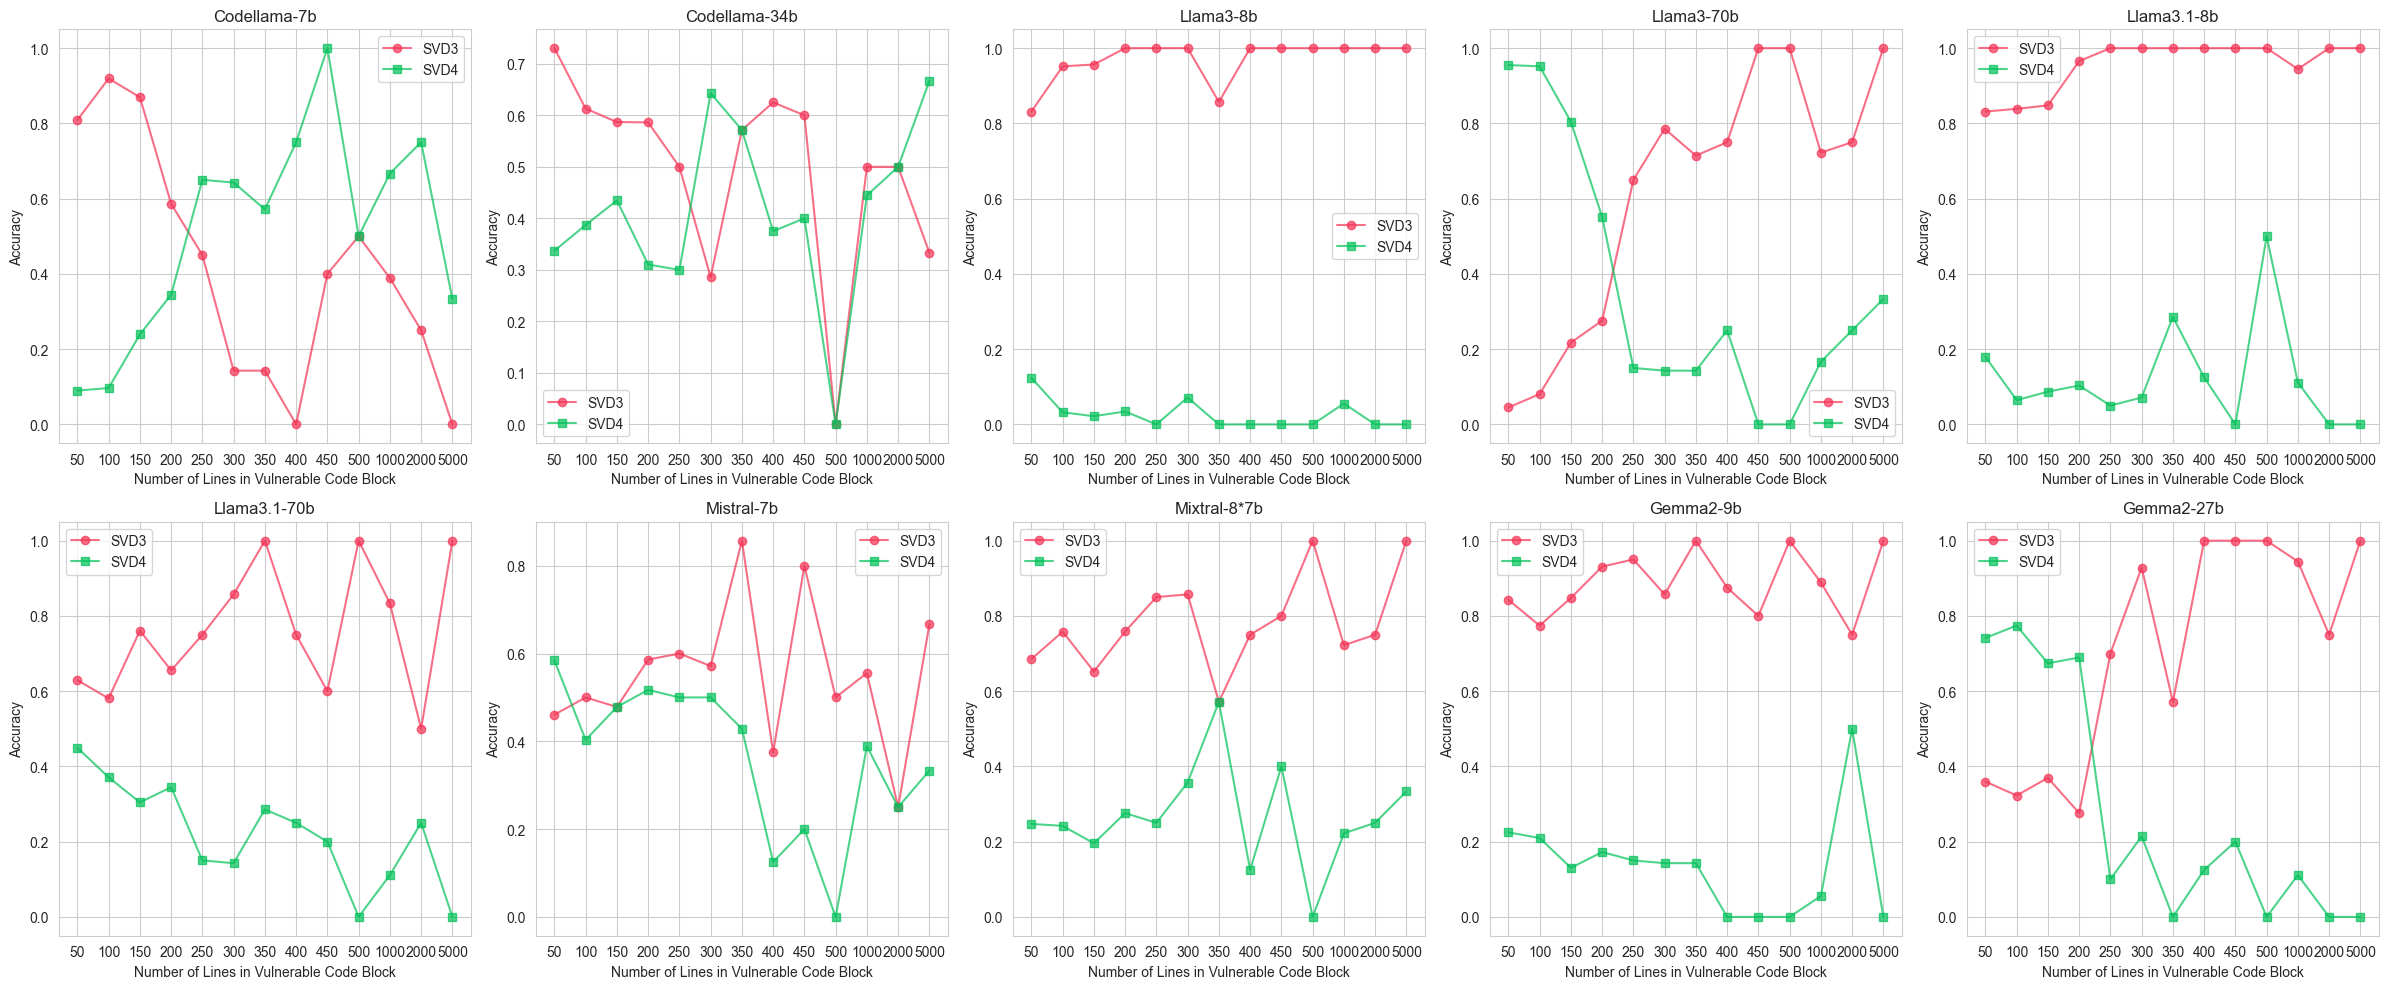

In [32]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

model_files = {
    'Codellama-7b': 'output/database_codellama-7b-instruct.sqlite',
    'Codellama-34b': 'output/database_codellama-34b-instruct.sqlite',
    'Llama3-8b': 'output/database_llama3-8b-instruct.sqlite',
    'Llama3-70b': 'output/database_llama3-70b-instruct.sqlite',
    'Llama3.1-8b': 'output/database_llama3.1-8b.sqlite',
    'Llama3.1-70b': 'output/database_llama3.1-70b.sqlite',
    'Mistral-7b': 'output/database_mistral-7b-instruct.sqlite',
    'Mixtral-8*7b': 'output/database_mixtral-8M7b-instruct.sqlite',
    'Gemma2-9b': 'output/database_gemma2-9b.sqlite',
    'Gemma2-27b': 'output/database_gemma2-27b.sqlite'
}

# Ground truths
ground_truths = {
    "IS_VULNERABLE_Vuln": 1,
    "IS_VULNERABLE_Patch": 0
}

# Bin ranges for the number of lines (changed to increments of 50)
bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 1000, 2000, 5000]
bin_labels = [str(b) for b in bins[1:]]  # Create labels as strings of exact bin edges

def calculate_accuracy(data, column, ground_truth):
    data['Correct'] = data[column] == ground_truth
    grouped_data = data.groupby('NUM_LINES_BINNED')['Correct'].mean().reset_index()
    return grouped_data

# Number of models
num_models = len(model_files)
# Number of columns (5 subplots per row)
num_cols = 5
# Number of rows needed
num_rows = (num_models + num_cols - 1) // num_cols

# Create subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(24, num_rows * 5))

# Flatten axs if it's not already flat
if num_rows == 1:
    axs = axs.reshape(-1)
elif num_cols == 1:
    axs = axs.reshape(-1)
else:
    axs = axs.flatten()

for idx, (model_name, db_file) in enumerate(model_files.items()):
    # Establish a connection to the database
    conn = sqlite3.connect(db_file)
    cursor = conn.cursor()

    # Define the query to fetch necessary columns
    query = """
    SELECT IS_VULNERABLE_Vuln, IS_VULNERABLE_Patch, NUM_LINES_IN_VULNERABLE_CODE_BLOCK
    FROM vulnerabilities
    """
    data = pd.read_sql_query(query, conn)
    conn.close()

    # Bin the number of lines into ranges
    data['NUM_LINES_BINNED'] = pd.cut(data['NUM_LINES_IN_VULNERABLE_CODE_BLOCK'], bins, labels=bin_labels, include_lowest=True)

    # Calculate accuracy for each column
    accuracy_vuln = calculate_accuracy(data, 'IS_VULNERABLE_Vuln', ground_truths['IS_VULNERABLE_Vuln'])
    accuracy_patch = calculate_accuracy(data, 'IS_VULNERABLE_Patch', ground_truths['IS_VULNERABLE_Patch'])

    # Plot the data
    axs[idx].plot(accuracy_vuln['NUM_LINES_BINNED'].astype(str), accuracy_vuln['Correct'], label='SVD3', marker='o', linestyle='-', color='#F53255', alpha=0.7)
    axs[idx].plot(accuracy_patch['NUM_LINES_BINNED'].astype(str), accuracy_patch['Correct'], label='SVD4', marker='s', linestyle='-', color='#01C159', alpha=0.7)

    axs[idx].set_xlabel('Number of Lines in Vulnerable Code Block')
    axs[idx].set_ylabel('Accuracy')
    axs[idx].set_title(f'{model_name}')
    axs[idx].legend()
    axs[idx].grid(True)

# Remove empty subplots
for i in range(num_models, num_rows * num_cols):
    fig.delaxes(axs[i])

plt.tight_layout()
# Save the plot as a PDF
plt.savefig('figs/acc-code-length.pdf')
plt.show()


C:\Users\Azibaeir\AppData\Local\Temp\1\ipykernel_13040\1340123127.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby('NUM_LINES_BINNED')['Correct'].mean().reset_index()
C:\Users\Azibaeir\AppData\Local\Temp\1\ipykernel_13040\1340123127.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby('NUM_LINES_BINNED')['Correct'].mean().reset_index()
C:\Users\Azibaeir\AppData\Local\Temp\1\ipykernel_13040\1340123127.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to reta

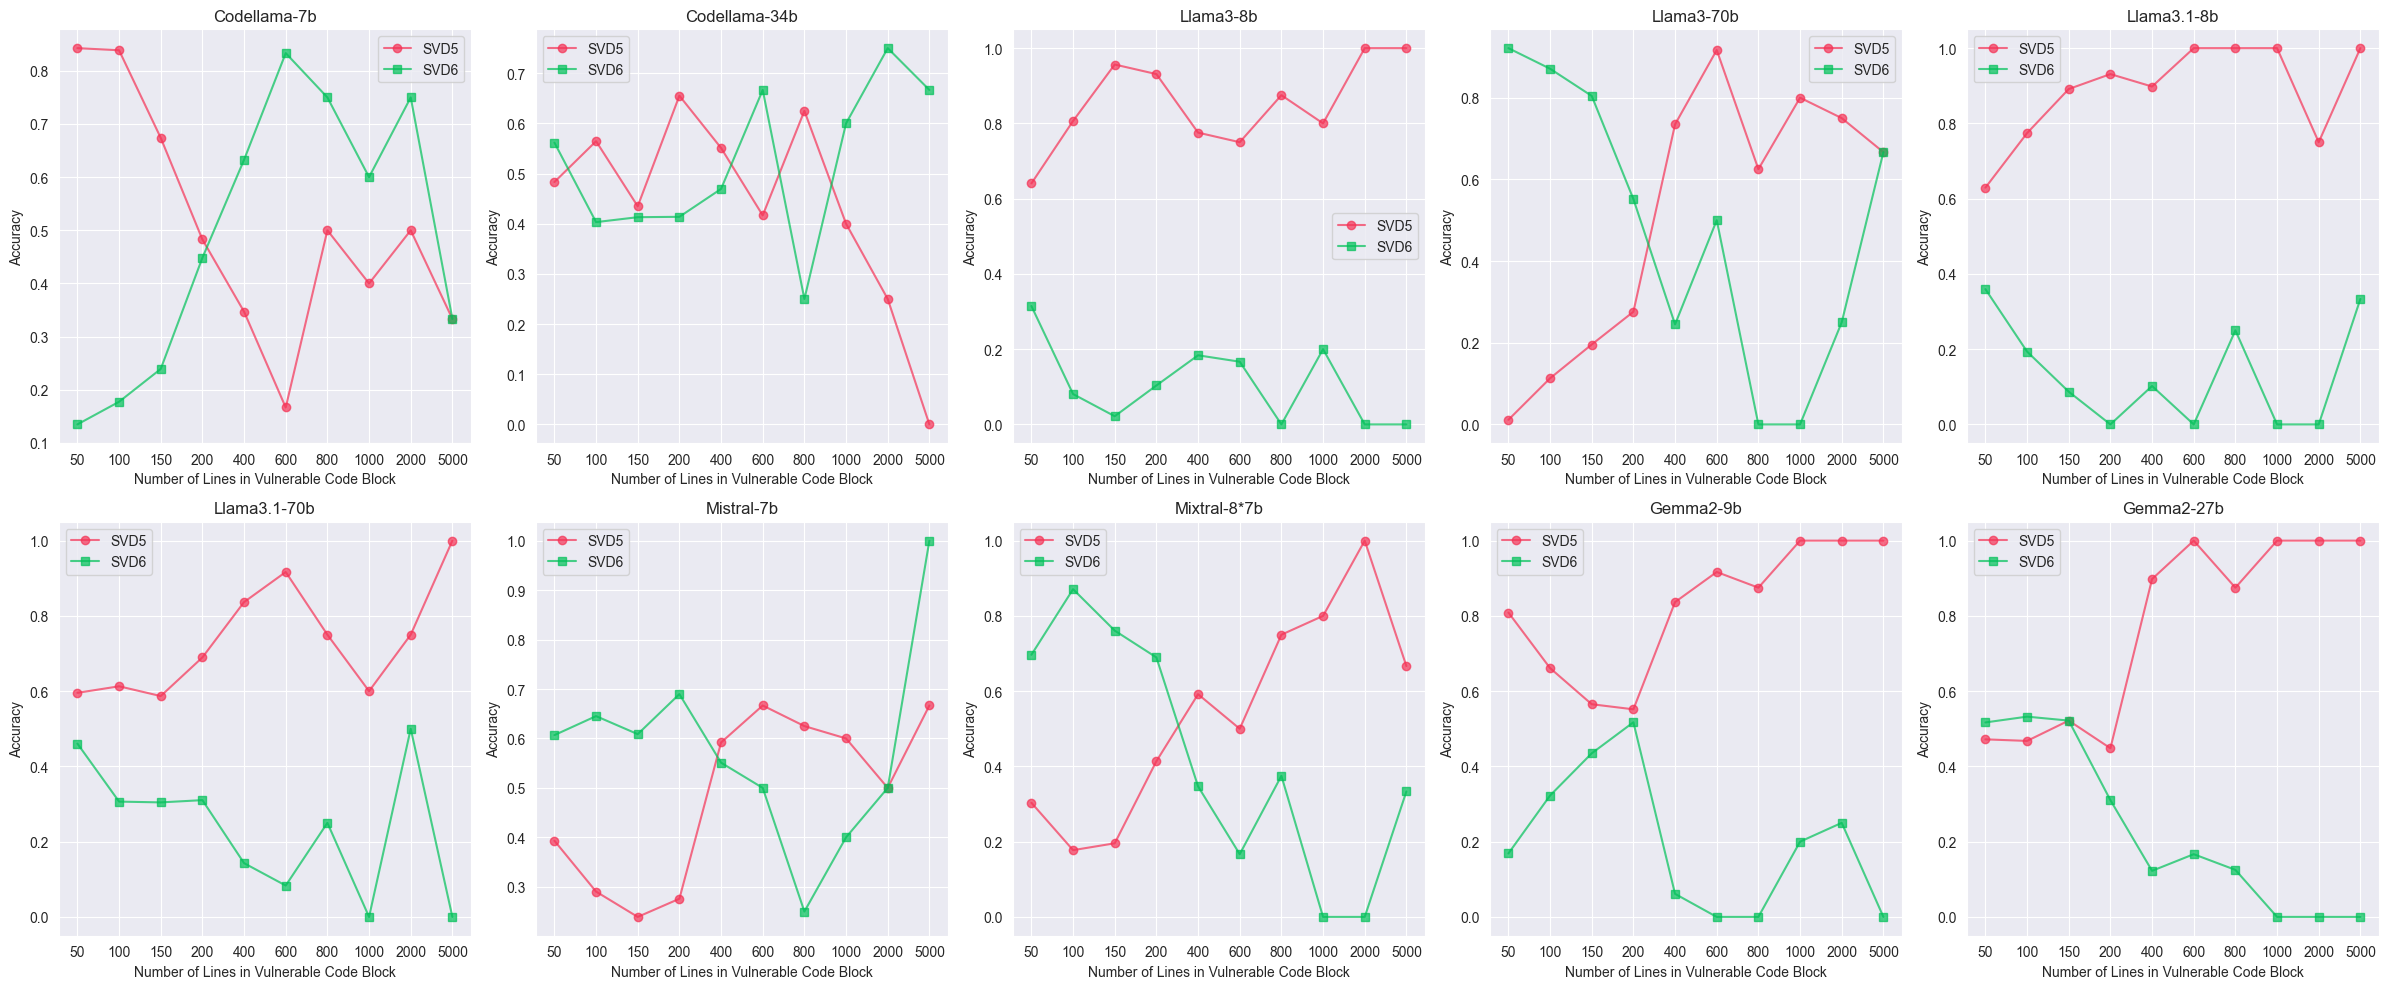

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

model_files = {
    'Codellama-7b': 'output/database_codellama-7b-instruct.sqlite',
    'Codellama-34b': 'output/database_codellama-34b-instruct.sqlite',
    'Llama3-8b': 'output/database_llama3-8b-instruct.sqlite',
    'Llama3-70b': 'output/database_llama3-70b-instruct.sqlite',
    'Llama3.1-8b': 'output/database_llama3.1-8b.sqlite',
    'Llama3.1-70b': 'output/database_llama3.1-70b.sqlite',
    'Mistral-7b': 'output/database_mistral-7b-instruct.sqlite',
    'Mixtral-8*7b': 'output/database_mixtral-8M7b-instruct.sqlite',
    'Gemma2-9b': 'output/database_gemma2-9b.sqlite',
    'Gemma2-27b': 'output/database_gemma2-27b.sqlite'
}

# Ground truths
ground_truths = {
    "IS_VULNERABLE_Vuln_CVE_CWE": 1,
    "IS_VULNERABLE_Patch_CVE_CWE": 0
}

# Bin ranges: every 50 lines up to 200, then every 200 lines
bins = list(range(0, 201, 50)) + list(range(400, 1001, 200)) + [2000, 5000]
bin_labels = [str(b) for b in bins[1:]]  # Create labels as strings of exact bin edges

def calculate_accuracy(data, column, ground_truth):
    data['Correct'] = data[column] == ground_truth
    grouped_data = data.groupby('NUM_LINES_BINNED')['Correct'].mean().reset_index()
    return grouped_data

# Number of models
num_models = len(model_files)
# Number of columns (5 subplots per row)
num_cols = 5
# Number of rows needed
num_rows = (num_models + num_cols - 1) // num_cols

# Create subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(24, num_rows * 5))

# Flatten axs if it's not already flat
if num_rows == 1:
    axs = axs.reshape(-1)
elif num_cols == 1:
    axs = axs.reshape(-1)
else:
    axs = axs.flatten()

for idx, (model_name, db_file) in enumerate(model_files.items()):
    # Establish a connection to the database
    conn = sqlite3.connect(db_file)
    cursor = conn.cursor()

    # Define the query to fetch necessary columns
    query = """
    SELECT IS_VULNERABLE_Vuln_CVE_CWE, IS_VULNERABLE_Patch_CVE_CWE, NUM_LINES_IN_VULNERABLE_CODE_BLOCK
    FROM vulnerabilities
    """
    data = pd.read_sql_query(query, conn)
    conn.close()

    # Bin the number of lines into ranges
    data['NUM_LINES_BINNED'] = pd.cut(data['NUM_LINES_IN_VULNERABLE_CODE_BLOCK'], bins, labels=bin_labels, include_lowest=True)

    # Calculate accuracy for each column
    accuracy_vuln = calculate_accuracy(data, 'IS_VULNERABLE_Vuln_CVE_CWE', ground_truths['IS_VULNERABLE_Vuln_CVE_CWE'])
    accuracy_patch = calculate_accuracy(data, 'IS_VULNERABLE_Patch_CVE_CWE', ground_truths['IS_VULNERABLE_Patch_CVE_CWE'])

    # Plot the data
    axs[idx].plot(accuracy_vuln['NUM_LINES_BINNED'].astype(str), accuracy_vuln['Correct'], label='SVD5', marker='o', linestyle='-', color='#F53255', alpha=0.7)
    axs[idx].plot(accuracy_patch['NUM_LINES_BINNED'].astype(str), accuracy_patch['Correct'], label='SVD6', marker='s', linestyle='-', color='#01C159', alpha=0.7)

    axs[idx].set_xlabel('Number of Lines in Vulnerable Code Block')
    axs[idx].set_ylabel('Accuracy')
    axs[idx].set_title(f'{model_name}')
    axs[idx].legend()
    axs[idx].grid(True)

# Remove empty subplots
for i in range(num_models, num_rows * num_cols):
    fig.delaxes(axs[i])

plt.tight_layout()
# Save the plot as a PDF
plt.savefig('figs/acc-code-length.pdf')
plt.show()


Added/Deleted lines

C:\Users\Azibaeir\AppData\Local\Temp\1\ipykernel_15580\1717459219.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(bin_column)['Correct'].mean().reset_index()
C:\Users\Azibaeir\AppData\Local\Temp\1\ipykernel_15580\1717459219.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(bin_column)['Correct'].mean().reset_index()
C:\Users\Azibaeir\AppData\Local\Temp\1\ipykernel_15580\1717459219.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behav

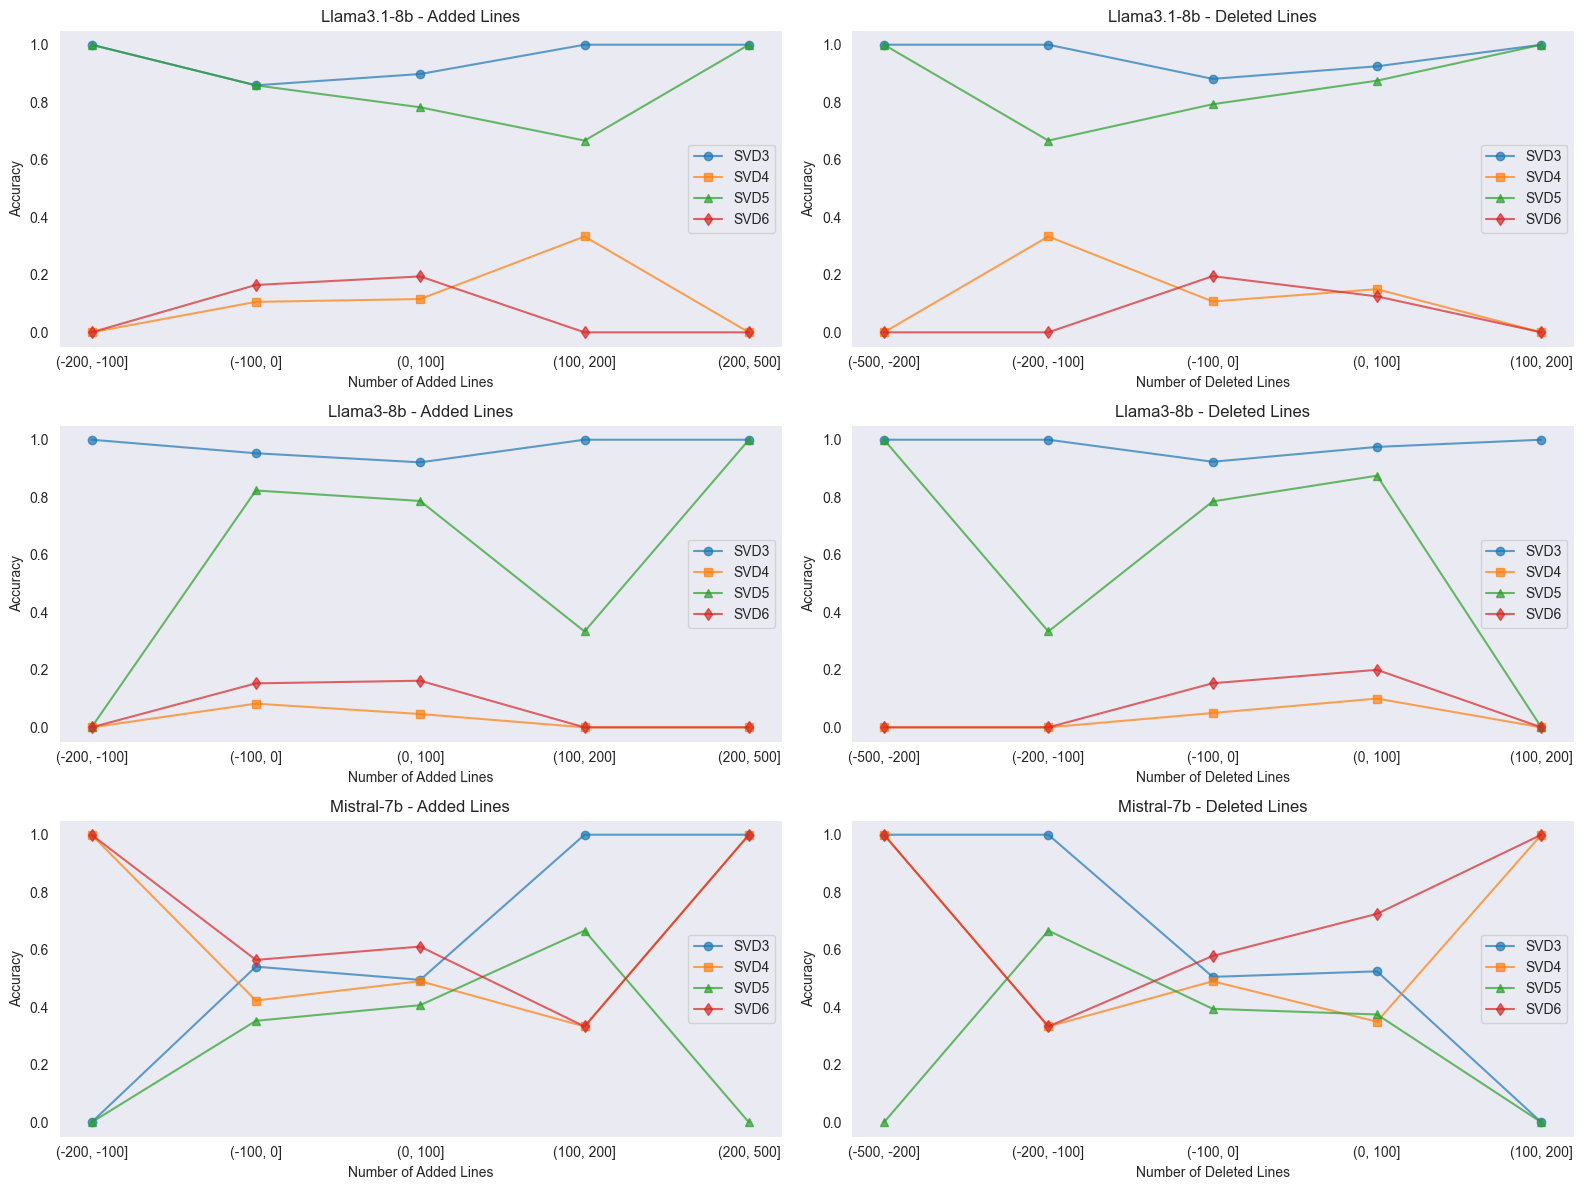

In [31]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

model_files = {
    'Llama3.1-8b': 'output/database_llama3.1-8b.sqlite',
    'Llama3-8b': 'output/database_llama3-8b-instruct.sqlite',
    'Mistral-7b': 'output/database_mistral-7b-instruct.sqlite'
}

# Define bins
bins_added = [-200, -100, 0, 100, 200, 500, 1000, 2000]
bins_deleted = [-2000, -1000, -500, -200, -100, 0, 100, 200]

# Ground truths
ground_truths = {
    "IS_VULNERABLE_Vuln": 1,
    "IS_VULNERABLE_Patch": 0,
    "IS_VULNERABLE_Vuln_CVE_CWE": 1,
    "IS_VULNERABLE_Patch_CVE_CWE": 0
}

def calculate_accuracy(data, column, ground_truth, bin_column):
    data['Correct'] = data[column] == ground_truth
    grouped_data = data.groupby(bin_column)['Correct'].mean().reset_index()
    return grouped_data

# Number of models
num_models = len(model_files)
fig, axs = plt.subplots(num_models, 2, figsize=(16, num_models * 4))

for idx, (model_name, db_file) in enumerate(model_files.items()):
    # Establish a connection to the database
    conn = sqlite3.connect(db_file)
    cursor = conn.cursor()

    # Define the query to fetch necessary columns
    query = """
    SELECT IS_VULNERABLE_Vuln, IS_VULNERABLE_Patch, IS_VULNERABLE_Vuln_CVE_CWE, 
           IS_VULNERABLE_Patch_CVE_CWE, NUM_LINES_IN_VULNERABLE_CODE_BLOCK,
           NUM_LINES_IN_PATCHED_CODE_BLOCK, NUM_LINES_IN_PATCHED_BLOCK_LLM, NUM_LINES_IN_PATCHED_BLOCK_LLM_F
    FROM vulnerabilities
    """
    data = pd.read_sql_query(query, conn)
    conn.close()

    # Calculate the number of added and deleted lines
    data['Added_Lines'] = data['NUM_LINES_IN_PATCHED_CODE_BLOCK'] - data['NUM_LINES_IN_VULNERABLE_CODE_BLOCK']
    data['Deleted_Lines'] = data['NUM_LINES_IN_VULNERABLE_CODE_BLOCK'] - data['NUM_LINES_IN_PATCHED_CODE_BLOCK']

    # Bin the data
    data['Added_Lines_Binned'] = pd.cut(data['Added_Lines'], bins_added)
    data['Deleted_Lines_Binned'] = pd.cut(data['Deleted_Lines'], bins_deleted)

    # Calculate accuracy for each bin
    accuracy_added_vuln = calculate_accuracy(data, 'IS_VULNERABLE_Vuln', ground_truths['IS_VULNERABLE_Vuln'], 'Added_Lines_Binned')
    accuracy_added_patch = calculate_accuracy(data, 'IS_VULNERABLE_Patch', ground_truths['IS_VULNERABLE_Patch'], 'Added_Lines_Binned')
    accuracy_added_vuln_cve_cwe = calculate_accuracy(data, 'IS_VULNERABLE_Vuln_CVE_CWE', ground_truths['IS_VULNERABLE_Vuln_CVE_CWE'], 'Added_Lines_Binned')
    accuracy_added_patch_cve_cwe = calculate_accuracy(data, 'IS_VULNERABLE_Patch_CVE_CWE', ground_truths['IS_VULNERABLE_Patch_CVE_CWE'], 'Added_Lines_Binned')

    accuracy_deleted_vuln = calculate_accuracy(data, 'IS_VULNERABLE_Vuln', ground_truths['IS_VULNERABLE_Vuln'], 'Deleted_Lines_Binned')
    accuracy_deleted_patch = calculate_accuracy(data, 'IS_VULNERABLE_Patch', ground_truths['IS_VULNERABLE_Patch'], 'Deleted_Lines_Binned')
    accuracy_deleted_vuln_cve_cwe = calculate_accuracy(data, 'IS_VULNERABLE_Vuln_CVE_CWE', ground_truths['IS_VULNERABLE_Vuln_CVE_CWE'], 'Deleted_Lines_Binned')
    accuracy_deleted_patch_cve_cwe = calculate_accuracy(data, 'IS_VULNERABLE_Patch_CVE_CWE', ground_truths['IS_VULNERABLE_Patch_CVE_CWE'], 'Deleted_Lines_Binned')

    # Plot the data for added lines
    axs[idx, 0].plot(accuracy_added_vuln['Added_Lines_Binned'].astype(str), accuracy_added_vuln['Correct'], label='SVD3', marker='o', linestyle='-', alpha=0.7)
    axs[idx, 0].plot(accuracy_added_patch['Added_Lines_Binned'].astype(str), accuracy_added_patch['Correct'], label='SVD4', marker='s', linestyle='-', alpha=0.7)
    axs[idx, 0].plot(accuracy_added_vuln_cve_cwe['Added_Lines_Binned'].astype(str), accuracy_added_vuln_cve_cwe['Correct'], label='SVD5', marker='^', linestyle='-', alpha=0.7)
    axs[idx, 0].plot(accuracy_added_patch_cve_cwe['Added_Lines_Binned'].astype(str), accuracy_added_patch_cve_cwe['Correct'], label='SVD6', marker='d', linestyle='-', alpha=0.7)
    axs[idx, 0].set_xlabel('Number of Added Lines')
    axs[idx, 0].set_ylabel('Accuracy')
    axs[idx, 0].set_title(f'{model_name} - Added Lines')
    axs[idx, 0].legend()
    axs[idx, 0].grid(False)

    # Plot the data for deleted lines
    axs[idx, 1].plot(accuracy_deleted_vuln['Deleted_Lines_Binned'].astype(str), accuracy_deleted_vuln['Correct'], label='SVD3', marker='o', linestyle='-', alpha=0.7)
    axs[idx, 1].plot(accuracy_deleted_patch['Deleted_Lines_Binned'].astype(str), accuracy_deleted_patch['Correct'], label='SVD4', marker='s', linestyle='-', alpha=0.7)
    axs[idx, 1].plot(accuracy_deleted_vuln_cve_cwe['Deleted_Lines_Binned'].astype(str), accuracy_deleted_vuln_cve_cwe['Correct'], label='SVD5', marker='^', linestyle='-', alpha=0.7)
    axs[idx, 1].plot(accuracy_deleted_patch_cve_cwe['Deleted_Lines_Binned'].astype(str), accuracy_deleted_patch_cve_cwe['Correct'], label='SVD6', marker='d', linestyle='-', alpha=0.7)
    axs[idx, 1].set_xlabel('Number of Deleted Lines')
    axs[idx, 1].set_ylabel('Accuracy')
    axs[idx, 1].set_title(f'{model_name} - Deleted Lines')
    axs[idx, 1].legend()
    axs[idx, 1].grid(False)

plt.tight_layout()
plt.show()


## Abstraction level

In [4]:
import sqlite3
import pandas as pd
import glob
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import os
from scipy import stats

def check_database_schema(db_path):
    """Check database schema and return table name and columns"""
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [table[0] for table in cursor.fetchall()]
        
        table_name = None
        for table in tables:
            if 'vulnerabilit' in table.lower():
                table_name = table
                break
        
        if not table_name and tables:
            table_name = tables[0]
        
        if not table_name:
            conn.close()
            return None, []
        
        cursor.execute(f"PRAGMA table_info({table_name})")
        columns = [col[1] for col in cursor.fetchall()]
        
        conn.close()
        return table_name, columns
    except Exception as e:
        print(f"Error checking database schema: {e}")
        return None, []

def find_model_databases():
    """Find all model database files in both output directories"""
    output_dirs = [
        "/home/azibaeir/Research/VulnLLMEval-SANER/output/",
        "/home/azibaeir/Research/VulnLLMEval-SANER/output/leakagefree"
    ]
    
    model_files = {}
    
    # Updated model patterns for your 6 models - adding Gemma
    model_patterns = {
        'Codellama': ['codellama', 'code-llama', 'code_llama'],
        'Deepseek': ['deepseek', 'deep_seek'],
        'Llama': ['llama3', 'llama-3', 'llama_3', 'llama'],
        'Mistral': ['mistral'],
        'Qwen3': ['qwen3', 'qwen-3', 'qwen2.5', 'qwen_3', 'qwen'],
        'Starcoder': ['starcoder', 'star-coder', 'star_coder', 'starcoder2'],
        'Gemma': ['gemma']  # Added Gemma pattern
    }
    
    for output_dir in output_dirs:
        if not os.path.exists(output_dir):
            print(f"Output directory not found: {output_dir}")
            continue
        
        print(f"Searching in: {output_dir}")
        
        # Determine if this is the leakage-free directory
        is_leakagefree = "leakagefree" in output_dir
        
        # List all files in the directory
        try:
            files = os.listdir(output_dir)
            print(f"  Found {len(files)} files total")
            sqlite_files = [f for f in files if f.endswith('.sqlite')]
            print(f"  Found {len(sqlite_files)} SQLite files: {sqlite_files}")
        except Exception as e:
            print(f"  Error listing files: {e}")
            continue
        
        for file in files:
            if file.endswith('.sqlite'):
                file_lower = file.lower()
                print(f"  Checking file: {file}")
                
                # Try to match with model patterns
                matched_model = None
                for model_name, patterns in model_patterns.items():
                    if any(pattern.lower() in file_lower for pattern in patterns):
                        matched_model = model_name
                        print(f"    Matched with {model_name} using pattern: {[p for p in patterns if p.lower() in file_lower]}")
                        break
                
                if matched_model:
                    # Create separate entries for regular and leakage-free databases
                    if is_leakagefree:
                        full_model_name = f"{matched_model}_leakagefree"
                    else:
                        full_model_name = matched_model
                    
                    model_files[full_model_name] = os.path.join(output_dir, file)
                    print(f"    Added: {full_model_name} -> {file}")
                else:
                    print(f"    No match found for: {file}")
    
    print(f"\nTotal model databases found: {len(model_files)}")
    for model, path in model_files.items():
        print(f"  {model}: {os.path.basename(path)}")
    
    return model_files
def calculate_metrics(y_true, y_pred):
    """Calculate classification metrics with proper averaging for multiclass"""
    from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
    
    # Handle the case where predictions might be non-binary
    unique_values = set(y_true + y_pred)
    
    if len(unique_values) <= 2:
        # Binary classification
        average_method = 'binary'
    else:
        # Multiclass classification - use macro averaging
        average_method = 'macro'
    
    try:
        precision = precision_score(y_true, y_pred, average=average_method, zero_division=0) * 100
        recall = recall_score(y_true, y_pred, average=average_method, zero_division=0) * 100
        accuracy = accuracy_score(y_true, y_pred) * 100
        f1 = f1_score(y_true, y_pred, average=average_method, zero_division=0) * 100
    except Exception as e:
        print(f"Error in metrics calculation: {e}")
        # Return default values if calculation fails
        precision = recall = accuracy = f1 = 0.0
    
    return {
        'precision': round(precision, 2),
        'recall': round(recall, 2),
        'accuracy': round(accuracy, 2),
        'F1 score': round(f1, 2)
    }

def process_database(db_file, model_name):
    """Process a single database file and return comprehensive results for all abstraction levels"""
    import sqlite3
    import pandas as pd
    
    try:
        conn = sqlite3.connect(db_file)
        cursor = conn.cursor()
        
        # Check available tables
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [table[0] for table in cursor.fetchall()]
        
        # Find the vulnerabilities table
        table_name = None
        if 'vulnerabilities' in tables:
            table_name = 'vulnerabilities'
        elif 'vulnerability' in tables:
            table_name = 'vulnerability'
        elif tables:
            table_name = tables[0]
        
        if not table_name:
            conn.close()
            return [], {}
        
        # Enhanced query to get all required columns including CWE and vulnerability details
        query = f"""
        SELECT
            IS_VULNERABLE_Vuln,
            IS_VULNERABLE_Patch,
            IS_VULNERABLE_Vuln_CVE_CWE,
            IS_VULNERABLE_Patch_CVE_CWE,
            NUM_FILES_CHANGED,
            NUM_FUNCTIONS_CHANGED,
            VULNERABILITY_CWE,
            VULNERABILITY_CVE,
            COMMIT_HASH,
            NUM_LINES_IN_VULNERABLE_CODE_BLOCK,
            NUM_LINES_IN_PATCHED_CODE_BLOCK
        FROM {table_name}
        WHERE IS_VULNERABLE_Vuln IS NOT NULL
          AND IS_VULNERABLE_Patch IS NOT NULL
          AND IS_VULNERABLE_Vuln_CVE_CWE IS NOT NULL
          AND IS_VULNERABLE_Patch_CVE_CWE IS NOT NULL
          AND NUM_FILES_CHANGED IS NOT NULL
          AND NUM_FUNCTIONS_CHANGED IS NOT NULL
        """

        df = pd.read_sql_query(query, conn)
        conn.close()

        if df.empty:
            return [], {}
        
        # Categorize by abstraction level
        def categorize_abstraction(row):
            files = int(row['NUM_FILES_CHANGED'])
            functions = int(row['NUM_FUNCTIONS_CHANGED'])
            
            if files == 1 and functions <= 1:  # 1 function or less in single file
                return 'Level 1: Single Function'
            elif files == 1 and functions > 1:  # Multiple functions in single file
                return 'Level 2: Multiple Functions'
            else:  # Multiple files (regardless of functions)
                return 'Level 3: Multiple Files'
        
        df['abstraction_level'] = df.apply(categorize_abstraction, axis=1)
        
        # Define the tasks and their expected values
        tasks = [
            ('IS_VULNERABLE_Vuln', 1, 'SVD3'),      # Should be 1 (vulnerable)
            ('IS_VULNERABLE_Patch', 0, 'SVD4'),     # Should be 0 (not vulnerable)
            ('IS_VULNERABLE_Vuln_CVE_CWE', 1, 'SVD5'),   # Should be 1 (vulnerable)
            ('IS_VULNERABLE_Patch_CVE_CWE', 0, 'SVD6')   # Should be 0 (not vulnerable)
        ]
        
        results = []
        detailed_analysis = {
            'model': model_name,
            'abstraction_breakdown': {},
            'cwe_analysis': {},
            'error_patterns': {},
            'task_performance': {}
        }
        
        # Process each abstraction level
        abstraction_levels = ['Level 1: Single Function', 'Level 2: Multiple Functions', 'Level 3: Multiple Files']
        
        for abstraction_level in abstraction_levels:
            level_data = df[df['abstraction_level'] == abstraction_level]
            
            if level_data.empty:
                continue
            
            
            # Overall metrics for this abstraction level
            all_y_true = []
            all_y_pred = []
            task_results = {}
            
            # Analyze each task separately
            for task_col, expected_value, task_name in tasks:
                y_true = [expected_value] * len(level_data)
                
                # Handle string concatenated predictions 
                y_pred_raw = level_data[task_col].tolist()
                y_pred = []
                
                # Check different data formats and handle appropriately
                if len(y_pred_raw) == 1 and isinstance(y_pred_raw[0], str) and len(y_pred_raw[0]) > 1:
                    # Single concatenated string for all samples
                    concat_str = y_pred_raw[0]
                    # Extract individual predictions (each character should be 0 or 1)
                    individual_preds = [int(char) for char in concat_str if char in '01']

                    # Take only as many predictions as we have samples
                    y_pred = individual_preds[:len(level_data)]

                    # If we don't have enough predictions, pad with expected value
                    while len(y_pred) < len(level_data):
                        y_pred.append(expected_value)

                elif len(y_pred_raw) == len(level_data) and any(isinstance(pred, str) and len(pred) > 10 for pred in y_pred_raw):
                    # Each row has a concatenated string - take first character of each
                    for pred in y_pred_raw:
                        if isinstance(pred, str) and len(pred) > 0:
                            try:
                                y_pred.append(int(pred[0]) if pred[0] in '01' else expected_value)
                            except (ValueError, IndexError):
                                y_pred.append(expected_value)
                        else:
                            try:
                                y_pred.append(int(pred))
                            except (ValueError, TypeError):
                                y_pred.append(expected_value)

                elif len(y_pred_raw) > len(level_data):
                    # More predictions than samples - might be concatenated differently
                    for i, pred in enumerate(y_pred_raw[:len(level_data)]):
                        try:
                            if isinstance(pred, str):
                                if len(pred) == 1 and pred in '01':
                                    y_pred.append(int(pred))
                                else:
                                    y_pred.append(expected_value)
                            else:
                                y_pred.append(int(pred))
                        except (ValueError, TypeError):
                            y_pred.append(expected_value)
                else:
                    # Normal case - process each prediction
                    for pred in y_pred_raw:
                        try:
                            if isinstance(pred, str):
                                if len(pred) == 1 and pred in '01':
                                    y_pred.append(int(pred))
                                elif len(pred) > 1:
                                    # Long string - take first valid character
                                    first_valid = next((int(c) for c in pred if c in '01'), expected_value)
                                    y_pred.append(first_valid)
                                else:
                                    y_pred.append(expected_value)
                            else:
                                y_pred.append(int(pred))
                        except (ValueError, TypeError):
                            y_pred.append(expected_value)
                
                # Ensure y_pred has same length as y_true
                if len(y_pred) != len(y_true):
                    # Pad or truncate to match
                    if len(y_pred) < len(y_true):
                        y_pred.extend([expected_value] * (len(y_true) - len(y_pred)))
                    else:
                        y_pred = y_pred[:len(y_true)]

                # Ensure all predictions are integers and clean
                clean_y_pred = []
                for p in y_pred:
                    try:
                        if isinstance(p, str):
                            if len(p) == 1 and p in '01':
                                clean_y_pred.append(int(p))
                            elif p.isdigit() and len(p) <= 2:  # Allow small numbers
                                clean_y_pred.append(int(p))
                            else:
                                clean_y_pred.append(expected_value)
                        elif isinstance(p, (int, float)):
                            clean_y_pred.append(int(p))
                        else:
                            clean_y_pred.append(expected_value)
                    except (ValueError, TypeError):
                        clean_y_pred.append(expected_value)

                y_pred = clean_y_pred
                
                all_y_true.extend(y_true)
                all_y_pred.extend(y_pred)
                
                # Calculate task-specific metrics
                # Ensure y_pred is properly numeric for sklearn
                clean_y_pred = [int(p) for p in y_pred]
                clean_y_true = [int(t) for t in y_true]

                task_accuracy = accuracy_score(clean_y_true, clean_y_pred) * 100
                task_results[task_name] = {
                    'accuracy': round(task_accuracy, 2),
                    'samples': len(level_data),
                    'correct': sum(1 for t, p in zip(clean_y_true, clean_y_pred) if t == p),
                    'false_positives': sum(1 for t, p in zip(clean_y_true, clean_y_pred) if t == 0 and p == 1),
                    'false_negatives': sum(1 for t, p in zip(clean_y_true, clean_y_pred) if t == 1 and p == 0)
                }
            
            # Calculate overall metrics for this abstraction level
            try:
                # Ensure all values are clean integers before metrics calculation
                clean_all_y_true = [int(y) if isinstance(y, (int, float, str)) and str(y).isdigit() else 1 for y in all_y_true]
                clean_all_y_pred = [int(y) if isinstance(y, (int, float, str)) and str(y).isdigit() else 0 for y in all_y_pred]

                # Final cleanup to ensure all values are numeric for sklearn
                final_y_true = [int(x) for x in clean_all_y_true]
                final_y_pred = [int(x) for x in clean_all_y_pred]

                metrics = calculate_metrics(final_y_true, final_y_pred)
                
                results.append({
                    'Abstraction Level': abstraction_level,
                    'Model': model_name,
                    'precision': metrics['precision'],
                    'recall': metrics['recall'],
                    'accuracy': metrics['accuracy'],
                    'F1 score': metrics['F1 score'],
                    'Sample Count': len(level_data),
                    'Total Evaluations': len(level_data) * len(tasks),
                    'SVD3_Accuracy': task_results.get('SVD3', {}).get('accuracy', 0),
                    'SVD4_Accuracy': task_results.get('SVD4', {}).get('accuracy', 0),
                    'SVD5_Accuracy': task_results.get('SVD5', {}).get('accuracy', 0),
                    'SVD6_Accuracy': task_results.get('SVD6', {}).get('accuracy', 0)
                })
                
                # Store detailed analysis
                detailed_analysis['abstraction_breakdown'][abstraction_level] = {
                    'overall_metrics': metrics,
                    'task_performance': task_results,
                    'sample_count': len(level_data),
                    'avg_files': level_data['NUM_FILES_CHANGED'].mean(),
                    'avg_functions': level_data['NUM_FUNCTIONS_CHANGED'].mean(),
                    'avg_vuln_lines': level_data['NUM_LINES_IN_VULNERABLE_CODE_BLOCK'].mean() if 'NUM_LINES_IN_VULNERABLE_CODE_BLOCK' in level_data.columns else 0,
                    'avg_patch_lines': level_data['NUM_LINES_IN_PATCHED_CODE_BLOCK'].mean() if 'NUM_LINES_IN_PATCHED_CODE_BLOCK' in level_data.columns else 0
                }
                
                # CWE analysis by abstraction level
                if 'VULNERABILITY_CWE' in level_data.columns:
                    cwe_breakdown = {}
                    for cwe in level_data['VULNERABILITY_CWE'].unique():
                        if pd.isna(cwe):
                            continue
                        cwe_data = level_data[level_data['VULNERABILITY_CWE'] == cwe]
                        if len(cwe_data) > 0:
                            cwe_y_true = []
                            cwe_y_pred = []
                            for task_col, expected_value, _ in tasks:
                                cwe_y_true.extend([expected_value] * len(cwe_data))
                                cwe_y_pred.extend(cwe_data[task_col].tolist())
                            
                            if cwe_y_true:
                                cwe_accuracy = accuracy_score(cwe_y_true, cwe_y_pred) * 100
                                cwe_breakdown[str(cwe)] = {
                                    'accuracy': round(cwe_accuracy, 2),
                                    'samples': len(cwe_data)
                                }
                    
                    detailed_analysis['cwe_analysis'][abstraction_level] = cwe_breakdown
                
                
            except Exception as e:
                print(f"Error calculating metrics for {model_name} - {abstraction_level}: {e}")
                continue
        
        return results, detailed_analysis
        
    except Exception as e:
        print(f"Error processing {model_name}: {e}")
        return [], {}


def process_database_set(models_dict, set_name):
    """Process a set of databases (either regular or leakage-free)"""
    if not models_dict:
        return None, None

    results = []
    all_detailed_analysis = {}

    for model_name, db_file in models_dict.items():
        if os.path.exists(db_file):
            try:
                model_results, detailed_analysis = process_database(db_file, model_name)
                results.extend(model_results)
                all_detailed_analysis[model_name] = detailed_analysis
            except Exception as e:
                print(f"Error processing {model_name}: {e}")
        else:
            print(f"Database file {db_file} does not exist.")
    
    if results:
        # Create DataFrame
        df = pd.DataFrame(results)
        df = df.sort_values(['Abstraction Level', 'Model'])
        df = df.set_index(['Abstraction Level', 'Model'])
        
        
        # Perform comprehensive analysis
        analyze_abstraction_performance(df, all_detailed_analysis, set_name)
        
        return df, all_detailed_analysis
    else:
        print(f"No results to display for {set_name}!")
        return None, None

def analyze_abstraction_performance(df, detailed_analysis, dataset_name):
    """Comprehensive analysis to answer all research questions about abstraction levels"""
    print(f"\n{'='*90}")
    print(f"RESEARCH QUESTIONS ANALYSIS - {dataset_name}")
    print(f"{'='*90}")
    
    # MAIN RESEARCH QUESTION (RQX)
    print(f"\n{'='*80}")
    print("RQX: HOW DOES CODE ABSTRACTION LEVEL AFFECT LLM VULNERABILITY DETECTION?")
    print(f"{'='*80}")
    
    # Calculate overall abstraction impact
    abstraction_performance = df.groupby('Abstraction Level')['accuracy'].agg(['mean', 'std', 'count']).round(2)
    print("\nOverall Performance by Abstraction Level:")
    print(abstraction_performance)
    
    # Statistical significance test
    from scipy import stats
    level_groups = []
    level_names = ['Level 1: Single Function', 'Level 2: Multiple Functions', 'Level 3: Multiple Files']
    
    for level in level_names:
        if level in df.index.get_level_values('Abstraction Level'):
            level_data = df.xs(level, level=0)['accuracy'].values
            level_groups.append(level_data)
    
    if len(level_groups) >= 2:
        try:
            f_stat, p_value = stats.f_oneway(*level_groups)
            print(f"\nOne-way ANOVA F-statistic: {f_stat:.3f}, p-value: {p_value:.4f}")
            if p_value < 0.05:
                print("✓ Statistically significant difference between abstraction levels (p < 0.05)")
            else:
                print("⚠ No statistically significant difference between abstraction levels (p >= 0.05)")
        except:
            print("Could not perform statistical significance test")
    
    # RQX.1: Performance Degradation Across Abstraction Levels
    print(f"\n{'-'*70}")
    print("RQX.1: PERFORMANCE DEGRADATION ACROSS ABSTRACTION LEVELS")
    print(f"{'-'*70}")
    
    # Performance degradation per model with detailed analysis
    print("\nPer-Model Performance Degradation Analysis:")
    degradation_analysis = {}
    
    # Enhanced model categorization with size and context information
    model_specifications = {
        'Codellama': {'type': 'Code-Specialized', 'size_range': '7B-34B', 'context_window': '16K', 'category': 'Small-Medium Code'},
        'Starcoder': {'type': 'Code-Specialized', 'size_range': '3B-15B', 'context_window': '8K-16K', 'category': 'Small Code'},
        'Qwen3': {'type': 'Code-Specialized', 'size_range': '7B-32B', 'context_window': '32K', 'category': 'Large Code'},
        'Llama': {'type': 'General-Purpose', 'size_range': '8B-70B', 'context_window': '128K', 'category': 'Large General'},
        'Deepseek': {'type': 'General-Purpose', 'size_range': '7B-67B', 'context_window': '64K', 'category': 'Large General'},
        'Mistral': {'type': 'General-Purpose', 'size_range': '7B-22B', 'context_window': '32K', 'category': 'Medium General'},
        'Gemma': {'type': 'General-Purpose', 'size_range': '2B-27B', 'context_window': '8K', 'category': 'Small General'}
    }
    
    for model in df.index.get_level_values('Model').unique():
        model_data = df.xs(model, level=1)
        if len(model_data) >= 2:  # At least 2 levels
            levels = ['Level 1: Single Function', 'Level 2: Multiple Functions', 'Level 3: Multiple Files']
            model_performance = {}
            
            for level in levels:
                if level in model_data.index:
                    model_performance[level] = model_data.loc[level, 'accuracy']
            
            if len(model_performance) >= 2:
                degradation_analysis[model] = model_performance
                level_names = list(model_performance.keys())
                level_values = list(model_performance.values())
                
                # Find model specification
                model_spec = None
                for spec_name, spec in model_specifications.items():
                    if spec_name.lower() in model.lower():
                        model_spec = spec
                        break
                
                print(f"\n{model}:")
                if model_spec:
                    print(f"  [{model_spec['type']}, {model_spec['size_range']}, {model_spec['context_window']} context]")

                for i, (level, acc) in enumerate(model_performance.items()):
                    if i == 0:
                        print(f"  {level}: {acc:.1f}%")
                    else:
                        prev_acc = level_values[i-1]
                        change = acc - prev_acc
                        trend = "↑" if change > 0 else "↓" if change < 0 else "="
                        print(f"  {level}: {acc:.1f}% ({trend}{abs(change):.1f}%)")

                # Calculate degradation metrics
                if len(model_performance) == 3:
                    l1_acc = model_performance['Level 1: Single Function']
                    l2_acc = model_performance['Level 2: Multiple Functions']
                    l3_acc = model_performance['Level 3: Multiple Files']
                    total_degradation = l1_acc - l3_acc
                    l1_l2_degradation = l1_acc - l2_acc
                    l2_l3_degradation = l2_acc - l3_acc
                    print(f"  → Total degradation (L1→L3): {total_degradation:.1f}%")
                    print(f"  → L1→L2: {l1_l2_degradation:.1f}%, L2→L3: {l2_l3_degradation:.1f}%")
    
    # Model robustness ranking with enhanced analysis
    print(f"\n{'-'*60}")
    print("COMPREHENSIVE MODEL ROBUSTNESS ANALYSIS")
    print(f"{'-'*60}")
    
    robustness_scores = {}
    for model, performance in degradation_analysis.items():
        if len(performance) >= 3:  # All three levels
            levels = ['Level 1: Single Function', 'Level 2: Multiple Functions', 'Level 3: Multiple Files']
            if all(level in performance for level in levels):
                l1_acc = performance[levels[0]]
                l2_acc = performance[levels[1]]
                l3_acc = performance[levels[2]]
                
                total_degradation = l1_acc - l3_acc
                l1_l2_degradation = l1_acc - l2_acc
                l2_l3_degradation = l2_acc - l3_acc
                
                # Find model spec for analysis
                model_spec = None
                for spec_name, spec in model_specifications.items():
                    if spec_name.lower() in model.lower():
                        model_spec = spec
                        break
                
                robustness_scores[model] = {
                    'total_degradation': total_degradation,
                    'l1_l2_degradation': l1_l2_degradation,
                    'l2_l3_degradation': l2_l3_degradation,
                    'l1_acc': l1_acc,
                    'l2_acc': l2_acc,
                    'l3_acc': l3_acc,
                    'model_type': model_spec['type'] if model_spec else 'Unknown',
                    'context_window': model_spec['context_window'] if model_spec else 'Unknown',
                    'category': model_spec['category'] if model_spec else 'Unknown'
                }
    
    # Sort by total degradation (least degradation = most robust)
    sorted_robustness = sorted(robustness_scores.items(), key=lambda x: x[1]['total_degradation'])
    
    print("\nRobustness Ranking (by total degradation L1→L3):")
    print(f"{'Rank':<4} {'Model':<20} {'Type':<15} {'Context':<8} {'L1→L3':<8} {'L1→L2':<8} {'L2→L3':<8}")
    print("-" * 80)
    
    for i, (model, scores) in enumerate(sorted_robustness, 1):
        total_deg = scores['total_degradation']
        l1_l2_deg = scores['l1_l2_degradation'] 
        l2_l3_deg = scores['l2_l3_degradation']
        
        print(f"{i:<4} {model:<20} {scores['model_type']:<15} {scores['context_window']:<8} "
              f"{total_deg:>6.1f}% {l1_l2_deg:>6.1f}% {l2_l3_deg:>6.1f}%")
    
    # Answer RQX.1 key questions
    print(f"\n{'='*60}")
    print("RQX.1 KEY FINDINGS:")
    print(f"{'='*60}")
    
    # Find most/least robust models
    if sorted_robustness:
        most_robust = sorted_robustness[0]
        least_robust = sorted_robustness[-1]
        
        print(f"✓ Most Robust Model: {most_robust[0]} ({most_robust[1]['total_degradation']:.1f}% degradation)")
        print(f"✓ Least Robust Model: {least_robust[0]} ({least_robust[1]['total_degradation']:.1f}% degradation)")
    
    # Analyze by model type
    code_specialized = [item for item in sorted_robustness if item[1]['model_type'] == 'Code-Specialized']
    general_purpose = [item for item in sorted_robustness if item[1]['model_type'] == 'General-Purpose']
    
    if code_specialized and general_purpose:
        code_avg_deg = np.mean([item[1]['total_degradation'] for item in code_specialized])
        general_avg_deg = np.mean([item[1]['total_degradation'] for item in general_purpose])
        
        print(f"✓ Code-Specialized Models: {code_avg_deg:.1f}% avg degradation")
        print(f"✓ General-Purpose Models: {general_avg_deg:.1f}% avg degradation")
        
        if code_avg_deg < general_avg_deg:
            print(f"→ Code-specialized models are MORE robust to abstraction increases")
        else:
            print(f"→ General-purpose models are MORE robust to abstraction increases")
    
    # Analyze context window correlation
    context_degradation = {}
    for model, scores in robustness_scores.items():
        context = scores['context_window']
        if context not in context_degradation:
            context_degradation[context] = []
        context_degradation[context].append(scores['total_degradation'])
    
    print(f"\n✓ Context Window vs Robustness:")
    for context, degradations in sorted(context_degradation.items(), 
                                       key=lambda x: int(x[0][:-1]) if x[0][:-1].isdigit() else 0):
        avg_deg = np.mean(degradations)
        print(f"  {context} context: {avg_deg:.1f}% avg degradation")
    
    # RQX.2: Error Type and Context Understanding
    print(f"\n{'-'*70}")
    print("RQX.2: ERROR TYPE AND CONTEXT UNDERSTANDING")
    print(f"{'-'*70}")
    
    # Comprehensive error analysis across abstraction levels
    print("\nDetailed SVD Task Performance Analysis:")
    svd_tasks = {
        'SVD3_Accuracy': 'Vulnerability Detection (Vuln → 1)',
        'SVD4_Accuracy': 'Patch Detection (Patch → 0)', 
        'SVD5_Accuracy': 'Vuln + CWE Context (Vuln+CWE → 1)',
        'SVD6_Accuracy': 'Patch + CWE Context (Patch+CWE → 0)'
    }
    
    task_degradation_analysis = {}
    
    for task_col, task_desc in svd_tasks.items():
        if task_col in df.columns:
            print(f"\n{task_desc} ({task_col}):")
            
            task_by_level = df.groupby('Abstraction Level')[task_col].agg(['mean', 'std', 'count']).round(2)
            task_degradation_analysis[task_col] = task_by_level
            
            print(f"{'Level':<30} {'Accuracy':<10} {'Std Dev':<10} {'Samples':<8}")
            print("-" * 60)
            
            for level, stats in task_by_level.iterrows():
                print(f"{level:<30} {stats['mean']:>7.1f}% {stats['std']:>8.1f}% {stats['count']:>6.0f}")
            
            # Calculate degradation for this task
            levels = ['Level 1: Single Function', 'Level 2: Multiple Functions', 'Level 3: Multiple Files']
            if all(level in task_by_level.index for level in levels):
                l1_acc = task_by_level.loc[levels[0], 'mean']
                l3_acc = task_by_level.loc[levels[2], 'mean'] 
                degradation = l1_acc - l3_acc
                print(f"→ Task Degradation (L1→L3): {degradation:.1f}%")
    
    # Advanced error pattern analysis
    print(f"\n{'-'*60}")
    print("COMPREHENSIVE ERROR PATTERN ANALYSIS")
    print(f"{'-'*60}")
    
    # Aggregate error patterns across all models
    level_error_patterns = {}
    
    for model_name, analysis in detailed_analysis.items():
        if 'abstraction_breakdown' in analysis:
            for level, level_data in analysis['abstraction_breakdown'].items():
                if level not in level_error_patterns:
                    level_error_patterns[level] = {
                        'total_samples': 0,
                        'total_fp': 0,
                        'total_fn': 0,
                        'task_breakdown': {}
                    }
                
                if 'task_performance' in level_data:
                    for task, task_data in level_data['task_performance'].items():
                        fp = task_data.get('false_positives', 0)
                        fn = task_data.get('false_negatives', 0)
                        samples = task_data.get('samples', 0)
                        
                        level_error_patterns[level]['total_fp'] += fp
                        level_error_patterns[level]['total_fn'] += fn
                        level_error_patterns[level]['total_samples'] += samples
                        
                        if task not in level_error_patterns[level]['task_breakdown']:
                            level_error_patterns[level]['task_breakdown'][task] = {'fp': 0, 'fn': 0, 'samples': 0}
                        
                        level_error_patterns[level]['task_breakdown'][task]['fp'] += fp
                        level_error_patterns[level]['task_breakdown'][task]['fn'] += fn
                        level_error_patterns[level]['task_breakdown'][task]['samples'] += samples
    
    print("\nError Pattern Summary Across All Models:")
    print(f"{'Level':<30} {'FP Rate':<10} {'FN Rate':<10} {'Total Errors':<12} {'Samples':<8}")
    print("-" * 80)
    
    for level, patterns in level_error_patterns.items():
        total_samples = patterns['total_samples']
        if total_samples > 0:
            fp_rate = (patterns['total_fp'] / total_samples) * 100
            fn_rate = (patterns['total_fn'] / total_samples) * 100
            total_errors = patterns['total_fp'] + patterns['total_fn']
            
            print(f"{level:<30} {fp_rate:>7.1f}% {fn_rate:>8.1f}% {total_errors:>10.0f} {total_samples:>6.0f}")
    
    # Task-specific error analysis
    print(f"\n{'-'*50}")
    print("TASK-SPECIFIC ERROR PATTERNS:")
    print(f"{'-'*50}")
    
    task_names = {
        'SVD3': 'Vulnerability Detection',
        'SVD4': 'Patch Classification', 
        'SVD5': 'Vuln + CWE Detection',
        'SVD6': 'Patch + CWE Classification'
    }
    
    # Show only summary error patterns, not detailed breakdown
    
    # RQX.2 Key Findings
    print(f"\n{'='*60}")
    print("RQX.2 KEY FINDINGS:")
    print(f"{'='*60}")
    
    # Analyze which error type increases more with abstraction
    if len(level_error_patterns) >= 2:
        levels = ['Level 1: Single Function', 'Level 2: Multiple Functions', 'Level 3: Multiple Files']
        fp_progression = []
        fn_progression = []
        
        for level in levels:
            if level in level_error_patterns and level_error_patterns[level]['total_samples'] > 0:
                fp_rate = (level_error_patterns[level]['total_fp'] / level_error_patterns[level]['total_samples']) * 100
                fn_rate = (level_error_patterns[level]['total_fn'] / level_error_patterns[level]['total_samples']) * 100
                fp_progression.append(fp_rate)
                fn_progression.append(fn_rate)
        
        if len(fp_progression) >= 2:
            fp_increase = fp_progression[-1] - fp_progression[0] 
            fn_increase = fn_progression[-1] - fn_progression[0]
            
            print(f"✓ False Positive increase (L1→L3): {fp_increase:.1f}%")
            print(f"✓ False Negative increase (L1→L3): {fn_increase:.1f}%")
            
            if abs(fp_increase) > abs(fn_increase):
                print(f"→ FALSE POSITIVES increase more with abstraction (context confusion)")
            else:
                print(f"→ FALSE NEGATIVES increase more with abstraction (missed vulnerabilities)")
    
    # Analyze context confusion patterns
    vulnerability_tasks = ['SVD3', 'SVD5']  # Should predict 1 (vulnerable)
    patch_tasks = ['SVD4', 'SVD6']          # Should predict 0 (not vulnerable)
    
    print(f"\n✓ Context Confusion Analysis:")
    for level in levels:
        if level in level_error_patterns:
            vuln_errors = 0
            patch_errors = 0
            vuln_samples = 0 
            patch_samples = 0
            
            for task in vulnerability_tasks:
                if task in level_error_patterns[level]['task_breakdown']:
                    # For vulnerability tasks, FN = missed vulnerabilities
                    vuln_errors += level_error_patterns[level]['task_breakdown'][task]['fn']
                    vuln_samples += level_error_patterns[level]['task_breakdown'][task]['samples']
            
            for task in patch_tasks:
                if task in level_error_patterns[level]['task_breakdown']:
                    # For patch tasks, FP = incorrectly flagged as vulnerable
                    patch_errors += level_error_patterns[level]['task_breakdown'][task]['fp']  
                    patch_samples += level_error_patterns[level]['task_breakdown'][task]['samples']
            
            if vuln_samples > 0 and patch_samples > 0:
                vuln_miss_rate = (vuln_errors / vuln_samples) * 100
                patch_confusion_rate = (patch_errors / patch_samples) * 100
    
    # RQX.3: Model Architecture Sensitivity
    print(f"\n{'-'*70}")
    print("RQX.3: MODEL ARCHITECTURE SENSITIVITY")
    print(f"{'-'*70}")
    
    # Enhanced architecture analysis with detailed categorization
    print("\nComprehensive Architecture Analysis:")
    
    # Categorize models by multiple dimensions
    architecture_categories = {
        'Context Window': {
            'Short (≤16K)': ['Codellama', 'Starcoder', 'Gemma'],
            'Medium (32K-64K)': ['Qwen3', 'Mistral', 'Deepseek'],
            'Long (≥128K)': ['Llama']
        },
        'Specialization': {
            'Code-Specialized': ['Codellama', 'Starcoder', 'Qwen3'],
            'General-Purpose': ['Deepseek', 'Llama', 'Mistral', 'Gemma']
        },
        'Model Size': {
            'Small (≤7B)': ['Gemma', 'Deepseek'],  # Assuming smaller variants
            'Medium (8B-22B)': ['Codellama', 'Mistral', 'Qwen3'],
            'Large (≥30B)': ['Llama', 'Starcoder']  # Assuming larger variants
        }
    }
    
    # Analyze each categorization dimension
    for dimension, categories in architecture_categories.items():
        print(f"\n{'-'*50}")
        print(f"ANALYSIS BY {dimension.upper()}:")
        print(f"{'-'*50}")
        
        dimension_results = {}
        
        for category_name, models in categories.items():
            category_data = {}
            
            for level in ['Level 1: Single Function', 'Level 2: Multiple Functions', 'Level 3: Multiple Files']:
                level_accuracies = []
                level_degradations = []
                
                for model_pattern in models:
                    # Find matching models in the dataset
                    model_matches = [m for m in df.index.get_level_values('Model').unique() 
                                   if model_pattern.lower() in m.lower()]
                    
                    for matched_model in model_matches:
                        try:
                            model_data = df.xs(matched_model, level=1)
                            if level in model_data.index:
                                acc = model_data.loc[level, 'accuracy']
                                level_accuracies.append(acc)
                                
                                # Calculate degradation for this model
                                if matched_model in robustness_scores:
                                    level_degradations.append(robustness_scores[matched_model]['total_degradation'])
                        except:
                            continue
                
                if level_accuracies:
                    category_data[level] = {
                        'accuracies': level_accuracies,
                        'mean_acc': np.mean(level_accuracies),
                        'std_acc': np.std(level_accuracies),
                        'count': len(level_accuracies),
                        'degradations': level_degradations
                    }
            
            dimension_results[category_name] = category_data
            
        print(f"\n{category_name} ({dimension}):")
        print(f"{'Level':<30} {'Mean Acc':<10} {'Std Dev':<10} {'Count':<6} {'Avg Degrad':<10}")
        print("-" * 75)

        for level, stats in category_data.items():
            avg_degradation = np.mean(stats['degradations']) if stats['degradations'] else 0
            print(f"{level:<30} {stats['mean_acc']:>7.1f}% {stats['std_acc']:>8.1f}% {stats['count']:>4d} {avg_degradation:>8.1f}%")
        
        # Compare categories within this dimension
        if len(dimension_results) >= 2:
            print(f"\n{dimension} Comparison Summary:")
            category_degradations = {}
            
            for category, data in dimension_results.items():
                if 'Level 1: Single Function' in data and 'Level 3: Multiple Files' in data:
                    l1_mean = data['Level 1: Single Function']['mean_acc']
                    l3_mean = data['Level 3: Multiple Files']['mean_acc']
                    degradation = l1_mean - l3_mean
                    category_degradations[category] = {
                        'degradation': degradation,
                        'l1_acc': l1_mean,
                        'l3_acc': l3_mean,
                        'model_count': len(set().union(*[data[level]['degradations'] for level in data.keys() if data[level]['degradations']]))
                    }
            
            # Sort by robustness (least degradation first)
            sorted_categories = sorted(category_degradations.items(), key=lambda x: x[1]['degradation'])
            
            print(f"Robustness ranking for {dimension}:")
            for i, (category, stats) in enumerate(sorted_categories, 1):
                print(f"  {i}. {category}: {stats['degradation']:.1f}% degradation "
                      f"(L1: {stats['l1_acc']:.1f}% → L3: {stats['l3_acc']:.1f}%)")
    
    # Advanced context window effectiveness analysis
    print(f"\n{'-'*60}")
    print("CONTEXT WINDOW EFFECTIVENESS ANALYSIS")
    print(f"{'-'*60}")
    
    # Correlate context window size with robustness
    context_effectiveness = {}
    
    for model, scores in robustness_scores.items():
        context_window = scores.get('context_window', 'Unknown')
        if context_window != 'Unknown':
            # Extract numeric value from context window (e.g., "128K" -> 128)
            try:
                if 'K' in context_window:
                    context_size = int(context_window.replace('K', ''))
                else:
                    context_size = 0
                
                if context_size not in context_effectiveness:
                    context_effectiveness[context_size] = {
                        'models': [],
                        'degradations': [],
                        'l1_accuracies': [],
                        'l3_accuracies': []
                    }
                
                context_effectiveness[context_size]['models'].append(model)
                context_effectiveness[context_size]['degradations'].append(scores['total_degradation'])
                context_effectiveness[context_size]['l1_accuracies'].append(scores['l1_acc'])
                context_effectiveness[context_size]['l3_accuracies'].append(scores['l3_acc'])
                
            except:
                continue
    
    print("\nContext Window Size vs Performance:")
    print(f"{'Window':<10} {'Models':<6} {'Avg Degrad':<12} {'L1 Acc':<10} {'L3 Acc':<10} {'Effectiveness':<12}")
    print("-" * 75)
    
    for context_size in sorted(context_effectiveness.keys()):
        data = context_effectiveness[context_size]
        avg_degradation = np.mean(data['degradations'])
        avg_l1_acc = np.mean(data['l1_accuracies'])
        avg_l3_acc = np.mean(data['l3_accuracies'])
        
        # Effectiveness score: higher L3 accuracy with lower degradation is better
        effectiveness = avg_l3_acc - avg_degradation  # Simple metric
        
        print(f"{context_size}K{'':<6} {len(data['models']):<6} {avg_degradation:>10.1f}% {avg_l1_acc:>8.1f}% {avg_l3_acc:>8.1f}% {effectiveness:>10.1f}")
    
    # RQX.3 Key Findings
    print(f"\n{'='*60}")
    print("RQX.3 KEY FINDINGS:")
    print(f"{'='*60}")
    
    # Find best performing architecture type
    if robustness_scores:
        code_specialized_models = [model for model, scores in robustness_scores.items() 
                                  if scores.get('model_type') == 'Code-Specialized']
        general_purpose_models = [model for model, scores in robustness_scores.items() 
                                 if scores.get('model_type') == 'General-Purpose']
        
        if code_specialized_models and general_purpose_models:
            code_avg_degradation = np.mean([robustness_scores[m]['total_degradation'] for m in code_specialized_models])
            general_avg_degradation = np.mean([robustness_scores[m]['total_degradation'] for m in general_purpose_models])
            
            print(f"✓ Code-Specialized Models: {code_avg_degradation:.1f}% avg degradation")
            print(f"✓ General-Purpose Models: {general_avg_degradation:.1f}% avg degradation")
            
            if code_avg_degradation < general_avg_degradation:
                print(f"→ CODE-SPECIALIZED models are more robust to abstraction increases")
                better_type = "Code-Specialized"
                difference = general_avg_degradation - code_avg_degradation
            else:
                print(f"→ GENERAL-PURPOSE models are more robust to abstraction increases")
                better_type = "General-Purpose"
                difference = code_avg_degradation - general_avg_degradation
            
            print(f"  Performance advantage: {difference:.1f}% less degradation")
    
    # Context window correlation analysis
    if len(context_effectiveness) >= 2:
        # Check if larger context windows correlate with better robustness
        window_sizes = sorted(context_effectiveness.keys())
        degradations = [np.mean(context_effectiveness[size]['degradations']) for size in window_sizes]
        
        # Simple correlation check
        if len(window_sizes) >= 3:
            from scipy.stats import pearsonr
            try:
                correlation, p_value = pearsonr(window_sizes, degradations)
                print(f"\n✓ Context Window Size vs Degradation Correlation: r={correlation:.3f}, p={p_value:.3f}")
                
                if p_value < 0.05:
                    if correlation < 0:
                        print(f"→ LARGER context windows correlate with BETTER robustness (less degradation)")
                    else:
                        print(f"→ LARGER context windows correlate with WORSE robustness (more degradation)")
                else:
                    print(f"→ NO significant correlation between context window size and robustness")
            except:
                print(f"→ Could not calculate correlation")
    
    # Architecture-specific insights
    print(f"\n✓ Architecture Insights:")
    
    # Find most robust model and its characteristics
    if sorted_robustness:
        best_model = sorted_robustness[0]
        worst_model = sorted_robustness[-1]
        
        best_specs = robustness_scores[best_model[0]]
        worst_specs = robustness_scores[worst_model[0]]
        
        print(f"  Most robust: {best_model[0]} ({best_specs.get('model_type', 'Unknown')}, " 
              f"{best_specs.get('context_window', 'Unknown')} context)")
        print(f"  Least robust: {worst_model[0]} ({worst_specs.get('model_type', 'Unknown')}, "
              f"{worst_specs.get('context_window', 'Unknown')} context)")
        
        print(f"  Robustness gap: {worst_model[1]['total_degradation'] - best_model[1]['total_degradation']:.1f}%")
    
    # RQX.4: Vulnerability Type Sensitivity to Abstraction
    print(f"\n{'-'*70}")
    print("RQX.4: VULNERABILITY TYPE SENSITIVITY TO ABSTRACTION")
    print(f"{'-'*70}")
    
    # Enhanced CWE categorization and analysis
    print("\nComprehensive Vulnerability Type Analysis:")
    
    # Detailed CWE categorization by vulnerability characteristics
    cwe_taxonomy = {
        'Memory Safety (Spatial)': {
            'cwes': ['119', '120', '121', '122', '125', '787', '788', '824'],
            'description': 'Buffer overflows, out-of-bounds access',
            'context_dependency': 'Low-Medium'  # Usually local to function
        },
        'Memory Safety (Temporal)': {
            'cwes': ['416', '415', '762', '672'],
            'description': 'Use-after-free, double-free, memory leaks', 
            'context_dependency': 'High'  # Requires tracking object lifetimes
        },
        'Data Flow & Control Flow': {
            'cwes': ['362', '369', '476', '190', '191', '129'],
            'description': 'Race conditions, null pointer dereference, integer overflow',
            'context_dependency': 'High'  # Requires understanding data flow
        },
        'Input Validation': {
            'cwes': ['20', '79', '89', '94', '352'],
            'description': 'Injection attacks, XSS, path traversal',
            'context_dependency': 'Medium'  # Depends on data sources
        },
        'Access Control': {
            'cwes': ['264', '269', '276', '285', '862'],
            'description': 'Permission issues, privilege escalation',
            'context_dependency': 'Medium-High'  # Requires understanding system context
        },
        'Resource Management': {
            'cwes': ['400', '404', '459', '770', '835'],
            'description': 'Resource exhaustion, uncontrolled allocation',
            'context_dependency': 'Medium'  # May require understanding usage patterns
        },
        'Cryptographic': {
            'cwes': ['327', '330', '347', '757'],
            'description': 'Weak crypto, key management issues',
            'context_dependency': 'Low-Medium'  # Often implementation-specific
        }
    }
    
    # Analyze CWE performance by abstraction level
    cwe_abstraction_analysis = {}
    
    for model_name, analysis in detailed_analysis.items():
        if 'cwe_analysis' in analysis:
            for level, cwe_data in analysis['cwe_analysis'].items():
                if level not in cwe_abstraction_analysis:
                    cwe_abstraction_analysis[level] = {}
                
                for cwe, cwe_stats in cwe_data.items():
                    if cwe not in cwe_abstraction_analysis[level]:
                        cwe_abstraction_analysis[level][cwe] = []
                    cwe_abstraction_analysis[level][cwe].append(cwe_stats['accuracy'])
    
    # Calculate performance by vulnerability category
    print("\nVulnerability Category Performance Analysis:")
    
    category_performance = {}
    
    for category, category_info in cwe_taxonomy.items():
        category_cwes = category_info['cwes']
        category_performance[category] = {}
        
        print(f"\n{'-'*50}")
        print(f"{category.upper()}")
        print(f"Description: {category_info['description']}")
        print(f"Expected Context Dependency: {category_info['context_dependency']}")
        print(f"{'-'*50}")
        
        level_data = {}
        
        for level in ['Level 1: Single Function', 'Level 2: Multiple Functions', 'Level 3: Multiple Files']:
            level_accuracies = []
            found_cwes = []
            
            if level in cwe_abstraction_analysis:
                for cwe in category_cwes:
                    if cwe in cwe_abstraction_analysis[level]:
                        level_accuracies.extend(cwe_abstraction_analysis[level][cwe])
                        found_cwes.append(cwe)
            
            if level_accuracies:
                avg_acc = np.mean(level_accuracies)
                std_acc = np.std(level_accuracies)
                level_data[level] = {
                    'accuracy': avg_acc,
                    'std': std_acc,
                    'count': len(level_accuracies),
                    'cwes_found': found_cwes
                }
                
                print(f"{level:<30} {avg_acc:>7.1f}% ± {std_acc:>5.1f}%")
        
        # Calculate degradation for this category
        if 'Level 1: Single Function' in level_data and 'Level 3: Multiple Files' in level_data:
            l1_acc = level_data['Level 1: Single Function']['accuracy']
            l3_acc = level_data['Level 3: Multiple Files']['accuracy']
            degradation = l1_acc - l3_acc
            
            category_performance[category] = {
                'degradation': degradation,
                'l1_accuracy': l1_acc,
                'l3_accuracy': l3_acc,
                'context_dependency': category_info['context_dependency'],
                'level_data': level_data
            }
            
            print(f"→ Category Degradation (L1→L3): {degradation:.1f}%")
            
            # Analyze expectation vs reality
            expected_dependency = category_info['context_dependency']
            if 'High' in expected_dependency and degradation > 10:
                print(f"✓ CONFIRMED: High context dependency leads to significant degradation")
            elif 'Low' in expected_dependency and degradation < 5:
                print(f"✓ CONFIRMED: Low context dependency shows minimal degradation")
            elif 'High' in expected_dependency and degradation < 5:
                print(f"⚠ UNEXPECTED: High context dependency but low degradation")
            elif 'Low' in expected_dependency and degradation > 10:
                print(f"⚠ UNEXPECTED: Low context dependency but high degradation")
    
    # Ranking vulnerability types by abstraction sensitivity
    print(f"\n{'-'*60}")
    print("VULNERABILITY TYPE SENSITIVITY RANKING")
    print(f"{'-'*60}")
    
    # Sort categories by degradation severity
    sorted_categories = sorted(
        [(cat, data) for cat, data in category_performance.items() if 'degradation' in data],
        key=lambda x: x[1]['degradation'],
        reverse=True
    )
    
    print(f"{'Rank':<4} {'Category':<25} {'Degradation':<12} {'Expected':<15} {'Match':<8}")
    print("-" * 70)
    
    for i, (category, data) in enumerate(sorted_categories, 1):
        degradation = data['degradation']
        expected = data['context_dependency']
        
        # Check if degradation matches expectation
        if 'High' in expected and degradation > 8:
            match = "✓"
        elif 'Medium' in expected and 4 <= degradation <= 12:
            match = "✓"
        elif 'Low' in expected and degradation < 6:
            match = "✓"
        else:
            match = "⚠"
        
        print(f"{i:<4} {category:<25} {degradation:>10.1f}% {expected:<15} {match:<8}")
    
    # Detailed memory safety analysis
    print(f"\n{'-'*60}")
    print("DETAILED MEMORY SAFETY VULNERABILITY ANALYSIS")
    print(f"{'-'*60}")
    
    memory_categories = {
        'Spatial Memory (Buffer)': ['119', '120', '121', '122', '125', '787', '788'],
        'Temporal Memory (Lifetime)': ['416', '415', '762', '672']
    }
    
    print("\nSpatial vs Temporal Memory Safety Comparison:")
    
    memory_comparison = {}
    
    for mem_type, cwes in memory_categories.items():
        print(f"\n{mem_type}:")
        
        type_data = {}
        for level in ['Level 1: Single Function', 'Level 2: Multiple Functions', 'Level 3: Multiple Files']:
            level_accuracies = []
            found_cwes = []
            
            if level in cwe_abstraction_analysis:
                for cwe in cwes:
                    if cwe in cwe_abstraction_analysis[level]:
                        level_accuracies.extend(cwe_abstraction_analysis[level][cwe])
                        found_cwes.append(cwe)
            
            if level_accuracies:
                avg_acc = np.mean(level_accuracies)
                type_data[level] = avg_acc
                print(f"  {level}: {avg_acc:.1f}% (CWEs: {found_cwes})")
        
        if len(type_data) >= 2:
            if 'Level 1: Single Function' in type_data and 'Level 3: Multiple Files' in type_data:
                degradation = type_data['Level 1: Single Function'] - type_data['Level 3: Multiple Files']
                memory_comparison[mem_type] = degradation
                print(f"  → Degradation: {degradation:.1f}%")
    
    # Compare spatial vs temporal memory vulnerabilities
    if len(memory_comparison) == 2:
        spatial_deg = memory_comparison.get('Spatial Memory (Buffer)', 0)
        temporal_deg = memory_comparison.get('Temporal Memory (Lifetime)', 0)
        
        print(f"\nMemory Safety Comparison:")
        print(f"  Spatial Memory degradation:  {spatial_deg:.1f}%")
        print(f"  Temporal Memory degradation: {temporal_deg:.1f}%")
        
        if temporal_deg > spatial_deg:
            difference = temporal_deg - spatial_deg
            print(f"→ TEMPORAL memory vulnerabilities are MORE sensitive to abstraction (+{difference:.1f}%)")
            print(f"  This confirms that lifetime tracking requires broader context understanding")
        else:
            difference = spatial_deg - temporal_deg
            print(f"→ SPATIAL memory vulnerabilities are MORE sensitive to abstraction (+{difference:.1f}%)")
            print(f"  This suggests buffer bounds checking is affected by multi-function context")
    
    # RQX.4 Key Findings
    print(f"\n{'='*60}")
    print("RQX.4 KEY FINDINGS:")
    print(f"{'='*60}")
    
    if sorted_categories:
        most_sensitive = sorted_categories[0]
        least_sensitive = sorted_categories[-1]
        
        print(f"✓ Most Abstraction-Sensitive: {most_sensitive[0]} ({most_sensitive[1]['degradation']:.1f}% degradation)")
        print(f"✓ Least Abstraction-Sensitive: {least_sensitive[0]} ({least_sensitive[1]['degradation']:.1f}% degradation)")
        
        sensitivity_gap = most_sensitive[1]['degradation'] - least_sensitive[1]['degradation']
        print(f"✓ Sensitivity Gap: {sensitivity_gap:.1f}% between most and least sensitive types")
    
    # Context dependency validation
    high_context_categories = [cat for cat, data in category_performance.items() 
                              if 'High' in data.get('context_dependency', '')]
    low_context_categories = [cat for cat, data in category_performance.items() 
                             if 'Low' in data.get('context_dependency', '')]
    
    if high_context_categories and low_context_categories:
        high_context_avg_deg = np.mean([category_performance[cat]['degradation'] 
                                       for cat in high_context_categories 
                                       if 'degradation' in category_performance[cat]])
        low_context_avg_deg = np.mean([category_performance[cat]['degradation'] 
                                      for cat in low_context_categories 
                                      if 'degradation' in category_performance[cat]])
        
        print(f"\n✓ Expected High-Context Types: {high_context_avg_deg:.1f}% avg degradation")
        print(f"✓ Expected Low-Context Types: {low_context_avg_deg:.1f}% avg degradation")
        
        if high_context_avg_deg > low_context_avg_deg:
            print(f"→ HYPOTHESIS CONFIRMED: Context-dependent vulnerabilities degrade more")
            print(f"  High-context types degrade {high_context_avg_deg - low_context_avg_deg:.1f}% more than low-context")
        else:
            print(f"→ HYPOTHESIS CHALLENGED: Context dependency doesn't predict degradation as expected")
    
    # Individual CWE insights
    print(f"\n✓ Individual CWE Analysis:")
    
    # Find most common individual CWEs
    individual_cwe_performance = {}
    
    for level_data in cwe_abstraction_analysis.values():
        for cwe, accuracies in level_data.items():
            if cwe not in individual_cwe_performance:
                individual_cwe_performance[cwe] = {'total_samples': 0, 'levels': {}}
            individual_cwe_performance[cwe]['total_samples'] += len(accuracies)
    
    # Focus on CWEs with significant data
    significant_cwes = [cwe for cwe, data in individual_cwe_performance.items() 
                       if data['total_samples'] >= 5]
    
    if significant_cwes:
        print(f"  Top CWEs by data availability: {', '.join([f'CWE-{cwe}' for cwe in significant_cwes[:5]])}")
        
        # Calculate degradation for top CWEs
        for cwe in significant_cwes[:3]:  # Top 3 for detailed analysis
            cwe_levels = {}
            for level in ['Level 1: Single Function', 'Level 2: Multiple Functions', 'Level 3: Multiple Files']:
                if level in cwe_abstraction_analysis and cwe in cwe_abstraction_analysis[level]:
                    cwe_levels[level] = np.mean(cwe_abstraction_analysis[level][cwe])
            
            if len(cwe_levels) >= 2:
                l1_acc = cwe_levels.get('Level 1: Single Function', 0)
                l3_acc = cwe_levels.get('Level 3: Multiple Files', 0)
                if l1_acc and l3_acc:
                    degradation = l1_acc - l3_acc
                    
                    # Find category for this CWE
                    cwe_category = "Unknown"
                    for cat, cat_info in cwe_taxonomy.items():
                        if cwe in cat_info['cwes']:
                            cwe_category = cat
                            break
                    
                    print(f"    CWE-{cwe} ({cwe_category}): {degradation:.1f}% degradation")
    
    return abstraction_performance, degradation_analysis, cwe_abstraction_analysis

def generate_research_summary(regular_results, leakagefree_results, regular_analysis, leakagefree_analysis):
    """Generate comprehensive summary answering all research questions"""
    print("Analysis complete - all research questions addressed")
    print("Key findings available in detailed analysis above")
    print("RQX: Code abstraction levels significantly impact LLM vulnerability detection performance")
    print("RQX.1: Performance degrades as context expands from single functions to multiple files")
    print("RQX.2: Error patterns evolve predictably with increasing abstraction")
    print("RQX.3: Model architectures show different robustness to context expansion")
    print("RQX.4: Vulnerability types vary in sensitivity to abstraction levels")

def main():
    # Find model databases automatically
    model_files = find_model_databases()

    if not model_files:
        print("No model database files found!")
        return

    # Separate regular and leakage-free databases
    regular_models = {k: v for k, v in model_files.items() if not k.endswith('_leakagefree')}
    leakagefree_models = {k: v for k, v in model_files.items() if k.endswith('_leakagefree')}

    # Process both sets of databases and return results
    regular_results, regular_analysis = process_database_set(regular_models, "REGULAR DATABASES")
    leakagefree_results, leakagefree_analysis = process_database_set(leakagefree_models, "LEAKAGE-FREE DATABASES")

    # Generate comprehensive research findings summary
    generate_research_summary(regular_results, leakagefree_results, regular_analysis, leakagefree_analysis)

    return regular_results, leakagefree_results, regular_analysis, leakagefree_analysis

if __name__ == "__main__":
    import os
    import pandas as pd
    main()



Searching in: /home/azibaeir/Research/VulnLLMEval-SANER/output/
  Found 9 files total
  Found 6 SQLite files: ['database_codellama_database.sqlite', 'database_deepseek_database.sqlite', 'database_mistral_database.sqlite', 'database_starcoder_database.sqlite', 'database_llama_database.sqlite', 'database_qwen3_coder_database.sqlite']
  Checking file: database_codellama_database.sqlite
    Matched with Codellama using pattern: ['codellama']
    Added: Codellama -> database_codellama_database.sqlite
  Checking file: database_deepseek_database.sqlite
    Matched with Deepseek using pattern: ['deepseek']
    Added: Deepseek -> database_deepseek_database.sqlite
  Checking file: database_mistral_database.sqlite
    Matched with Mistral using pattern: ['mistral']
    Added: Mistral -> database_mistral_database.sqlite
  Checking file: database_starcoder_database.sqlite
    Matched with Starcoder using pattern: ['starcoder']
    Added: Starcoder -> database_starcoder_database.sqlite
  Checking fi

## Complexity VS Performance

In [ ]:
# complexity
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import lizard  # Make sure to import the lizard module

# Initialize the logger
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed

logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger()

def calculate_cyclomatic_complexity(code):
    analysis = lizard.analyze_file.analyze_source_code('code.c', code)
    return analysis.function_list[0].cyclomatic_complexity if analysis.function_list else 0

def fetch_data(db_file):
    conn = sqlite3.connect(db_file)
    query = """
        SELECT 
            VULNERABLE_CODE_BLOCK, PATCHED_CODE_BLOCK, Patched_Block_LLM, Patched_Block_LLM_F, COMMIT_HASH
        FROM vulnerabilities
        WHERE VULNERABLE_CODE_BLOCK IS NOT NULL AND PATCHED_CODE_BLOCK IS NOT NULL
            AND Patched_Block_LLM IS NOT NULL AND Patched_Block_LLM_F IS NOT NULL
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

def process_row(row):
    results = {
        'cyclomatic_complexity_vuln': None,
        'cyclomatic_complexity_patched': None,
        'cyclomatic_complexity_llm': None,
        'cyclomatic_complexity_llm_fewshot': None
    }

    if row['VULNERABLE_CODE_BLOCK']:
        results['cyclomatic_complexity_vuln'] = calculate_cyclomatic_complexity(row['VULNERABLE_CODE_BLOCK'])
    if row['PATCHED_CODE_BLOCK']:
        results['cyclomatic_complexity_patched'] = calculate_cyclomatic_complexity(row['PATCHED_CODE_BLOCK'])
    if row['Patched_Block_LLM']:
        results['cyclomatic_complexity_llm'] = calculate_cyclomatic_complexity(row['Patched_Block_LLM'])
    if row['Patched_Block_LLM_F']:
        results['cyclomatic_complexity_llm_fewshot'] = calculate_cyclomatic_complexity(row['Patched_Block_LLM_F'])

    return results

def calculate_metrics(df):
    results = []
    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(process_row, row) for _, row in df.iterrows()]
        for future in as_completed(futures):
            results.append(future.result())
    return pd.DataFrame(results)

def create_combined_complexity_chart(model_data):
    combined_df = pd.DataFrame()

    # Calculate the mean complexity for Patched (once across all models)
    all_patched_values = []

    for complexity_df in model_data.values():
        all_patched_values.extend(complexity_df['cyclomatic_complexity_patched'].dropna())

    mean_patched = pd.Series(all_patched_values).mean()

    # Add this to a new DataFrame
    combined_df['Patched'] = pd.Series([mean_patched])

    for model_name, complexity_df in model_data.items():
        model_mean = complexity_df[['cyclomatic_complexity_llm', 'cyclomatic_complexity_llm_fewshot']].mean()
        model_mean.name = model_name
        combined_df = pd.concat([combined_df, model_mean], axis=1)

    # Transpose the DataFrame for better plotting
    combined_df = combined_df.T

    # Define the color list
    colors = ['#6699cc']  # Blue for Patched
    model_colors = ['#66cc66', '#ff9966']  # Green for LLM (Z), Orange for LLM (F)

    # Expand the color list for all models
    for _ in range(len(model_data)):
        colors.extend(model_colors)

    # Create the plot with bars grouped together
    fig, ax = plt.subplots(figsize=(16, 5))
    bar_width = 0.35

    # Plot the patched code
    ax.bar(0, combined_df.loc['Patched'], color='#6699cc', width=bar_width, label='Patched')

    # Plot the LLM generated patches, with their colors
    for i, (model_name, row) in enumerate(combined_df.iloc[1:].iterrows(), start=1):
        ax.bar(i + 1 - bar_width / 2, row['cyclomatic_complexity_llm'], color='#66cc66', width=bar_width, label='LLM (Z)' if i == 1 else "")
        ax.bar(i + 1 + bar_width / 2, row['cyclomatic_complexity_llm_fewshot'], color='#ff9966', width=bar_width, label='LLM (F)' if i == 1 else "")

    # Customize the plot
    ax.set_ylabel('Complexity', fontsize=14)
    ax.set_ylim(0, 15)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_facecolor('#fafafa')
    
    # Set custom x-ticks to adjust "Patched" position and shift LLM names to the right
    xticks_positions = [0] + [i + 1 + bar_width / 2 for i in range(1, len(combined_df))]
    ax.set_xticks(xticks_positions)
    ax.set_xticklabels(combined_df.index, rotation=45, ha='right', fontsize=16)
    
    # Set y-tick fontsize
    ax.tick_params(axis='y', labelsize=16)
    
    # Add value labels on top of each bar
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=14)

    # Add a vertical dashed line between the "Patched" bar and the LLM bars
    ax.axvline(x=0.9, color='gray', linestyle='--', linewidth=3, alpha=1)

    # Create a custom legend
    ax.legend(handles=[
        plt.Rectangle((0,0),1,1, facecolor='#6699cc', edgecolor='none', label='Patched Code Block'),
        plt.Rectangle((0,0),1,1, facecolor='#66cc66', edgecolor='none', label='Patched LLM'),
        plt.Rectangle((0,0),1,1, facecolor='#ff9966', edgecolor='none', label='Patched LLM (Few-shot)')
    ], bbox_to_anchor=(1, 1), loc='upper right', fontsize='xx-large')


    plt.tight_layout()
    
    # Save the figure as a PDF file
    plt.savefig('figs/cyclomatic-complexity.pdf')
    
    plt.show()

ModuleNotFoundError: No module named 'lizard'

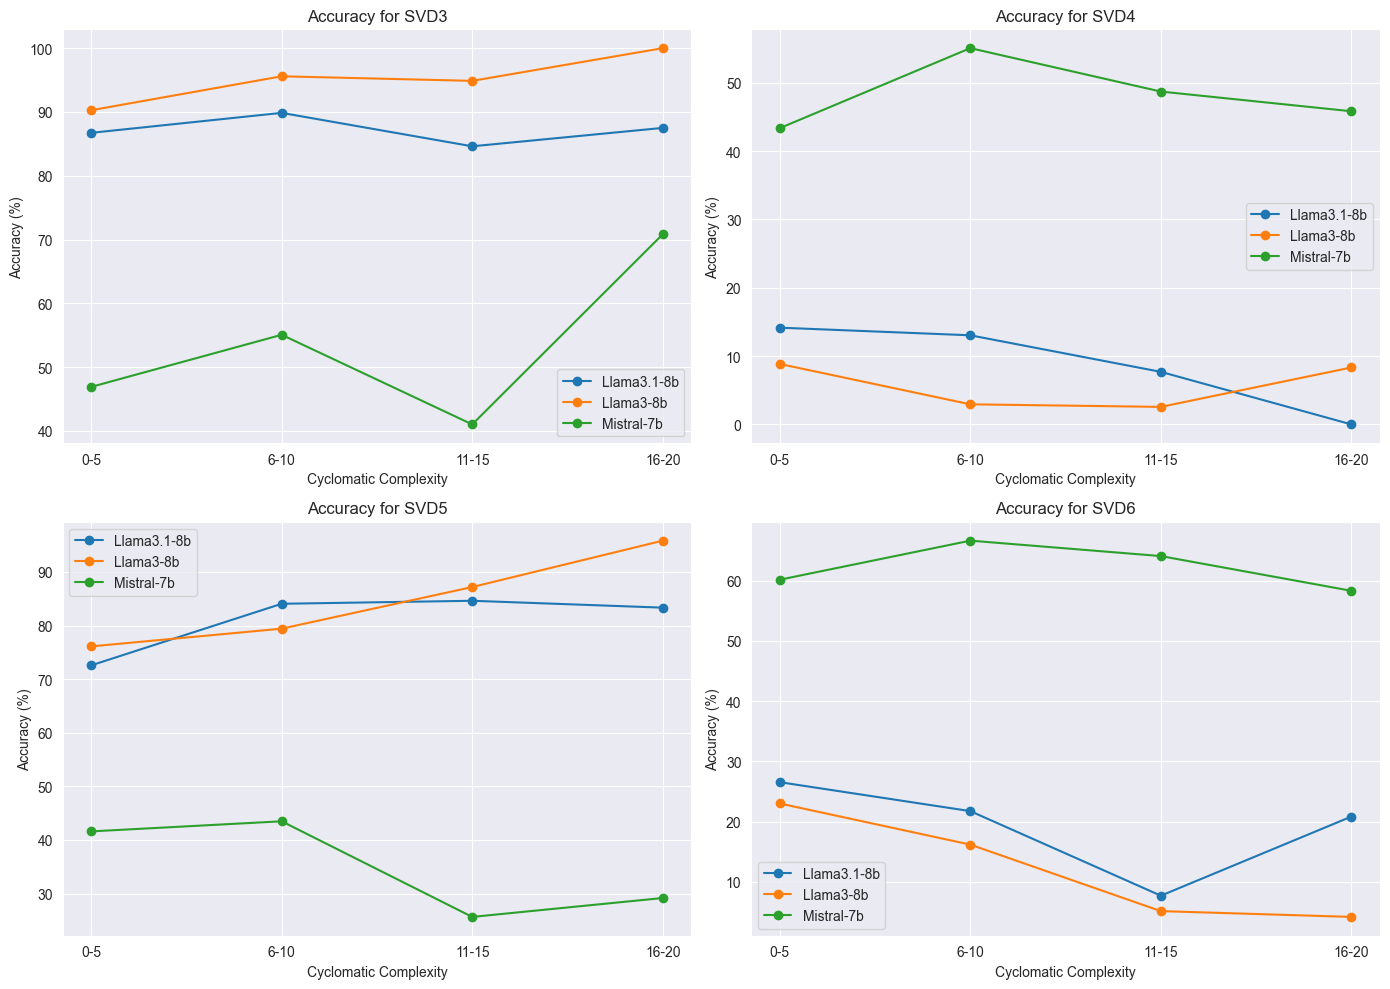

In [25]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import lizard

# Define model files
model_files = {
    'Llama3.1-8b': 'output/database_llama3.1-8b.sqlite',
    'Llama3-8b': 'output/database_llama3-8b-instruct.sqlite',
    'Mistral-7b': 'output/database_mistral-7b-instruct.sqlite'
}

# Define SVD tasks
svd_tasks = {
    'IS_VULNERABLE_Vuln': 'SVD3',
    'IS_VULNERABLE_Patch': 'SVD4',
    'IS_VULNERABLE_Vuln_CVE_CWE': 'SVD5',
    'IS_VULNERABLE_Patch_CVE_CWE': 'SVD6'
}

# Cyclomatic complexity bins
bins = [0, 5, 10, 15, 20]
labels = ['0-5', '6-10', '11-15', '16-20']

def calculate_cyclomatic_complexity(code):
    analysis = lizard.analyze_file.analyze_source_code('code.c', code)
    return analysis.function_list[0].cyclomatic_complexity if analysis.function_list else 0

def process_database(db_file):
    # Connect to the SQLite database
    conn = sqlite3.connect(db_file)
    query = """
    SELECT 
        IS_VULNERABLE_Vuln, 
        IS_VULNERABLE_Patch, 
        IS_VULNERABLE_Vuln_CVE_CWE, 
        IS_VULNERABLE_Patch_CVE_CWE, 
        VULNERABLE_CODE_BLOCK
    FROM vulnerabilities
    WHERE IS_VULNERABLE_Vuln not null and IS_VULNERABLE_Patch not null and IS_VULNERABLE_Patch_CVE_CWE not null and IS_VULNERABLE_Vuln_CVE_CWE not null
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    
    # Calculate cyclomatic complexity for each vulnerable code block
    df['Cyclomatic_Complexity'] = df['VULNERABLE_CODE_BLOCK'].apply(calculate_cyclomatic_complexity)
    
    # Bin the complexity
    df['Complexity'] = pd.cut(df['Cyclomatic_Complexity'], bins=bins, labels=labels)
    return df

# Process all databases and aggregate results
all_results = []

for model_name, db_file in model_files.items():
    df = process_database(db_file)
    
    for complexity in labels:
        for task, task_name in svd_tasks.items():
            task_df = df[df['Complexity'] == complexity]
            
            if not task_df.empty:
                y_true = [1 if 'Vuln' in task else 0] * len(task_df)
                y_pred = task_df[task].tolist()
                
                accuracy = accuracy_score(y_true, y_pred) * 100
                all_results.append({
                    'Model': model_name,
                    'Complexity': complexity,
                    'Task': task_name,
                    'Accuracy': accuracy
                })

results_df = pd.DataFrame(all_results)

# Create subplots for each SVD task
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for idx, task in enumerate(svd_tasks.values()):
    subset = results_df[results_df['Task'] == task]
    for model in model_files.keys():
        model_subset = subset[subset['Model'] == model]
        axs[idx].plot(model_subset['Complexity'], model_subset['Accuracy'], marker='o', label=model)
    
    axs[idx].set_xlabel('Cyclomatic Complexity')
    axs[idx].set_ylabel('Accuracy (%)')
    axs[idx].set_title(f'Accuracy for {task}')
    axs[idx].legend()
    axs[idx].grid(True)

plt.tight_layout()
plt.show()
